In [1]:
import numpy as np
import math
from scipy.integrate import quad
from scipy.linalg import eigvalsh
from scipy.optimize import minimize_scalar
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Basic Functions

In [2]:
#kronecker product code for more than 2 inputs
def kron(*matrices):
    result = np.array([[1]])
    for matrix in matrices:
        result = np.kron(result, matrix)
    return result

#Partial Trace Code
def IntegerDigits(n, b, l):
    digits = [0] * l
    pos = l - 1
    while pos != -1:
        digits[pos] = int(n % b)
        n //= b
        pos -= 1
    return digits

def FromDigits(digits, base):
    digits = digits[::-1]
    n = 0
    for i, d in enumerate(digits):
        n += d * base**i
        
    return n

def SwapParts(digits, p1, p2):
    new = np.copy(digits)
    new[p1] = digits[p2]
    new[p2] = digits[p1]
    return new

def dTraceSystem(D,s,dimen):
    Qudits=sorted(s)
    Qudits.reverse()
    TrkM = D
    z=len(Qudits)
    
    for q in range(z):
        n=math.log(TrkM.shape[0],dimen)
        assert n % 1 == 0
        n = int(n)
        
        M=TrkM
        M = np.array(M , dtype = complex)
        k=Qudits[q]
        temp = np.zeros(M.shape[0], dtype=complex)
        if k!=n:
            for j in range(n-k):
                b={0}
                for i in range(dimen**n):
                    digits=IntegerDigits(i,dimen,n)
                    if digits[n-1] != digits[n-j-2] and i not in  b:
                        number=FromDigits(
                            SwapParts(digits, n-1, n-j-2),
                            dimen
                        )
                        b.add(number)

                        temp[:] = M[i, :]
                        M[i, :] = M[number, :]
                        M[number, :] = temp

                        temp[:] = M[:, i]
                        M[:, i] = M[:, number]
                        M[:, number] = temp
        
        TrkM=[]
        for p in range(0,dimen**n,dimen):
            TrkM.append(
                sum(
                    M[p+h, h:dimen**n:dimen]
                    for h in range(dimen)
                )
            )
        TrkM = np.array(TrkM)
    
    return TrkM
#Recall matrix as dTraceSystem(matrix,[systems I want to trace out],dimension of system)

#defining basis vectors

#zero vector and its conjugate transpose                                         
zero= np.array([[1],[0]])
zeroCT=np.conjugate(zero.T)
#one vector and its conjugate transpose
one=np.array([[0],[1]])
oneCT=np.conjugate(one.T)
#plus vector and its conjugate transpose
plus=np.array([[1],[1]])*1/math.sqrt(2)
plusCT=np.conjugate(plus.T)
#minus vector and its conjugate transpose
minus=np.array([[1],[-1]])*1/math.sqrt(2)
minusCT=np.conjugate(minus.T)
#plusy and its conjugate transpose
plusy=np.array([[1],[complex(0.0, 1)]])*1/math.sqrt(2)
plusyCT=np.conjugate(plusy.T)
#minusy and its conjugate transpose
minusy=np.array([[1],[complex(0.0, -1)]])*1/math.sqrt(2)
minusyCT=np.conjugate(minusy.T)
#defining the Bell states
phiplus=(np.kron(zero, zero)+np.kron(one, one))*1/math.sqrt(2)
phiminus=(np.kron(zero, zero)-np.kron(one, one))*1/math.sqrt(2)
psiplus=(np.kron(zero, one)+np.kron(one, zero))*1/math.sqrt(2)
psiminus=(np.kron(zero, one)-np.kron(one, zero))*1/math.sqrt(2)
#defining the outer product of the Bell states
Phiplus=phiplus@np.conjugate(phiplus.T)
Phiminus=phiminus@np.conjugate(phiminus.T)
Psiplus=psiplus@np.conjugate(psiplus.T)
Psiminus=psiminus@np.conjugate(psiminus.T)
#defining Pauli matrices
pauliX=np.array([[0,1],[1,0]])
pauliY=np.array([[0,complex(0,-1)],[complex(0,1),0]])
pauliZ=np.array([[1,0],[0,-1]])

# Bell-Diagonal Map

In [3]:
def r(p, q):
    return np.array([
        p[3]*q[0] + p[2]*q[1] + p[1]*q[2] + p[0]*q[3],
        p[2]*q[0] + p[3]*q[1] + p[0]*q[2] + p[1]*q[3],
        p[1]*q[0] + p[0]*q[1] + p[3]*q[2] + p[2]*q[3],
        p[0]*q[0] + p[1]*q[1] + p[2]*q[2] + p[3]*q[3]
    ])

def rNtimes(p, n):
    if n == 1:
        return r(p, p)
    else:
        return r(rNtimes(p, n-1), p)

# GKP

In [4]:
#Defining parameters for GKP states


# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    alpha = (alpha_dB_per_km / 10) * np.log(10)  # convert dB/km to 1/km
    return np.exp(-alpha * L / (n + 1))  # eta ∈ [0, 1]

#Quality of GKP state
def sigmaloss(sigma , L , n):
    eta = new_eta(L , n)
    return np.sqrt(eta * sigma**2 + (1 - eta))


#Error functions
def f(x , mu , sigma , L , n):
    s = sigmaloss(sigma , L , n)
    return np.exp(-(x - mu)**2 / (2 * s**2))/(s * np.sqrt(2*np.pi))

def Pc(sigma , nu , L , n):
    integrand = lambda x: f(x , 0 , sigma , L , n)
    lower = -0.5 * np.sqrt(np.pi) + nu
    upper =  0.5 * np.sqrt(np.pi) - nu
    return quad(integrand, lower, upper)[0] 
    
def Pf(sigma , nu , L , n):
    integrand = lambda x: f(x, 0, sigma, L , n)
    lower = 0.5 * np.sqrt(np.pi) + nu
    upper = 1.5 * np.sqrt(np.pi) - nu
    return 2 * quad(integrand, lower, upper)[0]



#Bell state mixture probabilities


def p1(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pc**2) / (pc + pf)**2

def p2(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pc * pf) / (pc + pf)**2

def p3(sigma , nu , L , n):
    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)
    return (pf**2) / (pc + pf)**2



#Mixture of Bell states

def new_vector(sigma , nu , L , n):
    return np.array([
        p1(sigma , nu , L , n) , 
        p2(sigma , nu , L , n) , 
        p2(sigma , nu , L , n) , 
        p3(sigma , nu , L , n)
        ])


#von Neumann entropy

def vonneumann(mat):
    evals = eigvalsh(mat)
    evals = np.clip(evals, 1e-16 , 1)
    return -np.sum(evals * np.log2(evals))



# hashing bound

def hashing_bound(mat):
    sAB = vonneumann(mat)
    sA = vonneumann(dTraceSystem(mat , [2] , 2))
    sB = vonneumann(dTraceSystem(mat , [1] , 2))
    return max(sA - sAB , sB - sAB)



# chain function

def chain_function(vec , n):
    return rNtimes(vec , n)



# building the chain states

def BSM_mixture_chain(vec):
    return vec[0] * Phiplus + vec[1] * Phiminus + vec[2] * Psiplus + vec[3] * Psiminus
 

# defining the probability of success for repeaters

# BSM swaps are no longer deterministic
# we model realistic repeater architectures
# these architectures perform probabilistic entanglement generation
# we only succeed when ALL elementary links generate entangled pairs
# AND all BSM swaps succeed

# these probability of successes have been adjusted in each respectiv hashing rate definition

#GKP chains

# hashing rate
def hashing_rate(sigma , nu , L , n , M , q , tau , m):

    pc = Pc(sigma , nu , L , n)
    pf = Pf(sigma , nu , L , n)

    # probability of BSM swap
    pSWAP = (pc + pf)**2
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    vec = chain_function(new_vector(sigma , nu , L , n) , n)
    
    return rate * hashing_bound(BSM_mixture_chain(vec))


# optimal hashing rate
def optimal_hashing_rate(sigma , L , n , M , q , tau , m , return_nu = False):
    def neg_rate(nu):
        try:
            value = hashing_rate(sigma , nu , L , n , M , q , tau , m)
            return -value if value > 0 else np.inf
        except Exception:
            return np.inf

    result = minimize_scalar(neg_rate, bounds=(0, 0.5 * np.sqrt(np.pi)), method='bounded')
    rate = -result.fun

    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate , result.x  # return rate, ν
    return rate

# Single-Rail

In [5]:
# Single Rail

def SingleRailState(eta , gamma , Pd , Vis):
    return 2 * np.array(
        [
            [(1 - Pd)*Pd*gamma**2, 0 , 0 , 0], 
            [0 , (1 - Pd) * Pd * (1 - gamma) * gamma * (1 - np.sqrt(eta)) + 1/2 * ((1 - Pd)**2) * (1 - gamma) * gamma * np.sqrt(eta) , 1/2 * ((1 - Pd)**2) * (1 - gamma) * gamma * np.sqrt(eta)* Vis , 0] ,
            [0 , 1/2 * ((1 - Pd)**2) * (1 - gamma) * gamma * np.sqrt(eta) * Vis , (1 - Pd)* Pd * (1 - gamma) * gamma * (1 - np.sqrt(eta)) + 1/2 * ((1 - Pd)**2) * (1 - gamma) * gamma * np.sqrt(eta), 0] ,
            [0 , 0 , 0, (1 - Pd) * Pd * ((1 - gamma)**2) * ((1 - np.sqrt(eta))**2) + ((1 - Pd)**2) * ((1 - gamma)**2) * (1 - np.sqrt(eta)) * np.sqrt(eta)]
        ]
    )
# normalised quantum state for single-rail entangled memory pair
def QStateSingle(eta , gamma , Pd , Vis):
    state = SingleRailState(eta , gamma , Pd , Vis)
    tr = np.trace(state)
    # avoiding division by 0
    if tr == 0 or not np.isfinite(tr):
        return np.zeros_like(state)
    return state / tr

# Building chains of SR encoded states

def SRinitialState(eta , gamma):
    BSM = kron(np.identity(2) , Phiplus , np.identity(2))
    rho = kron(QStateSingle(eta , gamma , 0 , 1) , QStateSingle(eta , gamma , 0 , 1))
    rho = BSM @ rho @ np.conjugate(BSM.T)
    rho = rho / np.trace(rho)
    return dTraceSystem(rho , [2 , 3] , 2)

def SRextendState(rho , eta , gamma):
    BSM = kron(np.identity(2) , Phiplus , np.identity(2))
    rho_ext = kron(rho , QStateSingle(eta , gamma , 0 , 1))
    rho_ext = BSM @ rho_ext @ np.conjugate(BSM.T)
    rho_ext = rho_ext / np.trace(rho_ext)
    return dTraceSystem(rho_ext , [2 , 3] , 2)

def SRchainState(L , gamma , n):
    eta = new_eta(L , n)
    if n == 1:
        return QStateSingle(eta , gamma , 0 , 1)
    rho = SRinitialState(eta , gamma)
    for _ in range(n - 2):
        rho = SRextendState(rho , eta , gamma)
    return rho

# Single-Rail Hashing Rate
def SRhashingrate(L , gamma , n , M , q , tau , m):

    eta = new_eta(L , n)
    PsuccSR = np.trace(SingleRailState(eta , gamma , 0 , 1))

    # probability of BSM swap
    pSWAP = PsuccSR
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    rho = SRchainState(L , gamma , n)
    return rate * hashing_bound(rho)

# optimising over gamma
def optimal_SRhashingrate(L , n , M , q , tau , m):
    gammas = np.linspace(0, 1, 100)
    best_rate = 0.0
    best_gamma = None
    for gamma in gammas:
        try:
            rate = SRhashingrate(L , gamma, n , M , q , tau , m)
            # ensuring that the hashing rate is a valid number
            if not np.isnan(rate) and not np.isinf(rate):
                if rate > best_rate:
                    best_rate = rate
                    best_gamma = gamma
        except Exception as e:
            # print(f"Skipping gamma = {gamma}: {e}")
            continue
    return best_rate , best_gamma if best_gamma is not None else 0


# Dual-Rail

In [6]:
# Dual Rail
def DualRailState(eta , Pd , Vis):
    return 4 * np.array(
        [
            [1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta), 0 , 0 , 0] ,
            [0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 1/16 * ((1 - Pd)**4) * eta * Vis**2 , 0] ,
            [0 , 1/16 * ((1 - Pd)**4) *eta * Vis**2 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta) + 1/16 * ((1 - Pd)**4) * eta , 0] ,
            [0 , 0 , 0 , 1/4 * ((1 - Pd)**2) * (Pd**2) * (1 - np.sqrt(eta))**2 + 1/4 * ((1 - Pd)**3) * Pd * (1 - np.sqrt(eta)) * np.sqrt(eta)]
        ]
    )
# normalised quantum state for dual-rail entangled memory pair
def QStateDual(eta , Pd , Vis):
    state = DualRailState(eta , Pd , Vis)
    tr = np.trace(DualRailState(eta , Pd , Vis))
    # avoiding division by 0
    if tr == 0 or not np.isfinite(tr):
        return np.zeros_like(state)
    return state / tr

# hashing rate
def DRhashingrate(L , n , M , q , tau , m):
    eta = new_eta(L , n)
    PsuccDR = np.trace(DualRailState(eta , 0 , 1))

    # probability of BSM swap
    pSWAP = PsuccDR
    # probability single element success
    pELEM = 1 - (1 - pSWAP)**(M * m)
    # probability successful connection between end users
    pNETWORK = pELEM**(n + 1) * q**n
    # achievable rate of entanglement generation for the network
    rate = pNETWORK / (tau * m)

    if n == 1:
        return rate * hashing_bound(QStateDual(eta , 0 , 1))
    else:
        vec = rNtimes(np.linalg.eigvalsh(QStateDual(eta , 0 , 1)) , n - 1)
        rho = BSM_mixture_chain(vec)
        return rate * hashing_bound(rho)

# QR with NO distillation

# Defining $R^{UB}$ and $R^{LB}$ by maximisation over (m,n)

# Dual-Rail encoding

Dual Rail probability of success can be written as $P_{succ}^{DR} = \mu e^{-\alpha L/(n+1)}$, whihc allows us to write the family of points A(m,n) and B(m,n) as

$A(m,n) = [(Mm\mu)^{-(n+1)} , \frac{q^{n}}{m\tau}]$

$B(m,n) = [(Mm\mu)^{-(n+1)} , \frac{q^{n} [1-(1-\frac{1}{Mm})^{Mm}]^{(n+1)}}{m\tau}]$

Analytically, the point of intersection of $R_{max}$ and $R_{exp}$ is A(m,n), and vertically dropping this point down to the hashing rate curve gives B(m,n). This point of intersection A(m,n) is found when thse following two lines meet

$y = R_{max} = \frac{q^{n}}{m\tau}$

$y = R_{exp} = \frac{(MmP_{succ})^{(n+1)}q^{n}}{m\tau}$

However, for the GKP photonic encoding we cannot write its probability of success in such a form. However, we can numerically demonstrate for the DR encoding that these analytic points are exactly equivalent to the numerical points as follows:

$A(m,n) = [POI of R_{max} = R_{exp} , R_{max}]$

$B(m,n) = [POI of R_{max} = R_{exp} , HR\text{ of curve}]$

where the family of points A(m,n) are the upper bound, where the exponential upper bound and the horizontal upper bound lines $R_{max}$ meet, and the family of points B(m,n) is the same x-axis coordinate but the point is vertically dropped from the upper bound envelope to the HR curve, thus the family B(m,n) serve as a lower bound.

The following code demonstrates for DR encoding that the numerical family A(m,n) match the analytic form derived in Eq. (A3)

# Locus of points A(m,n) and B(m,n) defining the upper and lower subexponential scaling bounds, respectively

## Analytic form of families A(m,n) and B(m,n)

In [7]:
def mu_DR():
    # For Pd = 0, Vis = 1:
    # PsuccDR = eta / 2, so mu_DR = 1/2
    return np.real(np.trace(DualRailState(1.0, 0, 1)))


def A_point_DR_fixed_m(n, M, m, q, tau, alpha):
    mu = mu_DR()

    if M * m * mu <= 1:
        return np.nan, np.nan

    L_A = ((n + 1) / alpha) * np.log(M * m * mu)
    R_A = q**n / (m * tau)

    return L_A, R_A


def B_point_DR_fixed_m(n, M, m, q, tau, alpha):
    mu = mu_DR()

    if M * m * mu <= 1:
        return np.nan, np.nan

    L_B = ((n + 1) / alpha) * np.log(M * m * mu)

    success_factor = 1 - (1 - 1 / (M * m))**(M * m)

    R_B = (q**n / (m * tau)) * success_factor**(n + 1)

    return L_B, R_B

For m=10 , n=4 we append the analytic form of A(10,16) and B(10,16)

In [20]:
Ls = np.arange(0 , 1600 , 16)
n=4
q = 0.7
tau = 1e-8
M = 10
alpha = (np.log(10) / 10) * 0.2
m = 10

A_Ls, A_Rs = [], []
B_Ls, B_Rs = [], []


L_A, R_A = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
L_B, R_B = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

A_Ls.append(L_A)
A_Rs.append(R_A)

B_Ls.append(L_B)
B_Rs.append(R_B)

A_Ls = np.array(A_Ls)
A_Rs = np.array(A_Rs)
B_Ls = np.array(B_Ls)
B_Rs = np.array(B_Rs)

Now we numerically solve for the point of intersection of the two upper bounding lines $R_{max}$ and $R_{exp}$

In [21]:
def p_succ_DR(L, n, alpha):
    mu = mu_DR()
    eta_link = np.exp(-alpha * L / (n + 1))
    return mu * eta_link


def A_point_DR_fixed_m_numerical(n, M, m, q, tau, alpha,L_max_search=3000, num_scan=2000):

    def intersection_eq(L):
        p = p_succ_DR(L, n, alpha)
        return M * m * p - 1

    L_grid = np.linspace(0, L_max_search, num_scan)
    vals = np.array([intersection_eq(L) for L in L_grid])

    for j in range(len(L_grid) - 1):
        if not np.isfinite(vals[j]) or not np.isfinite(vals[j + 1]):
            continue

        if vals[j] == 0:
            L_A = L_grid[j]
            R_A = q**n / (m * tau)
            return L_A, R_A

        if vals[j] * vals[j + 1] < 0:
            L_A = brentq(intersection_eq, L_grid[j], L_grid[j + 1])
            R_A = q**n / (m * tau)
            return L_A, R_A

    return np.nan, np.nan


def B_point_DR_fixed_m_numerical(n, M, m, q, tau, alpha,L_max_search=3000, num_scan=2000):

    L_A, _ = A_point_DR_fixed_m_numerical(
        n, M, m, q, tau, alpha,
        L_max_search=L_max_search,
        num_scan=num_scan
    )

    if not np.isfinite(L_A):
        return np.nan, np.nan

    R_B = DRhashingrate(L_A, n, M, q, tau, m)

    return L_A, R_B

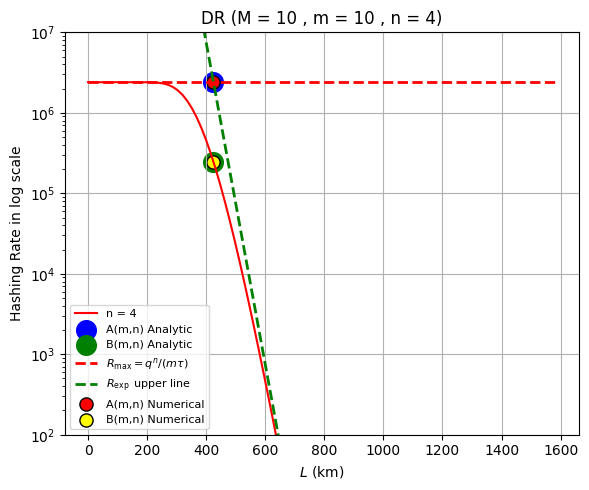

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 10 , m = 10 , n = 4)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e2, top=1e7)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

n = 4

DRrates4 = [DRhashingrate(L,n,M,q,tau,m) for L in Ls]

ax.plot(Ls, DRrates4, label=f"n = {n}", color="red")

# Analytic form of families A(m,n) and B(m,n)
ax.scatter(A_Ls,A_Rs,s=200,color="blue",marker="o",label="A(m,n) Analytic")
ax.scatter(B_Ls,B_Rs,s=200,color="green",marker="o",label="B(m,n) Analytic")

# Upper bounds
R_max = np.full_like(Ls,q**n / (m * tau),dtype=float)
R_exp = (q**n / (m * tau)) * (M * m * 0.5 * np.exp(-alpha * Ls / (n + 1)))**(n + 1)
ax.plot(Ls,R_max,color="red",linestyle="--",linewidth=2,label=r"$R_{\max}=q^n/(m\tau)$")
ax.plot(Ls,R_exp,color="green",linestyle="--",linewidth=2,label=r"$R_{\exp}$ upper line")

# Numerical form of families A(m,n) and B(m,n)
L_A_num, R_A_num = A_point_DR_fixed_m_numerical(n, M, m, q, tau, alpha)
L_B_num, R_B_num = B_point_DR_fixed_m_numerical(n, M, m, q, tau, alpha)
ax.scatter([L_A_num],[R_A_num],s=90,color="red",edgecolor="black",marker="o",label="A(m,n) Numerical")
ax.scatter([L_B_num],[R_B_num],s=90,color="yellow",edgecolor="black",marker="o",label="B(m,n) Numerical")


ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
n = 4

# Analytic points
L_A_an, R_A_an = A_point_DR_fixed_m(
    n, M, m, q, tau, alpha
)

L_B_an, R_B_an = B_point_DR_fixed_m(
    n, M, m, q, tau, alpha
)

# Numerical points
L_A_num, R_A_num = A_point_DR_fixed_m_numerical(
    n, M, m, q, tau, alpha
)

L_B_num, R_B_num = B_point_DR_fixed_m_numerical(
    n, M, m, q, tau, alpha
)

print("=" * 60)
print("A(m,n) comparison for n = 4")
print("=" * 60)

print(f"L_A analytic   = {L_A_an:.15e}")
print(f"L_A numerical  = {L_A_num:.15e}")
print(f"Difference     = {L_A_an - L_A_num:.15e}")

print()

print(f"R_A analytic   = {R_A_an:.15e}")
print(f"R_A numerical  = {R_A_num:.15e}")
print(f"Difference     = {R_A_an - R_A_num:.15e}")

print("\n")

print("=" * 60)
print("B(m,n) comparison for n = 4")
print("=" * 60)

print(f"L_B analytic   = {L_B_an:.15e}")
print(f"L_B numerical  = {L_B_num:.15e}")
print(f"Difference     = {L_B_an - L_B_num:.15e}")

print()

print(f"R_B analytic   = {R_B_an:.15e}")
print(f"R_B numerical  = {R_B_num:.15e}")
print(f"Difference     = {R_B_an - R_B_num:.15e}")

A(m,n) comparison for n = 4
L_A analytic   = 4.247425010840046e+02
L_A numerical  = 4.247425010840046e+02
Difference     = 0.000000000000000e+00

R_A analytic   = 2.401000000000000e+06
R_A numerical  = 2.401000000000000e+06
Difference     = 0.000000000000000e+00


B(m,n) comparison for n = 4
L_B analytic   = 4.247425010840046e+02
L_B numerical  = 4.247425010840046e+02
Difference     = 0.000000000000000e+00

R_B analytic   = 2.458825319850536e+05
R_B numerical  = 2.458825319850496e+05
Difference     = 3.987224772572517e-09


This above plot and print statement demonstrates that the analytic form of the POI exactly matches the numerically derived value. Therefore, since we cannot analytically derive the form of the families A(m,n) or B(m,n), we thus can use the numerical simulation to find its families A(m,n) and B(m,n) as the above prove they are thus equivalent.

# Full DR Analysis

In [35]:
plt.figure(dpi  = 1000)

Ls = np.arange(0 , 700 , 7)

q = 0.7
tau = 1e-8
M = 1
alpha = (np.log(10) / 10) * 0.2
m = 20

DRrates1 = [DRhashingrate(L , 1 , M , q , tau , m) for L in Ls]
DRrates2 = [DRhashingrate(L , 2 , M , q , tau , m) for L in Ls]
DRrates4 = [DRhashingrate(L , 4 , M , q , tau , m) for L in Ls]
DRrates8 = [DRhashingrate(L , 8 , M , q , tau , m) for L in Ls]
DRrates16 = [DRhashingrate(L , 16 , M , q , tau , m) for L in Ls]

<Figure size 6400x4800 with 0 Axes>

In [36]:
n_vals = [1, 2, 4, 8, 16]

A_Ls, A_Rs = [], []
B_Ls, B_Rs = [], []

for n in n_vals:
    L_A, R_A = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
    L_B, R_B = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

    A_Ls.append(L_A)
    A_Rs.append(R_A)

    B_Ls.append(L_B)
    B_Rs.append(R_B)

A_Ls = np.array(A_Ls)
A_Rs = np.array(A_Rs)
B_Ls = np.array(B_Ls)
B_Rs = np.array(B_Rs)

# Considering $n=[1,2,4,8,16]$ for $M=m=10$ and maximising over the rate curves

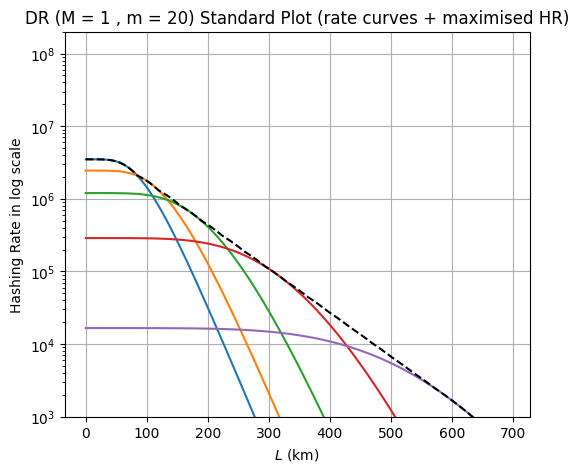

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 1 , m = 20) Standard Plot (rate curves + maximised HR)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

Ls = np.array(Ls)  # ensure it's an array
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 17)

dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)

        if np.isfinite(rate):
            best_rate = max(best_rate, rate)

    dr_rate_envelope.append(best_rate)

dr_rate_envelope = np.array(dr_rate_envelope)

ax.plot(Ls, dr_rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")


plt.show()

# Performing a linear regression over the maximisation envelope

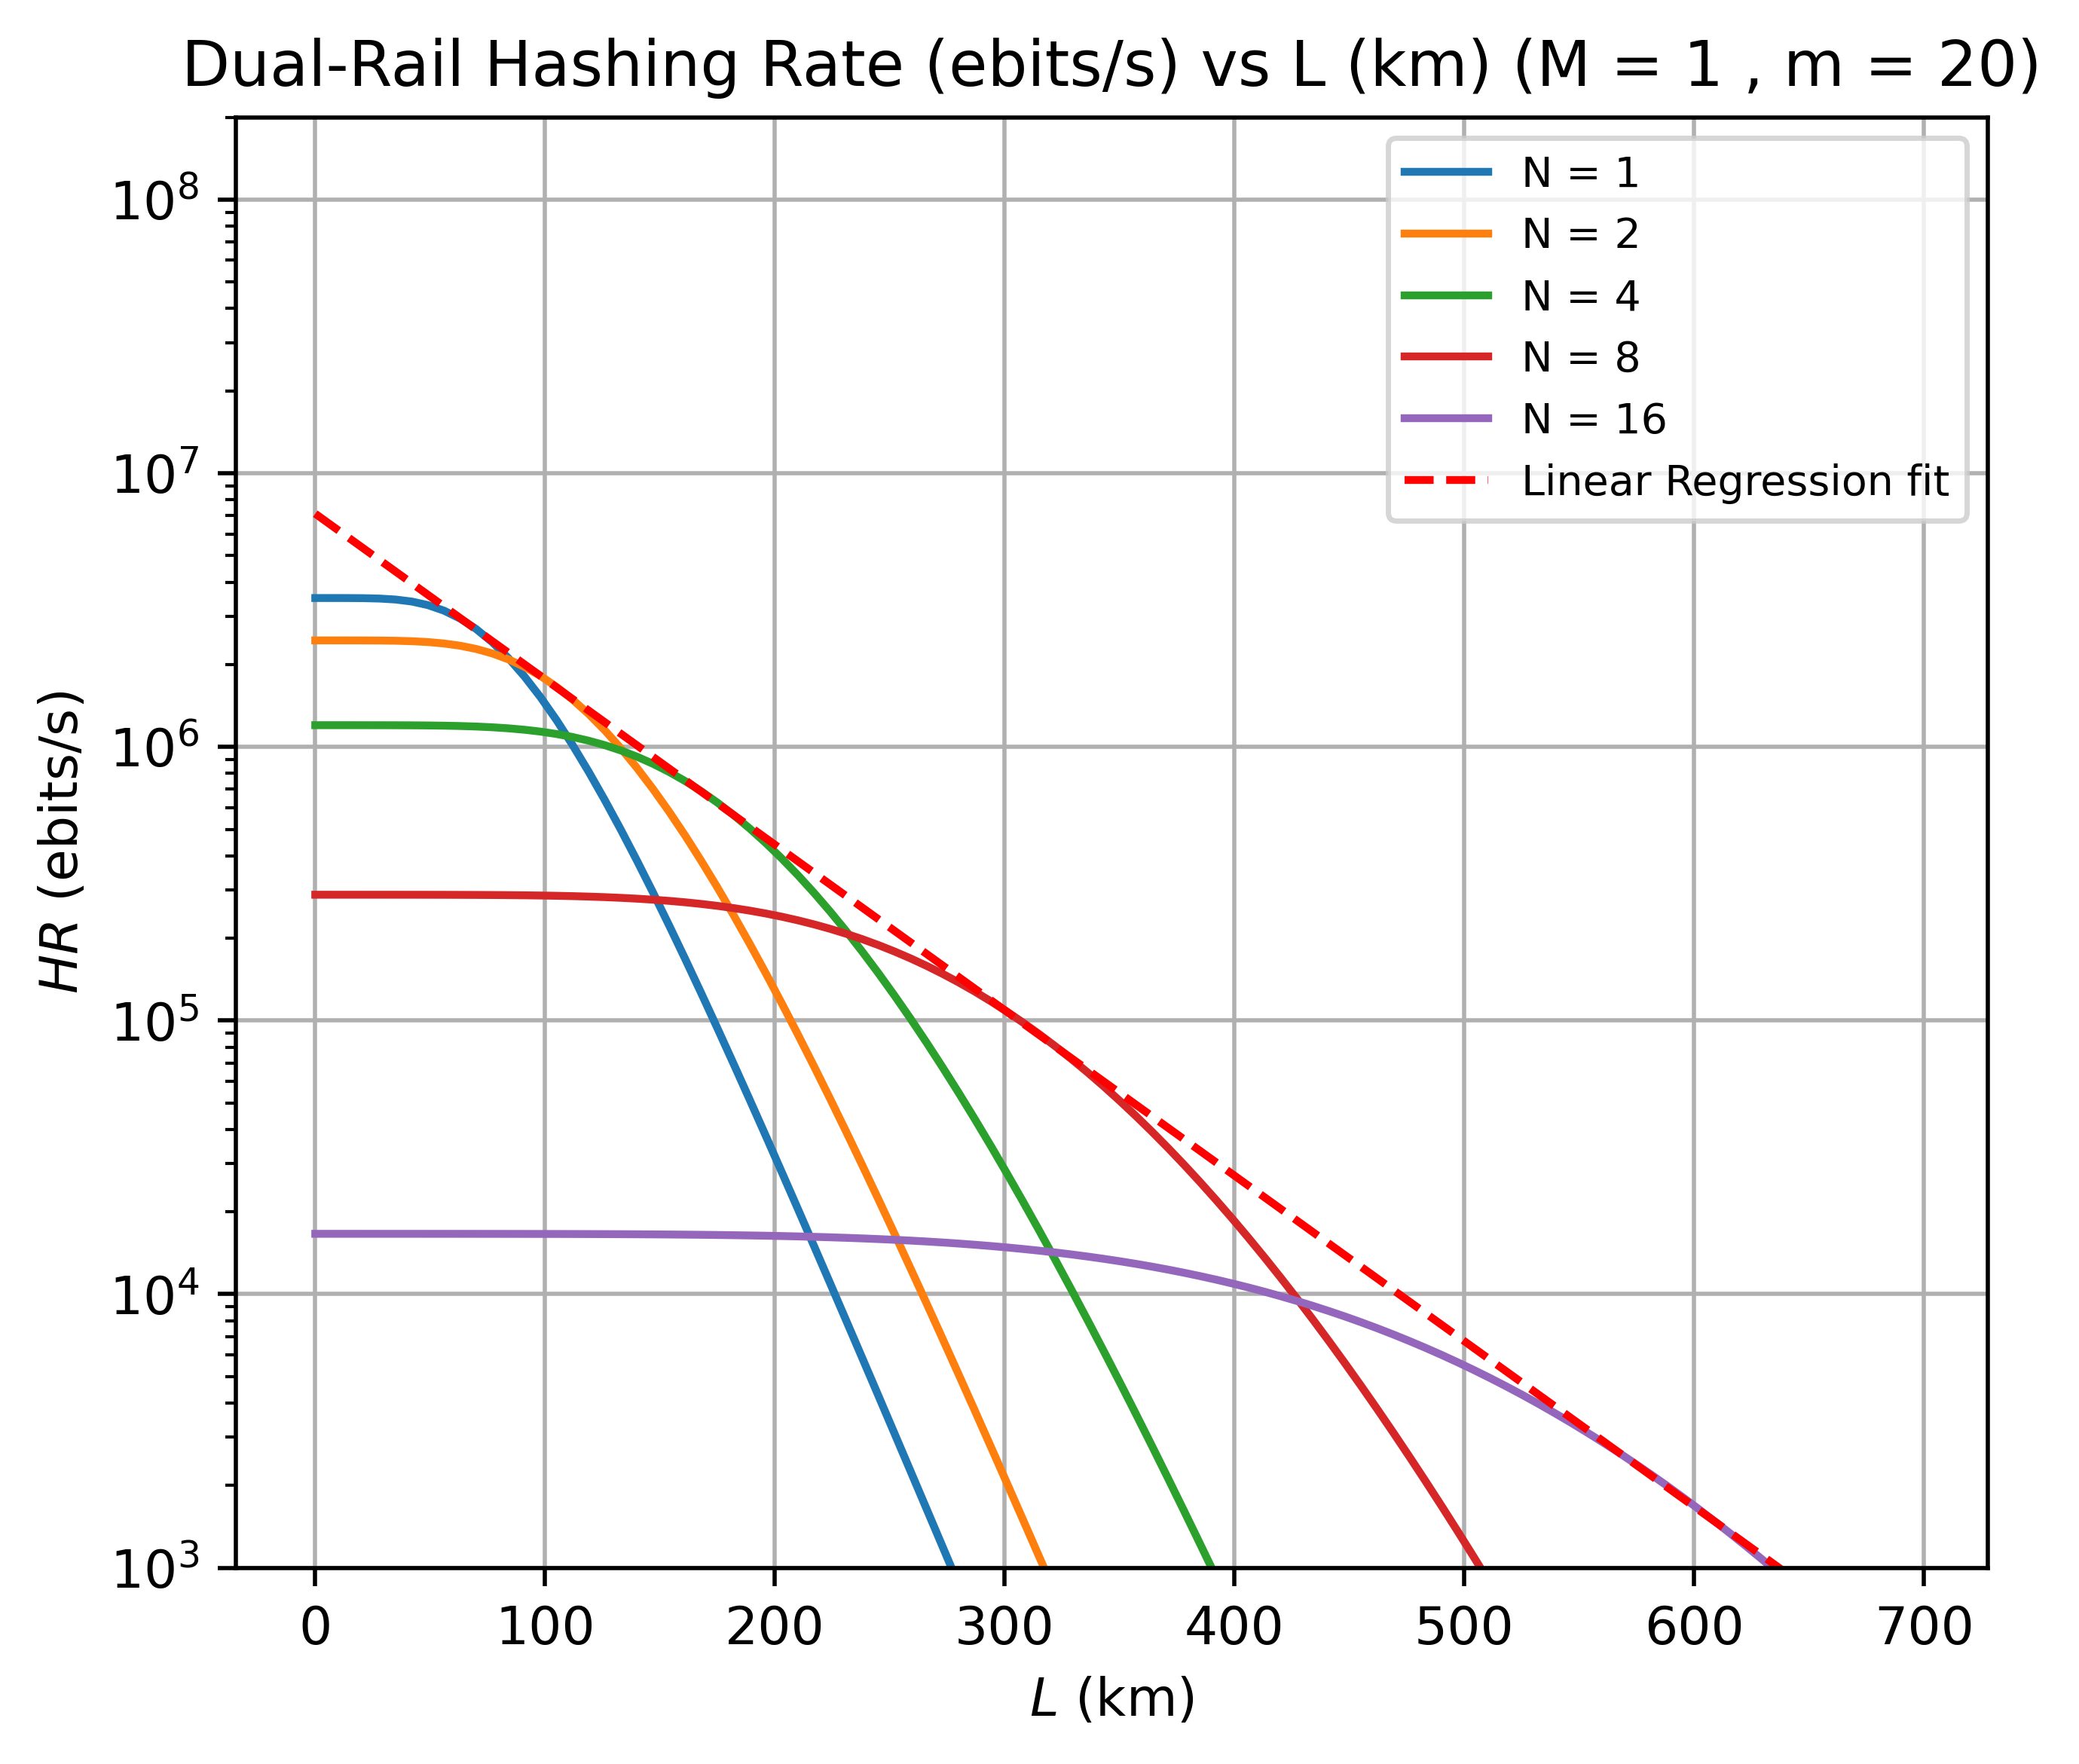

In [44]:
fig, ax = plt.subplots(figsize=(6, 5), dpi = 500)
ax.set_yscale("log")
ax.set_title("Dual-Rail Hashing Rate (ebits/s) vs L (km) (M = 1 , m = 20)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("$HR$ (ebits/s)")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

Ls = np.array(Ls)  # ensure it's an array
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"N = {n}", color=color)

n_scan_vals = np.arange(1 , 17)

dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)

        if np.isfinite(rate):
            best_rate = max(best_rate, rate)

    dr_rate_envelope.append(best_rate)

dr_rate_envelope = np.array(dr_rate_envelope)

log_env = np.log(dr_rate_envelope)

fit_mask = (Ls > 110) & (Ls < 650)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env1, color="red", linestyle="--", label="Linear Regression fit")

ax.legend(fontsize=8 , loc="upper right")

plt.show()

# Plotting the two-part upper bound envelopes $R_{max}$ and $R_{env}$

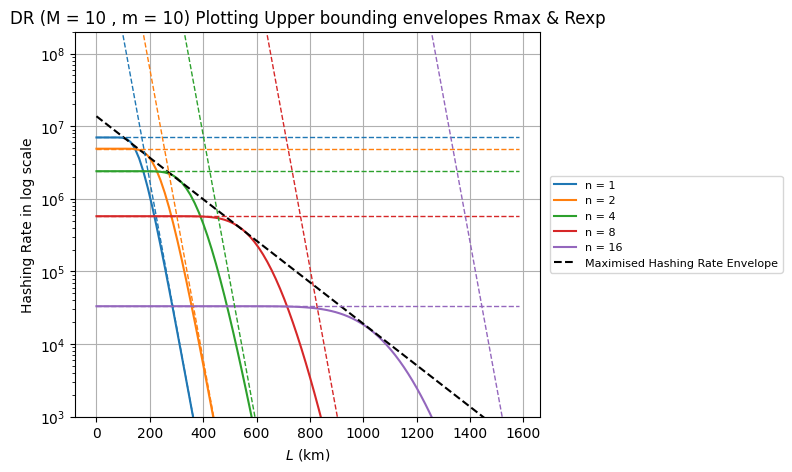

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 10 , m = 10) Plotting Upper bounding envelopes Rmax & Rexp")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

# Plotting the rate curves
Ls = np.array(Ls)
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]
color_cycle = plt.get_cmap("tab10")
for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)
    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)
n_scan_vals = np.arange(1 , 17)
dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)
        if np.isfinite(rate):
            best_rate = max(best_rate, rate)
    dr_rate_envelope.append(best_rate)
dr_rate_envelope = np.array(dr_rate_envelope)

# Plotting the maximised bound of the HR
log_env = np.log(dr_rate_envelope)
fit_mask = (Ls > 110) & (Ls < 650)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)
ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")

# Plotting the analytic forms of A(m,n) and B(m,n)
for i, n in enumerate(n_vals):
    color = color_cycle(i)
    R_max = np.full_like(Ls,q**n / (m * tau),dtype=float)
    R_exp = (q**n / (m * tau)) * (M * m * 0.5 * np.exp(-alpha * Ls / (n + 1)))**(n + 1)

    ax.plot(Ls,R_max,color=color,linestyle="--",linewidth=1)
    ax.plot(Ls,R_exp,color=color,linestyle="--",linewidth=1)

ax.legend(fontsize=8,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)


plt.show()

# Inclusion of POI

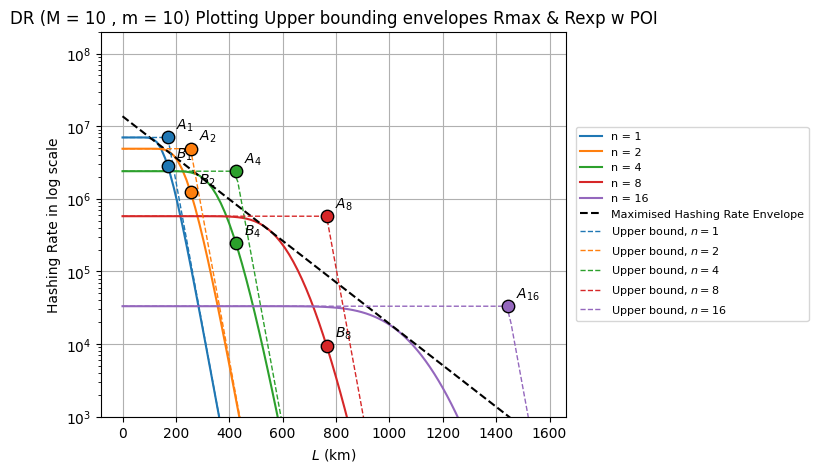

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 10 , m = 10) Plotting Upper bounding envelopes Rmax & Rexp w POI")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

# Plotting the rate curves
Ls = np.array(Ls)
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]
color_cycle = plt.get_cmap("tab10")
for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)
    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)
n_scan_vals = np.arange(1 , 17)
dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)
        if np.isfinite(rate):
            best_rate = max(best_rate, rate)
    dr_rate_envelope.append(best_rate)
dr_rate_envelope = np.array(dr_rate_envelope)

# Plotting the maximised bound of the HR
log_env = np.log(dr_rate_envelope)
fit_mask = (Ls > 110) & (Ls < 650)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)
ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")

# Plotting the analytic forms of A(m,n) and B(m,n)
for i, n in enumerate(n_vals):
    color = color_cycle(i)
    R_max = np.full_like(Ls,q**n / (m * tau),dtype=float)
    R_exp = (q**n / (m * tau)) * (M * m * 0.5 * np.exp(-alpha * Ls / (n + 1)))**(n + 1)
    R_upper_piecewise = np.minimum(R_max, R_exp)
    L_A , R_A = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
    L_B , R_B = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

    ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1,label=fr"Upper bound, $n={n}$")
    ax.scatter([L_A],[R_A],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.scatter([L_B],[R_B],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.annotate(rf"$A_{{{n}}}$",(L_A, R_A),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")
    ax.annotate(rf"$B_{{{n}}}$",(L_B, R_B),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")

ax.legend(fontsize=8,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)


plt.show()

# Linear Regression through families A(m,n) and B(m,n)

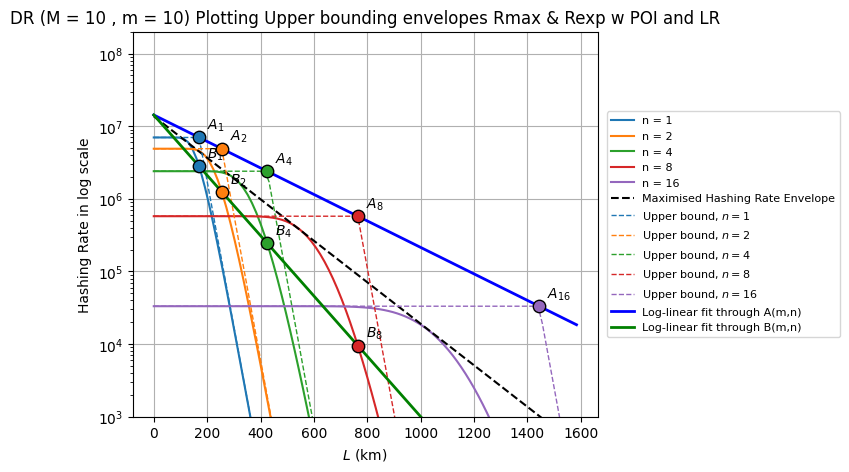

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 10 , m = 10) Plotting Upper bounding envelopes Rmax & Rexp w POI and LR")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

# Plotting the rate curves
Ls = np.array(Ls)
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]
color_cycle = plt.get_cmap("tab10")
for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)
    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)
n_scan_vals = np.arange(1 , 17)
dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)
        if np.isfinite(rate):
            best_rate = max(best_rate, rate)
    dr_rate_envelope.append(best_rate)
dr_rate_envelope = np.array(dr_rate_envelope)

# Plotting the maximised bound of the HR
log_env = np.log(dr_rate_envelope)
fit_mask = (Ls > 110) & (Ls < 650)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)
ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")

# Plotting the analytic forms of A(m,n) and B(m,n)
for i, n in enumerate(n_vals):
    color = color_cycle(i)
    R_max = np.full_like(Ls,q**n / (m * tau),dtype=float)
    R_exp = (q**n / (m * tau)) * (M * m * 0.5 * np.exp(-alpha * Ls / (n + 1)))**(n + 1)
    R_upper_piecewise = np.minimum(R_max, R_exp)
    L_A , R_A = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
    L_B , R_B = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

    ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1,label=fr"Upper bound, $n={n}$")
    ax.scatter([L_A],[R_A],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.scatter([L_B],[R_B],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.annotate(rf"$A_{{{n}}}$",(L_A, R_A),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")
    ax.annotate(rf"$B_{{{n}}}$",(L_B, R_B),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")

# --------------------------------------------------
# Log-linear regression through A(m,n) and B(m,n)
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="blue",linestyle="-",linewidth=2,label="Log-linear fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,label="Log-linear fit through B(m,n)")

ax.legend(fontsize=8,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)


plt.show()

# Tidying everything up

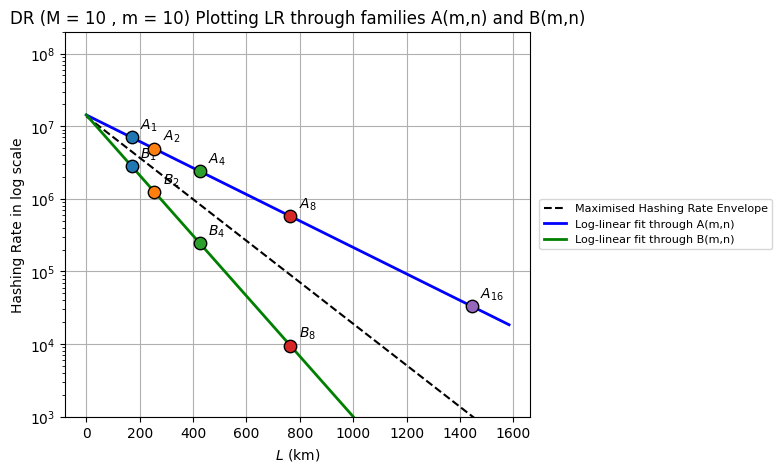

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("DR (M = 10 , m = 10) Plotting LR through families A(m,n) and B(m,n)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

# Plotting the rate curves
Ls = np.array(Ls)
dr_list = [DRrates1 , DRrates2 , DRrates4 , DRrates8 , DRrates16]
color_cycle = plt.get_cmap("tab10")
for i, rate_curve in enumerate(dr_list):
    n = n_vals[i]
    color = color_cycle(i)
    # ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)
n_scan_vals = np.arange(1 , 17)
dr_rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        rate = DRhashingrate(L, n, M, q, tau, m)
        if np.isfinite(rate):
            best_rate = max(best_rate, rate)
    dr_rate_envelope.append(best_rate)
dr_rate_envelope = np.array(dr_rate_envelope)

# Plotting the maximised bound of the HR
log_env = np.log(dr_rate_envelope)
fit_mask = (Ls > 110) & (Ls < 650)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)
ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")

# Plotting the analytic forms of A(m,n) and B(m,n)
for i, n in enumerate(n_vals):
    color = color_cycle(i)
    R_max = np.full_like(Ls,q**n / (m * tau),dtype=float)
    R_exp = (q**n / (m * tau)) * (M * m * 0.5 * np.exp(-alpha * Ls / (n + 1)))**(n + 1)
    R_upper_piecewise = np.minimum(R_max, R_exp)
    L_A , R_A = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
    L_B , R_B = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

    # ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1,label=fr"Upper bound, $n={n}$")
    ax.scatter([L_A],[R_A],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.scatter([L_B],[R_B],color=color,s=80,marker="o",edgecolor="black",zorder=5)
    ax.annotate(rf"$A_{{{n}}}$",(L_A, R_A),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")
    ax.annotate(rf"$B_{{{n}}}$",(L_B, R_B),textcoords="offset points",xytext=(6, 6),fontsize=10,color="black")

# --------------------------------------------------
# Log-linear regression through A(m,n) and B(m,n)
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="blue",linestyle="-",linewidth=2,label="Log-linear fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,label="Log-linear fit through B(m,n)")

ax.legend(fontsize=8,loc="center left",bbox_to_anchor=(1.02, 0.5),borderaxespad=0)


plt.show()

# Numerical Derivation of $R^{UB}$ and $R^{LB}$

In equations (A5) and (A9) in the paper we are given the analytic form of the lines $R^{UB}$ and $R^{LB}$ as

$R^{UB}(L) = \frac{M\mu}{q\tau}e^{\Big(-2\sqrt{log(1/q)}\Big)\sqrt{\alpha L}}$

$R^{LB}(L) = \frac{M\mu}{q\tau}e^{\Big(-2\sqrt{log(1/q(1-1/e))}\Big)\sqrt{\alpha L}}$

These lines are derived by tracking the locus of the points A(m,n) and B(m,n) respectively, using the analytic forms stated in equations (A3) and (A6). These lines characterise the optimised HR envelope over (n,m), demonstrated by the plots below

In [20]:
def compute_dr_envelope_and_fit(Ls, n_scan_vals, M, q, tau, m, L_min=0, L_max=150):
    rate_envelope = []
    for L in Ls:
        best_rate = 0
        for n in n_scan_vals:
            try:
                rate = DRhashingrate(L, n, M, q, tau, m)
                if np.isfinite(rate):
                    best_rate = max(best_rate, rate)
            except:
                continue
        rate_envelope.append(best_rate)

    rate_env_arr = np.array(rate_envelope)
    valid_mask = (rate_env_arr > 0) & np.isfinite(rate_env_arr)
    fit_Ls = Ls[valid_mask]
    log_env = np.log(rate_env_arr[valid_mask])

    fit_mask = (fit_Ls > L_min) & (fit_Ls < L_max)
    slope, intercept, *_ = linregress(fit_Ls[fit_mask], log_env[fit_mask])
    predicted_env = np.exp(slope * Ls + intercept)

    return rate_env_arr, predicted_env

n_scan_vals = np.arange(1, 16)

dr_envelopes = []
rate_env, predicted_env = compute_dr_envelope_and_fit(Ls, n_scan_vals, M=1, q=0.7, tau=1e-8, m=1)
dr_envelopes.append(predicted_env)

# No Spatial Multiplexing $M=1$

In [21]:
Ls = np.arange(0, 700, 7)

M = 1
q = 0.7
tau = 1e-8
mu = 0.5
alpha = (0.2 / 10) * np.log(10)

n_scan_vals = np.arange(1, 60)
m_values = np.arange(1, 1000)

dr_envs_actual = []

for m in m_values:
    print("Computing DR envelope for m =", m)

    rate_env, _ = compute_dr_envelope_and_fit(
        Ls,
        n_scan_vals,
        M=M,
        q=q,
        tau=tau,
        m=m
    )

    dr_envs_actual.append(rate_env)

env_matrix_actual = np.array(dr_envs_actual)
fully_maximized_env_actual = np.max(env_matrix_actual, axis=0)

Computing DR envelope for m = 1
Computing DR envelope for m = 2
Computing DR envelope for m = 3
Computing DR envelope for m = 4
Computing DR envelope for m = 5
Computing DR envelope for m = 6
Computing DR envelope for m = 7
Computing DR envelope for m = 8
Computing DR envelope for m = 9
Computing DR envelope for m = 10
Computing DR envelope for m = 11
Computing DR envelope for m = 12
Computing DR envelope for m = 13
Computing DR envelope for m = 14
Computing DR envelope for m = 15
Computing DR envelope for m = 16
Computing DR envelope for m = 17
Computing DR envelope for m = 18
Computing DR envelope for m = 19
Computing DR envelope for m = 20
Computing DR envelope for m = 21
Computing DR envelope for m = 22
Computing DR envelope for m = 23
Computing DR envelope for m = 24
Computing DR envelope for m = 25
Computing DR envelope for m = 26
Computing DR envelope for m = 27
Computing DR envelope for m = 28
Computing DR envelope for m = 29
Computing DR envelope for m = 30
Computing DR envelo

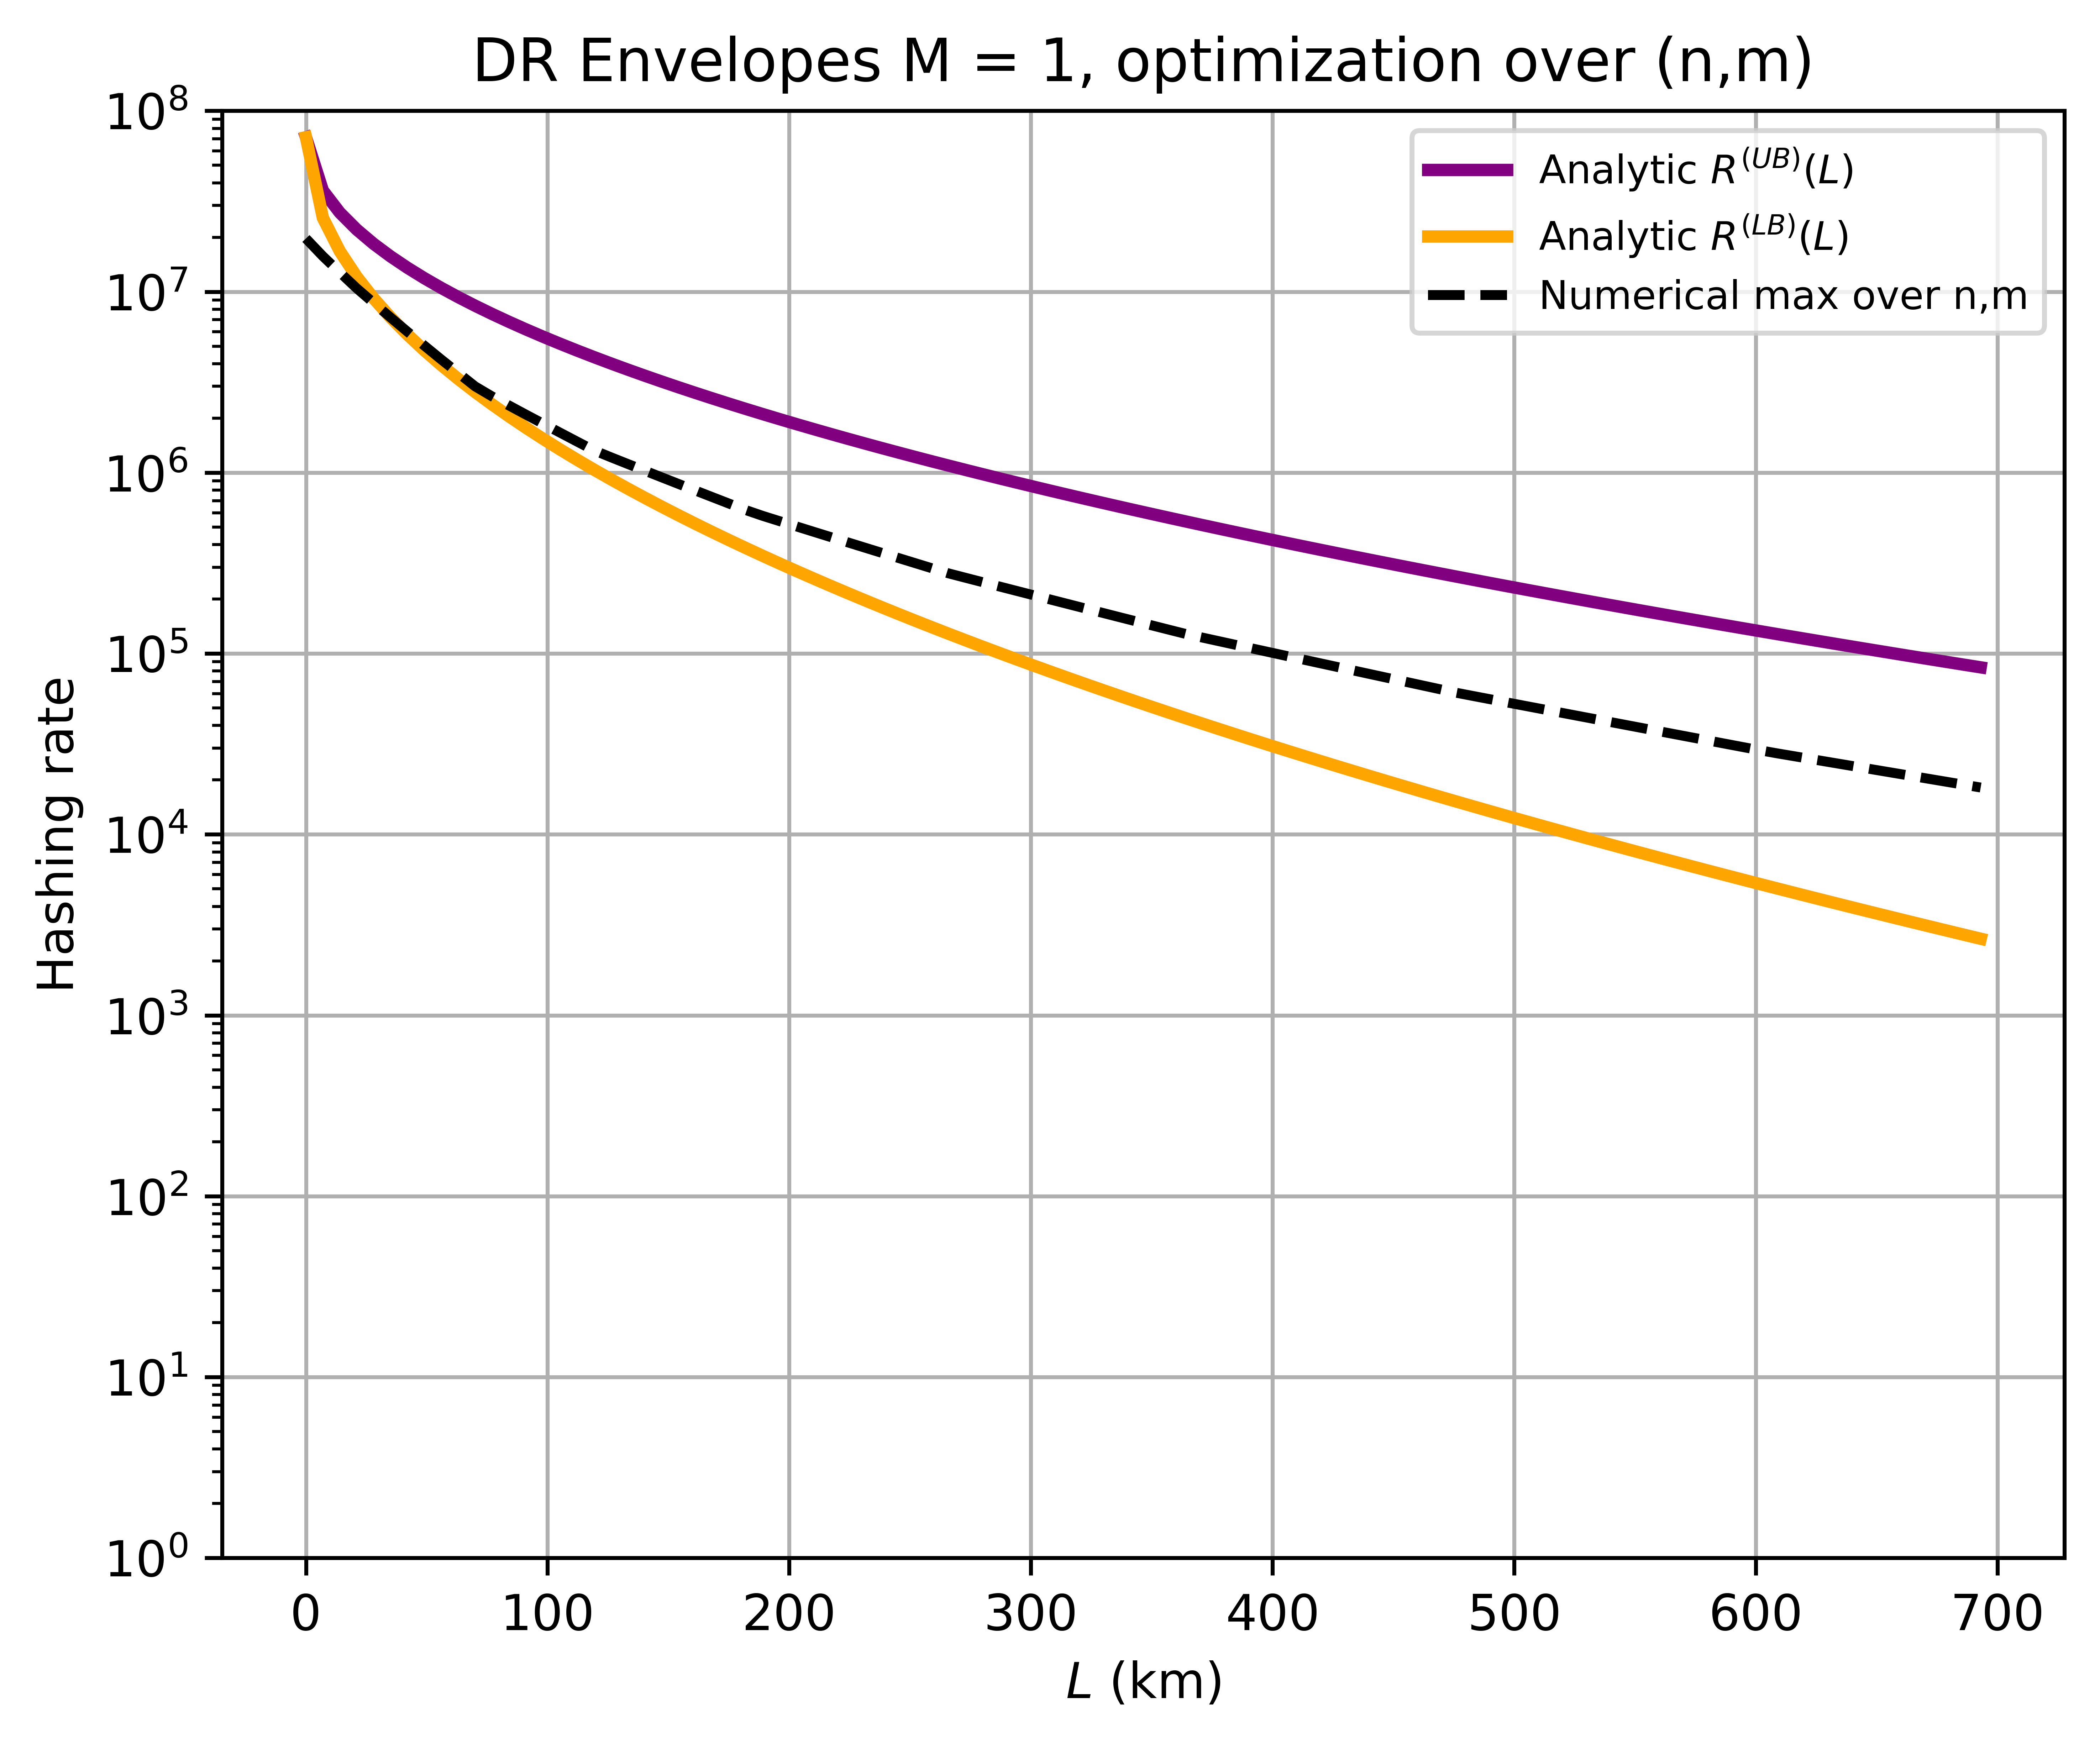

In [22]:
R_UB = (M * mu / (q * tau)) * np.exp(
    -2 * np.sqrt(np.log(1 / q)) * np.sqrt(alpha * Ls)
)

R_LB = (M * mu / (q * tau)) * np.exp(
    -2 * np.sqrt(np.log(1 / (q * (1 - 1 / np.e)))) * np.sqrt(alpha * Ls)
)

fig, ax = plt.subplots(figsize=(6, 5), dpi=1000)

ax.set_yscale("log")
ax.set_title("DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e8)
ax.grid(True)

ax.plot(
    Ls,
    R_UB,
    color="purple",
    linestyle="-",
    linewidth=2.5,
    label=r"Analytic $R^{(UB)}(L)$"
)

ax.plot(
    Ls,
    R_LB,
    color="orange",
    linestyle="-",
    linewidth=2.5,
    label=r"Analytic $R^{(LB)}(L)$"
)

ax.plot(
    Ls,
    fully_maximized_env_actual,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Numerical max over n,m"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The following script considers the case where we can instead numerically derive these lines $R^{UB}$ and $R^{LB}$ by considering each family of A(m,n) (and B(m,n)) for a given value of m, and as above, fitting a LR through the family of points. Then, similar to the above analysis for maximisation over the time multiplexed envelopes for the HR, we can perform a maximisation over each of these LR fits for all values of m to obtain the numerically optimised versions of $R^{UB}$ and $R^{LB}$.

In [23]:
# --------------------------------------------------
# DR A/B locus fits for fixed m
# --------------------------------------------------

def compute_DR_AB_locus_fits_with_points(m, Ls, M, q, tau, alpha, n_vals):
    A_Ls, A_Rs = [], []
    B_Ls, B_Rs = [], []

    for n in n_vals:
        LA, RA = A_point_DR_fixed_m(n, M, m, q, tau, alpha)
        LB, RB = B_point_DR_fixed_m(n, M, m, q, tau, alpha)

        A_Ls.append(LA)
        A_Rs.append(RA)
        B_Ls.append(LB)
        B_Rs.append(RB)

    A_Ls = np.array(A_Ls)
    A_Rs = np.array(A_Rs)
    B_Ls = np.array(B_Ls)
    B_Rs = np.array(B_Rs)

    A_valid = np.isfinite(A_Ls) & np.isfinite(A_Rs) & (A_Rs > 0)
    B_valid = np.isfinite(B_Ls) & np.isfinite(B_Rs) & (B_Rs > 0)

    if np.sum(A_valid) < 2 or np.sum(B_valid) < 2:
        return None, None, A_Ls, A_Rs, B_Ls, B_Rs

    A_slope, A_intercept, *_ = linregress(
        A_Ls[A_valid],
        np.log(A_Rs[A_valid])
    )

    B_slope, B_intercept, *_ = linregress(
        B_Ls[B_valid],
        np.log(B_Rs[B_valid])
    )

    A_fit = np.exp(A_intercept + A_slope * Ls)
    B_fit = np.exp(B_intercept + B_slope * Ls)

    return A_fit, B_fit, A_Ls, A_Rs, B_Ls, B_Rs

In [24]:
# --------------------------------------------------
# Generate DR A/B LR fits over m
# --------------------------------------------------

Ls = np.arange(0, 700, 7)

M = 1
q = 0.7
tau = 1e-8
alpha = (np.log(10) / 10) * 0.2

m_values = np.arange(1, 1000)
n_vals = [1, 2, 4, 8, 16]

DR_A_fit_list = []
DR_B_fit_list = []
DR_AB_points_list = []

for m in m_values:
    A_fit, B_fit, A_Ls_m, A_Rs_m, B_Ls_m, B_Rs_m = compute_DR_AB_locus_fits_with_points(
        m, Ls, M, q, tau, alpha, n_vals
    )

    if A_fit is None or B_fit is None:
        continue

    DR_A_fit_list.append(A_fit)
    DR_B_fit_list.append(B_fit)

    DR_AB_points_list.append({
        "m": m,
        "A_L": A_Ls_m,
        "A_R": A_Rs_m,
        "B_L": B_Ls_m,
        "B_R": B_Rs_m
    })

    print("DR A/B loci generated for m =", m)

DR A/B loci generated for m = 3
DR A/B loci generated for m = 4
DR A/B loci generated for m = 5
DR A/B loci generated for m = 6
DR A/B loci generated for m = 7
DR A/B loci generated for m = 8
DR A/B loci generated for m = 9
DR A/B loci generated for m = 10
DR A/B loci generated for m = 11
DR A/B loci generated for m = 12
DR A/B loci generated for m = 13
DR A/B loci generated for m = 14
DR A/B loci generated for m = 15
DR A/B loci generated for m = 16
DR A/B loci generated for m = 17
DR A/B loci generated for m = 18
DR A/B loci generated for m = 19
DR A/B loci generated for m = 20
DR A/B loci generated for m = 21
DR A/B loci generated for m = 22
DR A/B loci generated for m = 23
DR A/B loci generated for m = 24
DR A/B loci generated for m = 25
DR A/B loci generated for m = 26
DR A/B loci generated for m = 27
DR A/B loci generated for m = 28
DR A/B loci generated for m = 29
DR A/B loci generated for m = 30
DR A/B loci generated for m = 31
DR A/B loci generated for m = 32
DR A/B loci gener

In [25]:
# --------------------------------------------------
# Maximize over the LR fits
# --------------------------------------------------

DR_A_fit_matrix = np.array(DR_A_fit_list)
DR_B_fit_matrix = np.array(DR_B_fit_list)

DR_RUB_numerical = np.max(DR_A_fit_matrix, axis=0)
DR_RLB_numerical = np.max(DR_B_fit_matrix, axis=0)

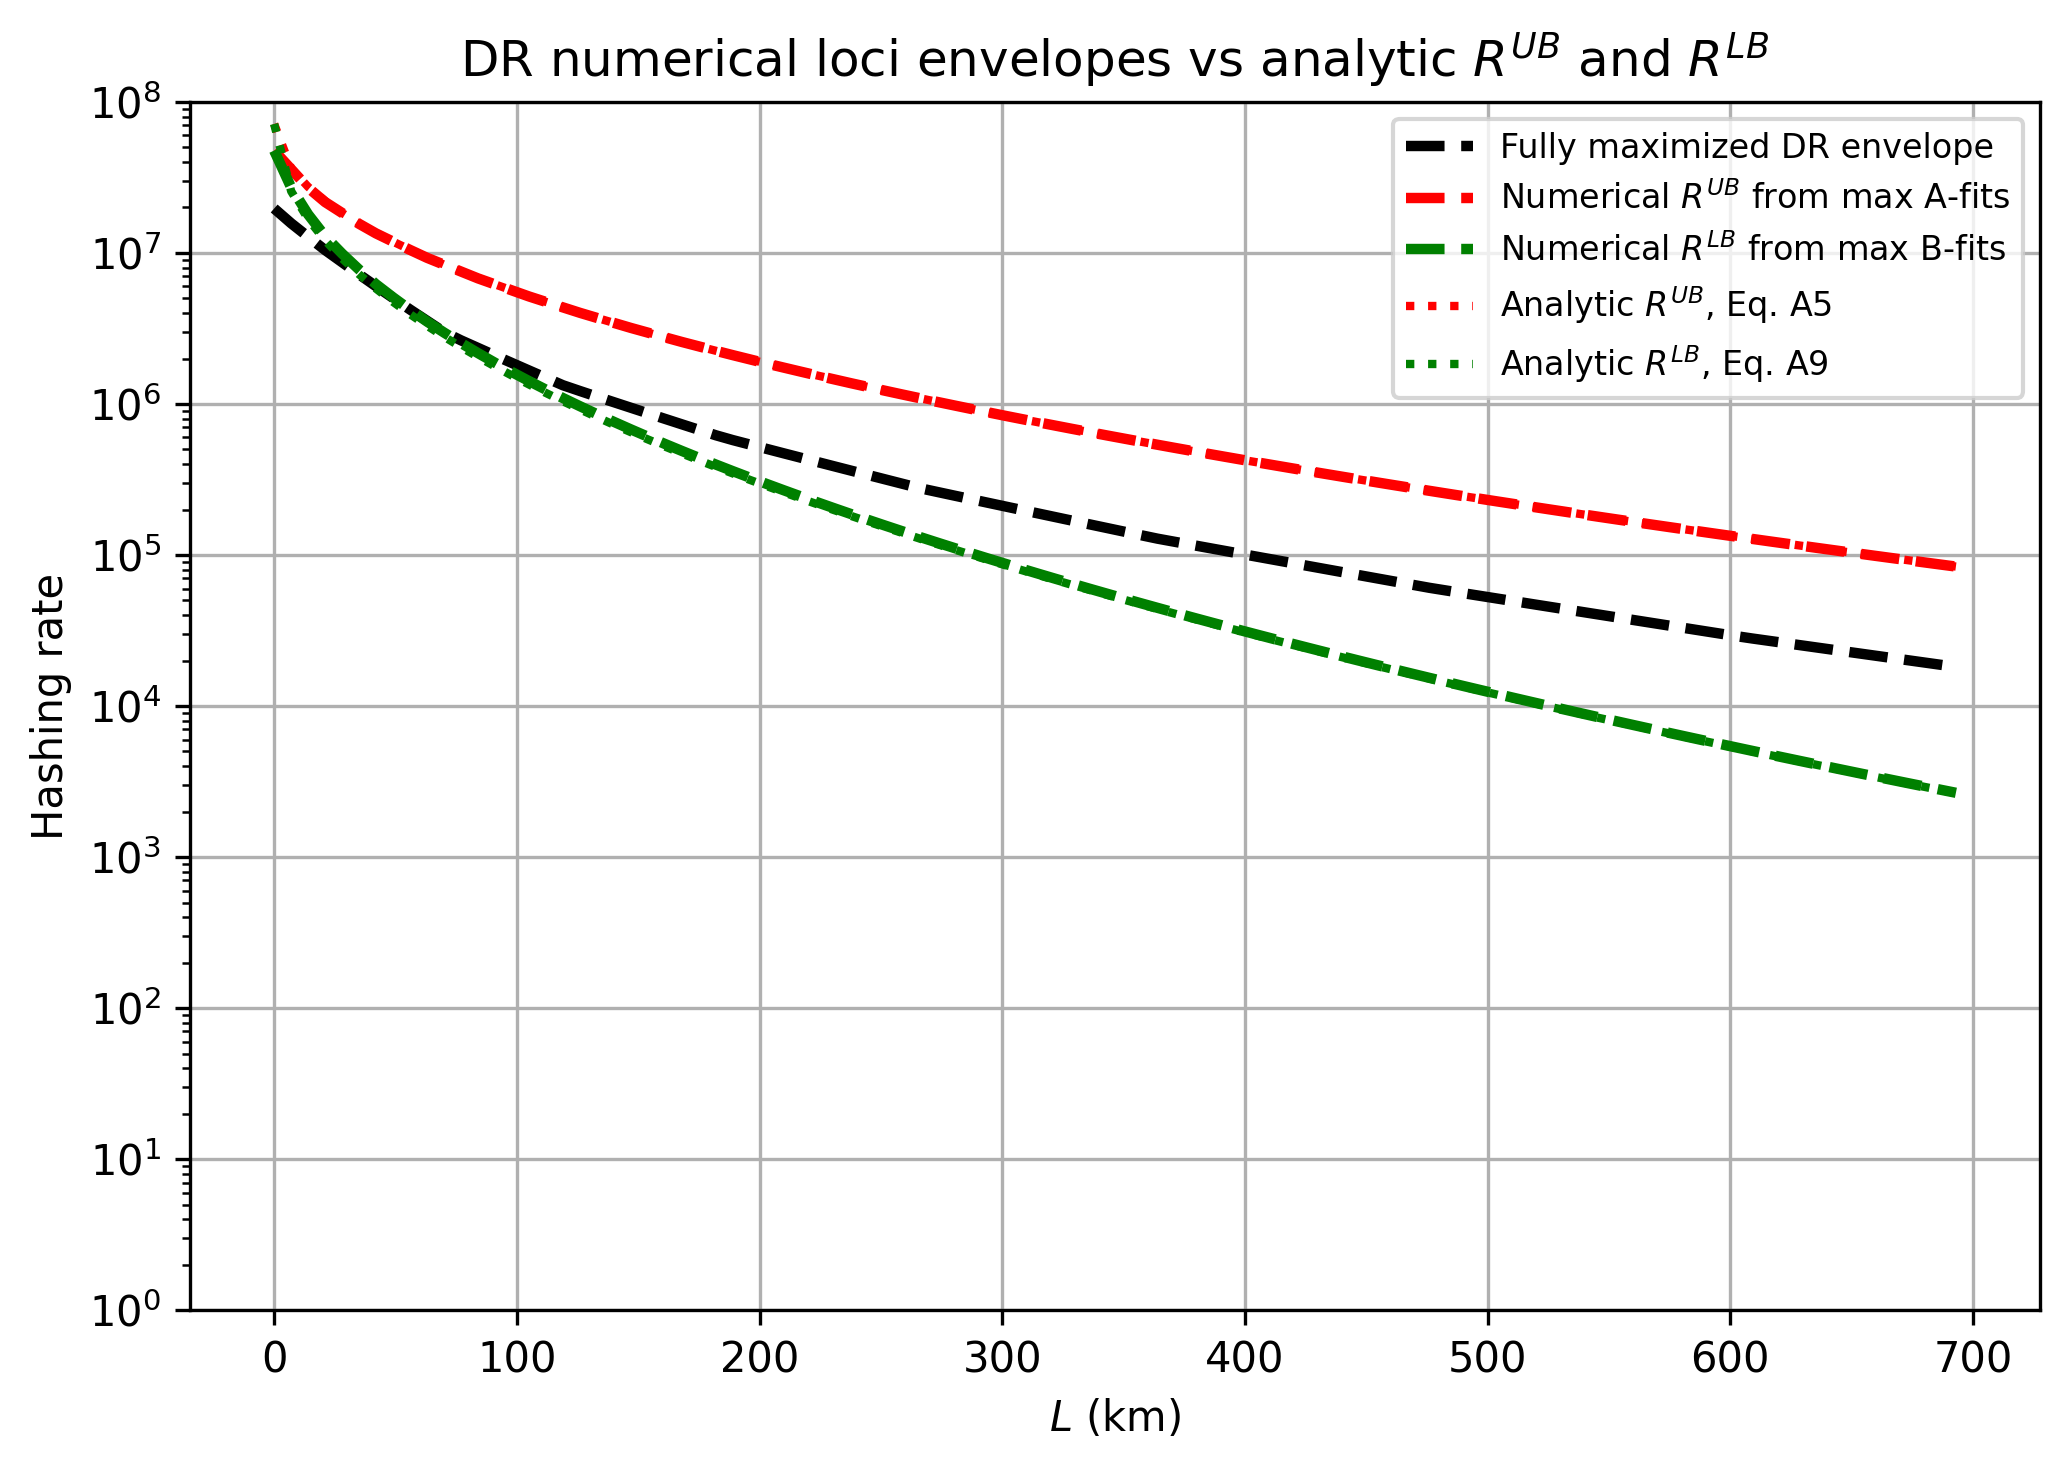

In [26]:
# --------------------------------------------------
# Final comparison plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title(r"DR numerical loci envelopes vs analytic $R^{UB}$ and $R^{LB}$")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e8)
ax.grid(True)

ax.plot(
    Ls,
    fully_maximized_env_actual,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Fully maximized DR envelope"
)

ax.plot(
    Ls,
    DR_RUB_numerical,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=r"Numerical $R^{UB}$ from max A-fits"
)

ax.plot(
    Ls,
    DR_RLB_numerical,
    color="green",
    linestyle="--",
    linewidth=2.5,
    label=r"Numerical $R^{LB}$ from max B-fits"
)

ax.plot(
    Ls,
    R_UB,
    color="red",
    linestyle=":",
    linewidth=2,
    label=r"Analytic $R^{UB}$, Eq. A5"
)

ax.plot(
    Ls,
    R_LB,
    color="green",
    linestyle=":",
    linewidth=2,
    label=r"Analytic $R^{LB}$, Eq. A9"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
def compute_R2(y_true, y_pred):

    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - ss_res / ss_tot

# ---------------------------------
# R^2 for upper bound
# ---------------------------------

valid_UB = (
    np.isfinite(DR_RUB_numerical)
    & np.isfinite(R_UB)
    & (DR_RUB_numerical > 0)
    & (R_UB > 0)
)

R2_UB = compute_R2(
    np.log(R_UB[valid_UB]),
    np.log(DR_RUB_numerical[valid_UB])
)

print(f"R^2 (Numerical vs Analytic R^UB) = {R2_UB:.12f}")


# ---------------------------------
# R^2 for lower bound
# ---------------------------------

valid_LB = (
    np.isfinite(DR_RLB_numerical)
    & np.isfinite(R_LB)
    & (DR_RLB_numerical > 0)
    & (R_LB > 0)
)

R2_LB = compute_R2(
    np.log(R_LB[valid_LB]),
    np.log(DR_RLB_numerical[valid_LB])
)

print(f"R^2 (Numerical vs Analytic R^LB) = {R2_LB:.12f}")

R^2 (Numerical vs Analytic R^UB) = 0.999375134262
R^2 (Numerical vs Analytic R^LB) = 0.999557793562


We have thus proven that the numerically derived form of the lines $R^{UB}$ and $R^{LB}$ match the analytic form given by Equations (A5) and (A9)

# GKP Analysis

In [46]:
plt.figure(dpi  = 1000)

Ls = np.arange(0 , 80 , 1.0)

sigma1 = np.sqrt(0.01)
rates1s1 = [optimal_hashing_rate(sigma1 , L , 1 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates2s1 = [optimal_hashing_rate(sigma1 , L , 2 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates4s1 = [optimal_hashing_rate(sigma1 , L , 4 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates8s1 = [optimal_hashing_rate(sigma1 , L , 8 , 1 , 0.7 , 1e-8 , 1) for L in Ls]
rates16s1 = [optimal_hashing_rate(sigma1 , L , 16 , 1 , 0.7 , 1e-8 , 1) for L in Ls]

/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


<Figure size 6400x4800 with 0 Axes>

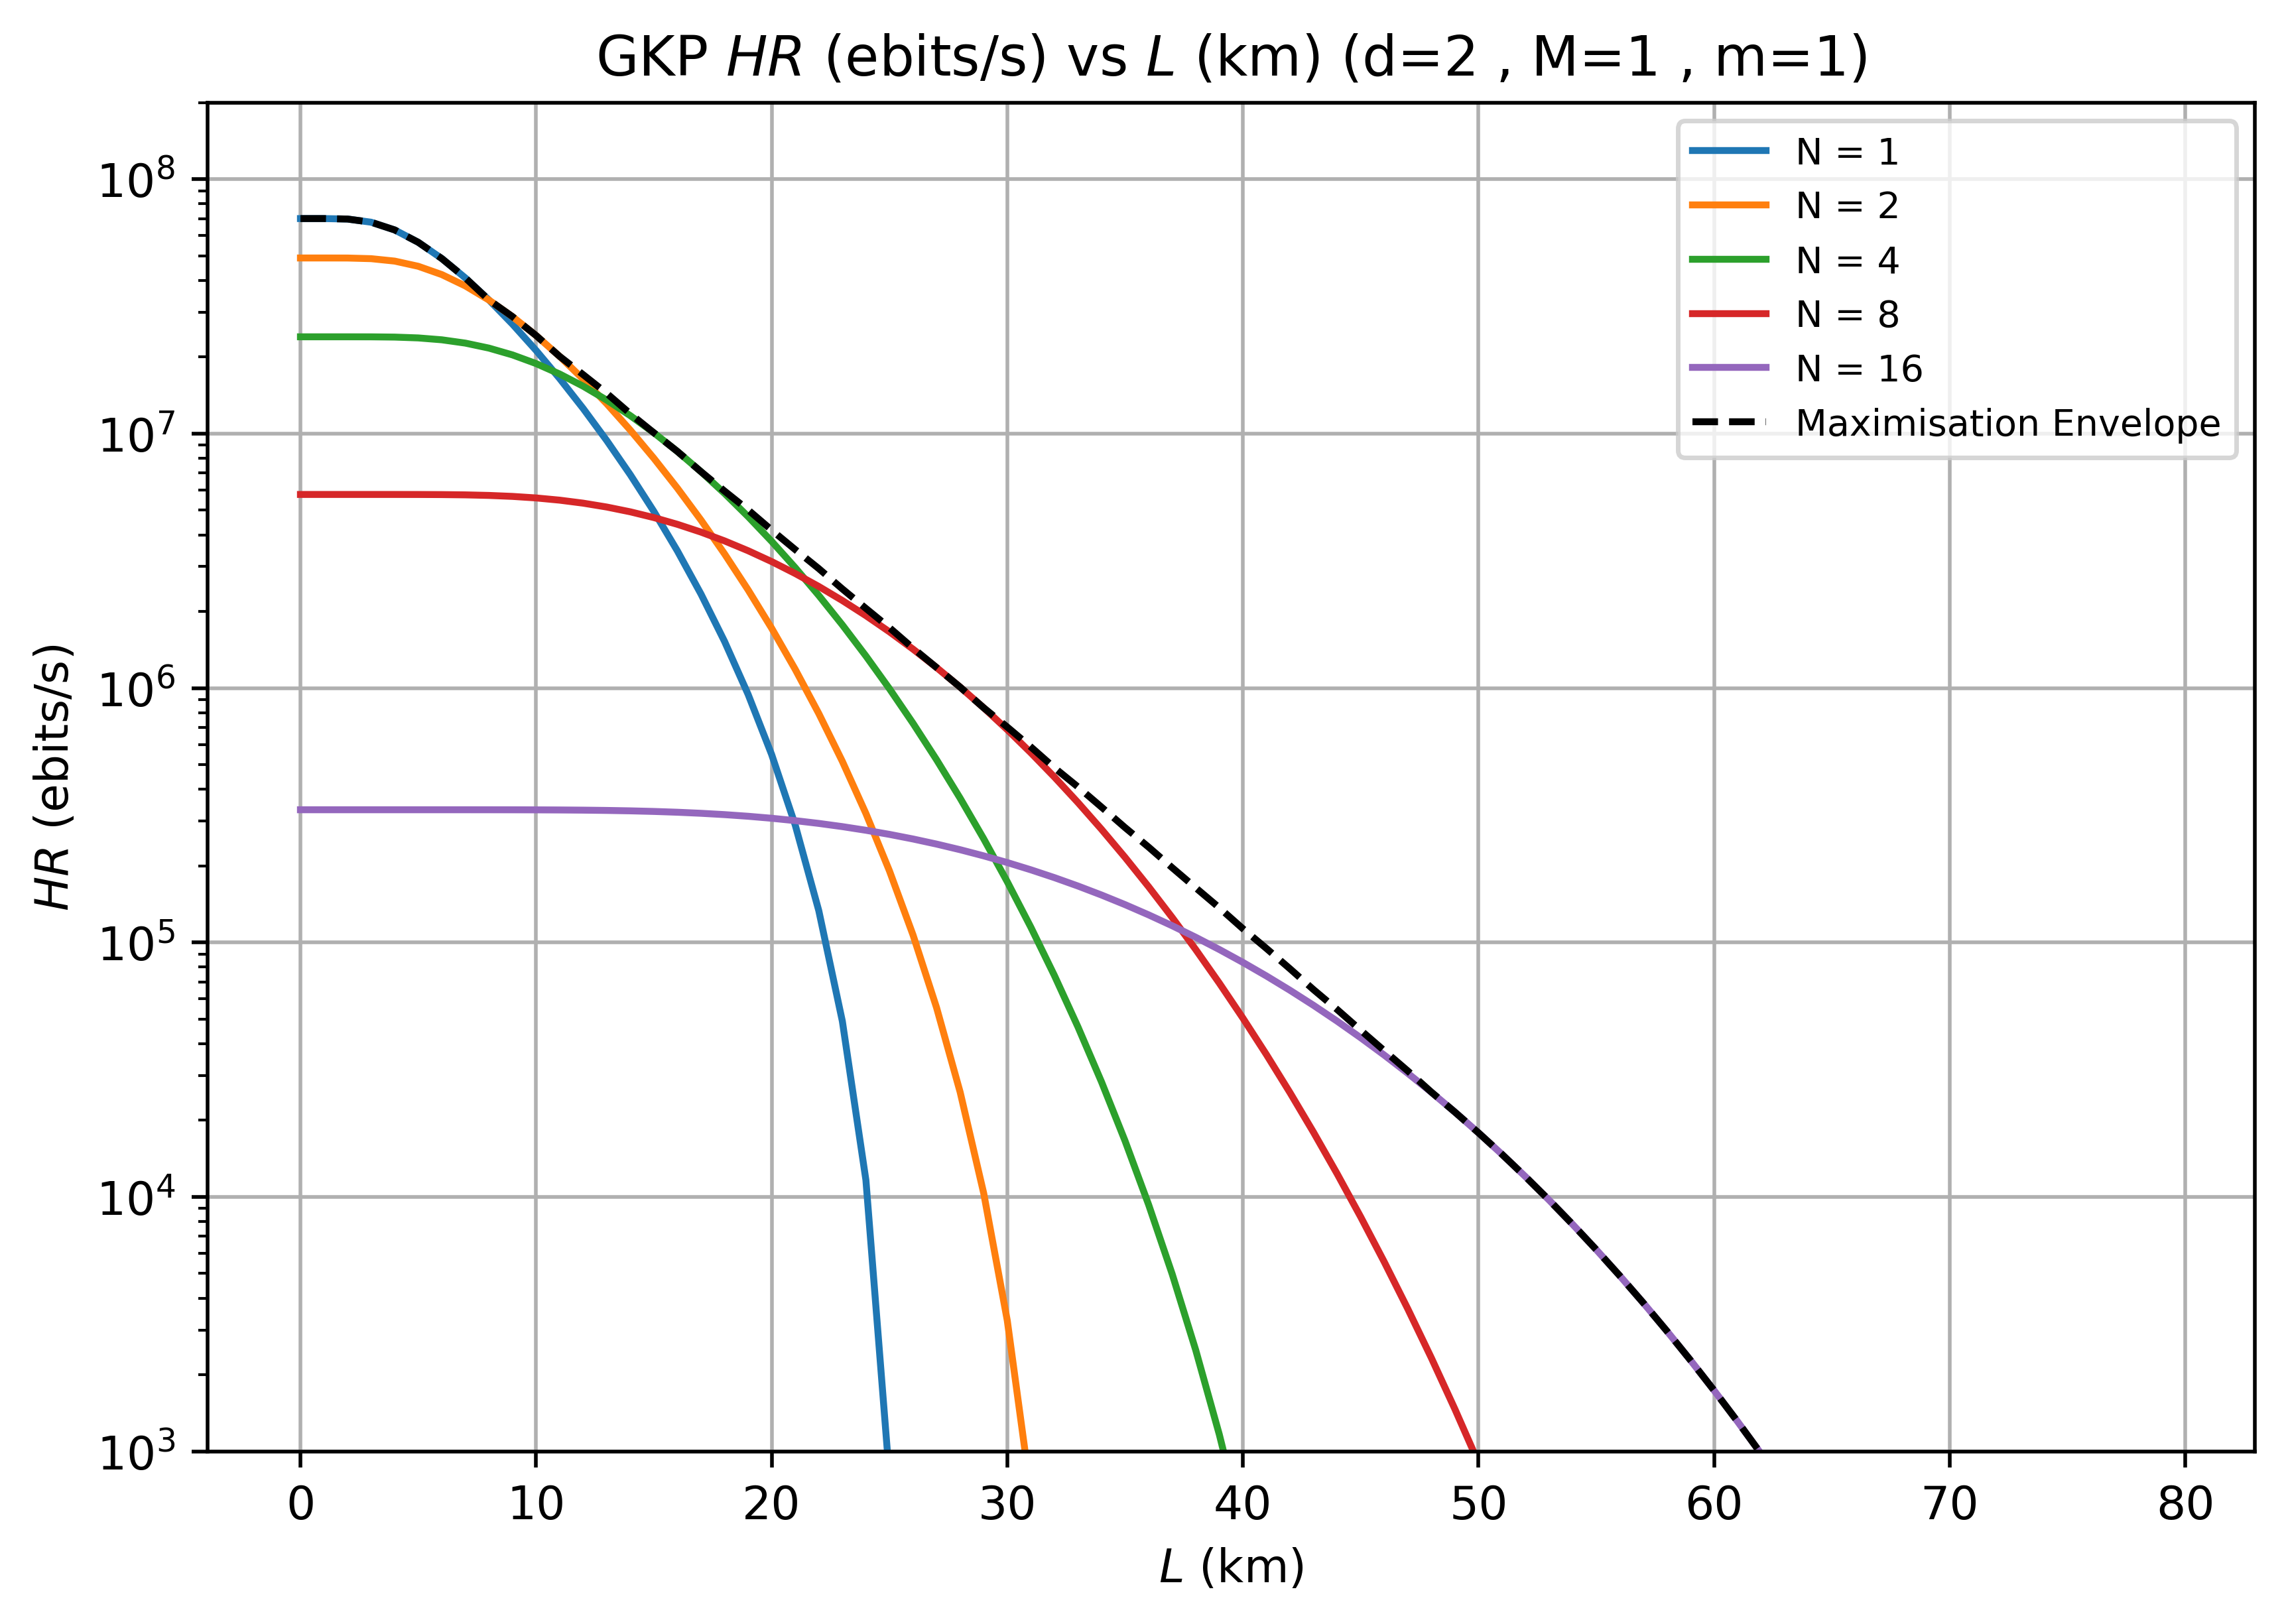

In [50]:
q = 0.7
tau = 1e-8
M = 1
alpha = (np.log(10) / 10) * 0.2

fig, ax = plt.subplots(figsize=(7, 5),dpi = 500)
ax.set_yscale("log")
ax.set_title("GKP $HR$ (ebits/s) vs $L$ (km) (d=2 , M=1 , m=1)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("$HR$ (ebits/s)")
ax.set_ylim(bottom=1e3, top=2e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]

m = 1
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1s1 , rates2s1 , rates4s1 , rates8s1 , rates16s1]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"N = {n}", color=color)

n_scan_vals = np.arange(1 , 17)

rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        _, nu_opt = optimal_hashing_rate(sigma1, L, n, M, q, tau, m, return_nu=True)
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)
        pSWAP = (pc + pf)**2
        pELEM = 1 - (1 - pSWAP)**(M * m)
        pNETWORK = pELEM**(n + 1) * q**n
        rate = pNETWORK / (tau * m)

        # Include hashing bound
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        true_hashing_rate = rate * state_bound

        best_rate = max(best_rate , true_hashing_rate)

    rate_envelope.append(best_rate)

ax.plot(Ls, rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

# log_env = np.log(rate_envelope)


# fit_mask = (Ls > 1) & (Ls < 60)
# slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
# predicted_env1 = np.exp(slope * Ls + intercept)

# ax.plot(Ls, predicted_env1, color="red", linestyle="--", label="Linear Regression fit")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Since the probability of success for GKP encoded photonic qubits cannot be written as $P_{succ}^{GKP} = \mu e^{\alpha L/(n + 1)}$, we must use the numerical optimisation to determine the families A(m,n) and B(m,n) for this encoding

To determine A(m,n) we plot the lines Rmax and Rexp and numerically determine their POI for the x-coordinate, y-coordinate is the height of Rmax line.

To determine B(m,n) we consider x-coordinate from A(m,n) point, and the y-coordinate is the HR for the given value of L

In [30]:
from scipy.optimize import brentq
import numpy as np


def p_succ_GKP(sigma, nu, L, n):
    pc = Pc(sigma, nu, L, n)
    pf = Pf(sigma, nu, L, n)
    return (pc + pf)**2


def nu_opt_GKP(sigma, L, n, M, q, tau, m):
    _, nu_opt = optimal_hashing_rate(sigma,L,n,M,q,tau,m,return_nu=True)
    return nu_opt

# For GKP encoding Rmax and Rexp are written as

# $R_{max}^{GKP} = \frac{q^{n}}{m\tau}$

# $R_{exp}^{GKP} = \frac{q^{n}}{m\tau} (M m P_{succ}^{GKP}[L,n,\sigma,\nu_{opt}])^{(n+1)}$

Here A(m,n) is evaluated as the POI of $R_{max}^{GKP}$ and $R_{exp}^{GKP}$, and point B(m,n) is evaluated at the POI but the y-coordinate evaluated at the HR curve.

In [31]:
def A_point_GKP_fixed_m(sigma,n,M,m,q,tau,L_max_search=200,num_scan=2000):
    """
    Success-only GKP A(m,n), consistent with:

        Rmax = q^n/(m tau)

        Rexp = q^n/(m tau) * [M m p_succ_GKP(L,n,nu_opt)]^(n+1)

    Intersection condition:

        M m p_succ_GKP(L_A,n,nu_opt(L_A,n)) = 1.

    So intersection condition must satisfy (M*m*p) = 1 which is why we return M * m * p - 1
    """

    def intersection_eq(L):
        nu_opt = nu_opt_GKP(sigma, L, n, M, q, tau, m)
        p = p_succ_GKP(sigma, nu_opt, L, n)
        return M * m * p - 1

    L_grid = np.linspace(0, L_max_search, num_scan)
    vals = np.array([intersection_eq(L) for L in L_grid])

    for j in range(len(L_grid) - 1):
        if not np.isfinite(vals[j]) or not np.isfinite(vals[j + 1]):
            continue
        #when we exactly satisfy the condition Mmp == 1
        if vals[j] == 0:
            L_A = L_grid[j]
            R_A = q**n / (m * tau)
            return L_A, R_A
        #when we detect a sign change between neighbouring grid points
        #we use the brentq optimiser to zoom in and find the actual transition
        if vals[j] * vals[j + 1] < 0:
            L_A = brentq(intersection_eq, L_grid[j], L_grid[j + 1])
            R_A = q**n / (m * tau)
            return L_A, R_A

    return np.nan, np.nan


def B_point_GKP_fixed_m(sigma,n,M,m,q,tau,L_max_search=200,num_scan=2000):
    """
    Success-only GKP B(m,n). Same L-coordinate as A.

    At A, M m p_succ = 1, so p_succ = 1/(M m).
    """

    L_A, _ = A_point_GKP_fixed_m(sigma,n,M,m,q,tau,L_max_search=L_max_search,num_scan=num_scan)

    if not np.isfinite(L_A):
        return np.nan, np.nan

    # success_factor = 1 - (1 - 1 / (M * m))**(M * m)

    # R_B = (q**n / (m * tau)) * success_factor**(n + 1)

    R_B = optimal_hashing_rate(sigma,L_A,n,M,q,tau,m)

    return L_A, R_B

In [32]:
n_vals = [1, 2, 4, 8, 16]

sigma1 = np.sqrt(0.01)

q = 0.7
tau = 1e-8
M = 10
m = 1
alpha = (np.log(10) / 10) * 0.2

A_Ls, A_Rs = [], []
B_Ls, B_Rs = [], []

for n in n_vals:
    L_A, R_A = A_point_GKP_fixed_m(sigma1,n, M, m, q, tau)
    L_B, R_B = B_point_GKP_fixed_m(sigma1,n, M, m, q, tau)

    A_Ls.append(L_A)
    A_Rs.append(R_A)

    B_Ls.append(L_B)
    B_Rs.append(R_B)

A_Ls = np.array(A_Ls)
A_Rs = np.array(A_Rs)
B_Ls = np.array(B_Ls)
B_Rs = np.array(B_Rs)

print("A points:")
for n, LA, RA in zip(n_vals, A_Ls, A_Rs):
    print(f"n={n:2d}: L_A={LA}, R_A={RA:.6e}")

print("\nB points:")
for n, LB, RB in zip(n_vals, B_Ls, B_Rs):
    print(f"n={n:2d}: L_B={LB}, R_B={RB:.6e}")

A points:
n= 1: L_A=22.775931435366505, R_A=7.000000e+07
n= 2: L_A=29.962947898599154, R_A=4.900000e+07
n= 4: L_A=43.12967241160193, R_A=2.401000e+07
n= 8: L_A=66.91336316146575, R_A=5.764801e+06
n=16: L_A=109.6795592239296, R_A=3.323293e+05

B points:
n= 1: L_B=22.775931435366505, R_B=2.436674e+06
n= 2: L_B=29.962947898599154, R_B=8.504138e+05
n= 4: L_B=43.12967241160193, R_B=1.228246e+05
n= 8: L_B=66.91336316146575, R_B=3.390337e+03
n=16: L_B=109.6795592239296, R_B=3.797641e+00


# Plot of HR curves for $M=10$ and $m=1$, including the two-part upper bound envelope {Rmax,Rexp} (dashed colour) resulting in points A(m,n) with a LR fit through this family (solid red). Then lower bound points B(m,n) with a LR fit through these showing the lower bound (solid green). Finally, numercially maximised HR (black dashed line).

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_986/3819416822.py:81: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


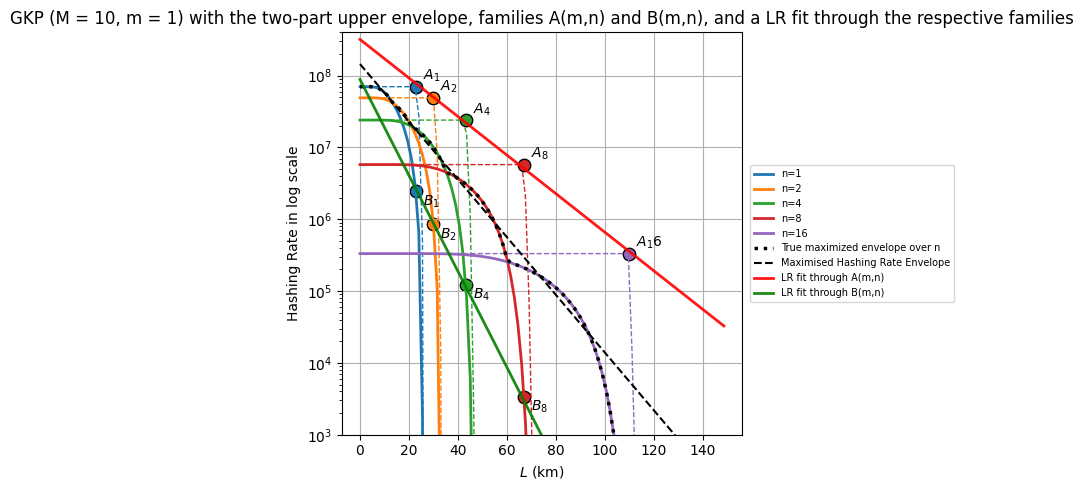

In [39]:
q = 0.7
tau = 1e-8
M = 10
m = 1
sigma1 = np.sqrt(0.01)
alpha = (np.log(10) / 10) * 0.2

Ls = np.arange(0, 150, 1.5)
n_vals = [1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale("log")
ax.set_title(f"GKP (M = {M}, m = {m}) with the two-part upper envelope, families A(m,n) and B(m,n), and a LR fit through the respective families")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=4e8)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, n in enumerate(n_vals):
    color = color_cycle(i)

    exact_rates = []
    Rmax = []
    Rexp = []
    nu_opts = []

    for L in Ls:
        # Optimize nu for the true GKP hashing rate at this L,n
        rate_opt, nu_opt = optimal_hashing_rate(sigma1,L,n,M,q,tau,m,return_nu=True)

        nu_opts.append(nu_opt)
        exact_rates.append(rate_opt)

        # Compute GKP success probability at optimized nu
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)

        p_succ_gkp = (pc + pf)**2

        # Compute hashing bound at optimized nu
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        # Prevent tiny negative numerical artifacts
        state_bound = max(state_bound, 0.0)

        # Paper-style upper pieces, adjusted by the GKP hashing factor
        Rmax_val = q**n / (m * tau)

        Rexp_val = (q**n / (m * tau)) * (M * m * p_succ_gkp)**(n + 1)

        Rmax.append(Rmax_val)
        Rexp.append(Rexp_val)

    exact_rates = np.array(exact_rates)
    Rmax = np.array(Rmax)
    Rexp = np.array(Rexp)

    # Exact optimized GKP hashing-rate curve
    ax.plot(Ls,exact_rates,color=color,linestyle="-",linewidth=2,label=f"n={n}")

    # two-piece upper bound only
    R_upper_piecewise = np.minimum(Rmax, Rexp)

    ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1)

rate_envelope = []
for L in Ls:
    best_rate = 0.0
    for n in n_vals:
        rate = optimal_hashing_rate(sigma1, L, n, M, q, tau, m)
        if np.isfinite(rate):
            best_rate = max(best_rate, rate)
    rate_envelope.append(best_rate)
rate_envelope = np.array(rate_envelope)
# Plot actual maximized envelope
ax.plot(Ls,rate_envelope,color="black",linestyle=":",linewidth=2.5,label="True maximized envelope over n")

log_env = np.log(rate_envelope)
fit_mask = (Ls > 10) & (Ls < 90)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")
# Numerical family A(m,n) and B(m,n)
for i , n in enumerate(n_vals):
    color = color_cycle(i)
    ax.scatter([A_Ls[i]],[A_Rs[i]],s=80,edgecolor="black",color=color,marker="o")
    ax.scatter([B_Ls[i]],[B_Rs[i]],s=80,edgecolor="black",color=color,marker="o")

for n, LA, RA, LB, RB in zip(n_vals, A_Ls, A_Rs, B_Ls, B_Rs):
    ax.annotate(f"$A_{n}$", (LA, RA), textcoords="offset points", xytext=(5, 5), fontsize=10)
    ax.annotate(f"$B_{n}$", (LB, RB), textcoords="offset points", xytext=(5, -10), fontsize=10)

# --------------------------------------------------
# Log-linear regression through A and B points
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="red",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through B(m,n)")

ax.legend(
    fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [40]:
plt.figure(dpi  = 1000)

Ls = np.arange(0 , 150 , 1.5)

sigma1 = np.sqrt(0.01)
rates1s1 = [optimal_hashing_rate(sigma1 , L , 1 , 10 , 0.7 , 1e-8 , 1) for L in Ls]
rates2s1 = [optimal_hashing_rate(sigma1 , L , 2 , 10 , 0.7 , 1e-8 , 1) for L in Ls]
rates4s1 = [optimal_hashing_rate(sigma1 , L , 4 , 10 , 0.7 , 1e-8 , 1) for L in Ls]
rates8s1 = [optimal_hashing_rate(sigma1 , L , 8 , 10 , 0.7 , 1e-8 , 1) for L in Ls]
rates16s1 = [optimal_hashing_rate(sigma1 , L , 16 , 10 , 0.7 , 1e-8 , 1) for L in Ls]

/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


<Figure size 6400x4800 with 0 Axes>

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_986/2620147135.py:55: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


A points:
n=1: L_A=22.775931435366505, R_A=7.000000e+07
n=2: L_A=29.962947898599154, R_A=4.900000e+07
n=4: L_A=43.12967241160193, R_A=2.401000e+07
n=8: L_A=66.91336316146575, R_A=5.764801e+06
n=16: L_A=109.6795592239296, R_A=3.323293e+05
B points:
n=1: L_B=22.775931435366505, R_B=2.436674e+06
n=2: L_B=29.962947898599154, R_B=8.504138e+05
n=4: L_B=43.12967241160193, R_B=1.228246e+05
n=8: L_B=66.91336316146575, R_B=3.390337e+03
n=16: L_B=109.6795592239296, R_B=3.797641e+00


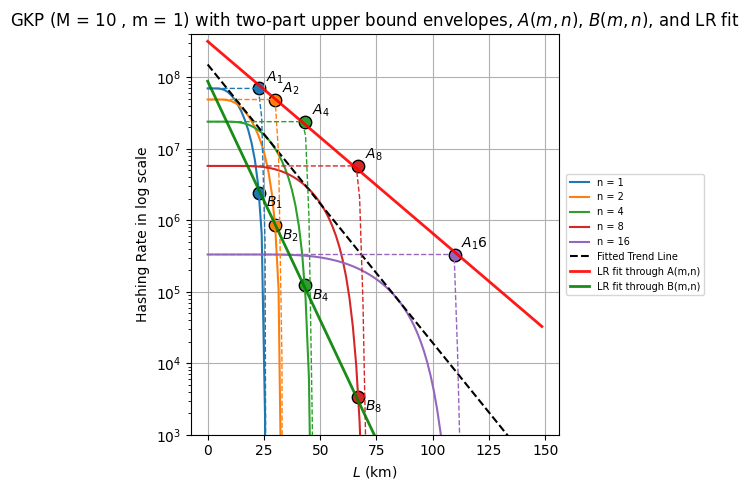

In [44]:
q = 0.7
tau = 1e-8
M = 10
alpha = (np.log(10) / 10) * 0.2

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("GKP (M = 10 , m = 1) with two-part upper bound envelopes, "
             r"$A(m,n)$, $B(m,n)$, and LR fit")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=4e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]

m = 1
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1s1 , rates2s1 , rates4s1 , rates8s1 , rates16s1]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 16)

rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        _, nu_opt = optimal_hashing_rate(sigma1, L, n, M, q, tau, m, return_nu=True)
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)
        pSWAP = (pc + pf)**2
        pELEM = 1 - (1 - pSWAP)**(M * m)
        pNETWORK = pELEM**(n + 1) * q**n
        rate = pNETWORK / (tau * m)

        # Include hashing bound
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        true_hashing_rate = rate * state_bound

        best_rate = max(best_rate , true_hashing_rate)

    rate_envelope.append(best_rate)

# ax.plot(Ls, rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

log_env = np.log(rate_envelope)


fit_mask = (Ls > 10) & (Ls < 90)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Fitted Trend Line")


for i, n in enumerate(n_vals):
    color = color_cycle(i)

    Rmax = []
    Rexp = []
    nu_opts = []

    for L in Ls:
        # Optimize nu for the true GKP hashing rate at this L,n
        _, nu_opt = optimal_hashing_rate(sigma1,L,n,M,q,tau,m,return_nu=True)

        nu_opts.append(nu_opt)


        # Compute GKP success probability at optimized nu
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)

        p_succ_gkp = (pc + pf)**2

        # Compute hashing bound at optimized nu
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        # Prevent tiny negative numerical artifacts
        state_bound = max(state_bound, 0.0)

        # Paper-style upper pieces, adjusted by the GKP hashing factor
        Rmax_val = q**n / (m * tau)
        Rexp_val = (q**n / (m * tau)) * (M * m * p_succ_gkp)**(n + 1)

        Rmax.append(Rmax_val)
        Rexp.append(Rexp_val)

    Rmax = np.array(Rmax)
    Rexp = np.array(Rexp)


    # two-piece upper bound only
    R_upper_piecewise = np.minimum(Rmax, Rexp)
    ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1)

ax.legend(fontsize=8)
A_Ls, A_Rs = [], []
B_Ls, B_Rs = [], []

for n in n_vals:
    L_A, R_A = A_point_GKP_fixed_m(
        sigma1, n, M, m, q, tau,
        L_max_search=200,
        num_scan=2000
    )

    L_B, R_B = B_point_GKP_fixed_m(
        sigma1, n, M, m, q, tau,
        L_max_search=200,
        num_scan=2000
    )

    A_Ls.append(L_A)
    A_Rs.append(R_A)
    B_Ls.append(L_B)
    B_Rs.append(R_B)

A_Ls = np.array(A_Ls)
A_Rs = np.array(A_Rs)
B_Ls = np.array(B_Ls)
B_Rs = np.array(B_Rs)

print("A points:")
for n, LA, RA in zip(n_vals, A_Ls, A_Rs):
    print(f"n={n}: L_A={LA}, R_A={RA:.6e}")

print("B points:")
for n, LB, RB in zip(n_vals, B_Ls, B_Rs):
    print(f"n={n}: L_B={LB}, R_B={RB:.6e}")
# Numerical family A(m,n) and B(m,n)
for i , n in enumerate(n_vals):
    color = color_cycle(i)
    ax.scatter([A_Ls[i]],[A_Rs[i]],s=80,edgecolor="black",color=color,marker="o")
    ax.scatter([B_Ls[i]],[B_Rs[i]],s=80,edgecolor="black",color=color,marker="o")

for n, LA, RA, LB, RB in zip(n_vals, A_Ls, A_Rs, B_Ls, B_Rs):
    ax.annotate(f"$A_{n}$", (LA, RA), textcoords="offset points", xytext=(5, 5), fontsize=10)
    ax.annotate(f"$B_{n}$", (LB, RB), textcoords="offset points", xytext=(5, -10), fontsize=10)

# --------------------------------------------------
# Log-linear regression through A and B points
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="red",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through B(m,n)")

ax.legend(
    fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/Users/conallcampbell/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)
/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_986/1005853015.py:55: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


A points:
n=1: L_A=22.775931435366505, R_A=7.000000e+07
n=2: L_A=29.962947898599154, R_A=4.900000e+07
n=4: L_A=43.12967241160193, R_A=2.401000e+07
n=8: L_A=66.91336316146575, R_A=5.764801e+06
n=16: L_A=109.6795592239296, R_A=3.323293e+05
B points:
n=1: L_B=22.775931435366505, R_B=2.436674e+06
n=2: L_B=29.962947898599154, R_B=8.504138e+05
n=4: L_B=43.12967241160193, R_B=1.228246e+05
n=8: L_B=66.91336316146575, R_B=3.390337e+03
n=16: L_B=109.6795592239296, R_B=3.797641e+00


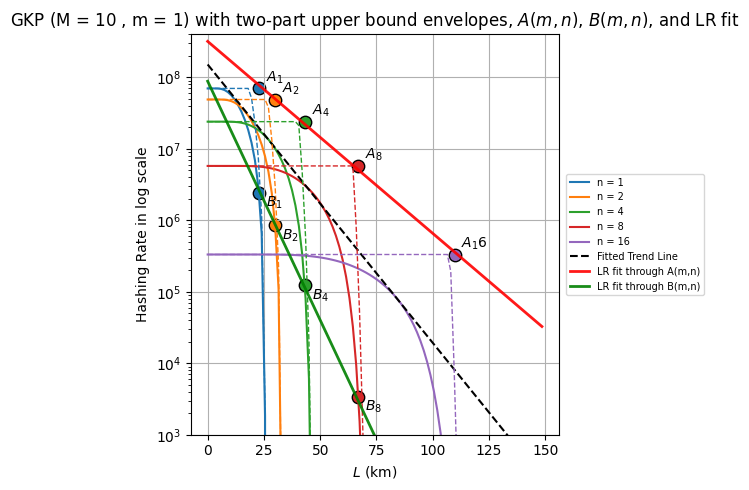

In [45]:
q = 0.7
tau = 1e-8
M = 10
alpha = (np.log(10) / 10) * 0.2

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_yscale("log")
ax.set_title("GKP (M = 10 , m = 1) with two-part upper bound envelopes, "
             r"$A(m,n)$, $B(m,n)$, and LR fit")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=4e8)
ax.grid(True)

n_vals = [1 , 2 , 4 , 8 , 16]

m = 1
Ls = np.array(Ls)  # ensure it's an array
gkp_list = [rates1s1 , rates2s1 , rates4s1 , rates8s1 , rates16s1]

color_cycle = plt.get_cmap("tab10")

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

n_scan_vals = np.arange(1 , 16)

rate_envelope = []
for L in Ls:
    best_rate = 0
    for n in n_scan_vals:
        _, nu_opt = optimal_hashing_rate(sigma1, L, n, M, q, tau, m, return_nu=True)
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)
        pSWAP = (pc + pf)**2
        pELEM = 1 - (1 - pSWAP)**(M * m)
        pNETWORK = pELEM**(n + 1) * q**n
        rate = pNETWORK / (tau * m)

        # Include hashing bound
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        true_hashing_rate = rate * state_bound

        best_rate = max(best_rate , true_hashing_rate)

    rate_envelope.append(best_rate)

# ax.plot(Ls, rate_envelope, color="black", linestyle="--", linewidth=1.5, label="Maximisation Envelope")

log_env = np.log(rate_envelope)


fit_mask = (Ls > 10) & (Ls < 90)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Fitted Trend Line")


for i, n in enumerate(n_vals):
    color = color_cycle(i)

    Rmax = []
    Rexp = []
    nu_opts = []

    for L in Ls:
        # Optimize nu for the true GKP hashing rate at this L,n
        _, nu_opt = optimal_hashing_rate(sigma1,L,n,M,q,tau,m,return_nu=True)

        nu_opts.append(nu_opt)


        # Compute GKP success probability at optimized nu
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)

        p_succ_gkp = (pc + pf)**2

        # Compute hashing bound at optimized nu
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        # Prevent tiny negative numerical artifacts
        state_bound = max(state_bound, 0.0)

        # Paper-style upper pieces, adjusted by the GKP hashing factor
        Rmax_val = q**n / (m * tau)
        Rexp_val = (q**n / (m * tau)) * (M * m * p_succ_gkp)**(n + 1) * state_bound

        Rmax.append(Rmax_val)
        Rexp.append(Rexp_val)

    Rmax = np.array(Rmax)
    Rexp = np.array(Rexp)


    # two-piece upper bound only
    R_upper_piecewise = np.minimum(Rmax, Rexp)
    ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1)

ax.legend(fontsize=8)
A_Ls, A_Rs = [], []
B_Ls, B_Rs = [], []

for n in n_vals:
    L_A, R_A = A_point_GKP_fixed_m(
        sigma1, n, M, m, q, tau,
        L_max_search=200,
        num_scan=2000
    )

    L_B, R_B = B_point_GKP_fixed_m(
        sigma1, n, M, m, q, tau,
        L_max_search=200,
        num_scan=2000
    )

    A_Ls.append(L_A)
    A_Rs.append(R_A)
    B_Ls.append(L_B)
    B_Rs.append(R_B)

A_Ls = np.array(A_Ls)
A_Rs = np.array(A_Rs)
B_Ls = np.array(B_Ls)
B_Rs = np.array(B_Rs)

print("A points:")
for n, LA, RA in zip(n_vals, A_Ls, A_Rs):
    print(f"n={n}: L_A={LA}, R_A={RA:.6e}")

print("B points:")
for n, LB, RB in zip(n_vals, B_Ls, B_Rs):
    print(f"n={n}: L_B={LB}, R_B={RB:.6e}")
# Numerical family A(m,n) and B(m,n)
for i , n in enumerate(n_vals):
    color = color_cycle(i)
    ax.scatter([A_Ls[i]],[A_Rs[i]],s=80,edgecolor="black",color=color,marker="o")
    ax.scatter([B_Ls[i]],[B_Rs[i]],s=80,edgecolor="black",color=color,marker="o")

for n, LA, RA, LB, RB in zip(n_vals, A_Ls, A_Rs, B_Ls, B_Rs):
    ax.annotate(f"$A_{n}$", (LA, RA), textcoords="offset points", xytext=(5, 5), fontsize=10)
    ax.annotate(f"$B_{n}$", (LB, RB), textcoords="offset points", xytext=(5, -10), fontsize=10)

# --------------------------------------------------
# Log-linear regression through A and B points
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="red",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through B(m,n)")

ax.legend(
    fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

# Plot of maximiesd HR envelope (black dashed), $R^{UB}$ (solid red), and $R^{LB}$ (solid green) with families A(m,n) and B(m,n) drawn to show agreement with LR fit

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1392/3694900754.py:70: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


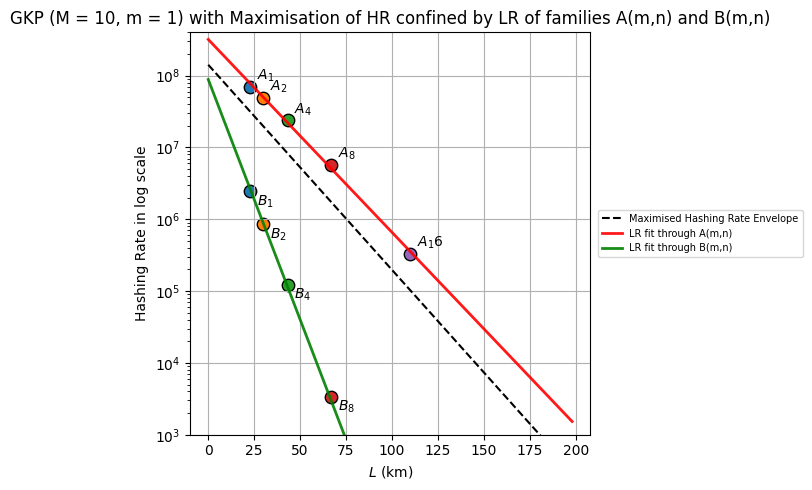

In [34]:
q = 0.7
tau = 1e-8
M = 10
m = 1
sigma1 = np.sqrt(0.01)
alpha = (np.log(10) / 10) * 0.2

Ls = np.arange(0, 200, 2)
n_vals = [1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale("log")
ax.set_title(f"GKP (M = {M}, m = {m}) with Maximisation of HR confined by LR of families A(m,n) and B(m,n)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing Rate in log scale")
ax.set_ylim(bottom=1e3, top=4e8)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, n in enumerate(n_vals):
    color = color_cycle(i)

    exact_rates = []
    Rmax = []
    Rexp = []
    nu_opts = []

    for L in Ls:
        # Optimize nu for the true GKP hashing rate at this L,n
        rate_opt, nu_opt = optimal_hashing_rate(sigma1,L,n,M,q,tau,m,return_nu=True)

        nu_opts.append(nu_opt)
        exact_rates.append(rate_opt)

        # Compute GKP success probability at optimized nu
        pc = Pc(sigma1, nu_opt, L, n)
        pf = Pf(sigma1, nu_opt, L, n)

        p_succ_gkp = (pc + pf)**2

        # Compute hashing bound at optimized nu
        vec = chain_function(new_vector(sigma1, nu_opt, L, n), n)
        state_bound = hashing_bound(BSM_mixture_chain(vec))

        # Prevent tiny negative numerical artifacts
        state_bound = max(state_bound, 0.0)

        # Paper-style upper pieces, adjusted by the GKP hashing factor
        Rmax_val = q**n / (m * tau)

        Rexp_val = (q**n / (m * tau)) * (M * m * p_succ_gkp)**(n + 1)

        Rmax.append(Rmax_val)
        Rexp.append(Rexp_val)

    exact_rates = np.array(exact_rates)
    Rmax = np.array(Rmax)
    Rexp = np.array(Rexp)

    # Exact optimized GKP hashing-rate curve
    # ax.plot(Ls,exact_rates,color=color,linestyle="-",linewidth=2,label=f"n={n}")

    # two-piece upper bound only
    R_upper_piecewise = np.minimum(Rmax, Rexp)

    # ax.plot(Ls,R_upper_piecewise,color=color,linestyle="--",linewidth=1)


log_env = np.log(rate_envelope)


fit_mask = (Ls > 10) & (Ls < 90)
slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])
predicted_env1 = np.exp(slope * Ls + intercept)

ax.plot(Ls, predicted_env1, color="black", linestyle="--", label="Maximised Hashing Rate Envelope")
# Numerical family A(m,n) and B(m,n)
for i , n in enumerate(n_vals):
    color = color_cycle(i)
    ax.scatter([A_Ls[i]],[A_Rs[i]],s=80,edgecolor="black",color=color,marker="o")
    ax.scatter([B_Ls[i]],[B_Rs[i]],s=80,edgecolor="black",color=color,marker="o")

for n, LA, RA, LB, RB in zip(n_vals, A_Ls, A_Rs, B_Ls, B_Rs):
    ax.annotate(f"$A_{n}$", (LA, RA), textcoords="offset points", xytext=(5, 5), fontsize=10)
    ax.annotate(f"$B_{n}$", (LB, RB), textcoords="offset points", xytext=(5, -10), fontsize=10)

# --------------------------------------------------
# Log-linear regression through A and B points
# --------------------------------------------------

A_valid = (A_Rs > 0) & np.isfinite(A_Ls) & np.isfinite(A_Rs)
A_slope, A_intercept, *_ = linregress(A_Ls[A_valid],np.log(A_Rs[A_valid]))
A_fit = np.exp(A_intercept + A_slope * Ls)

B_valid = (B_Rs > 0) & np.isfinite(B_Ls) & np.isfinite(B_Rs)
B_slope, B_intercept, *_ = linregress(B_Ls[B_valid],np.log(B_Rs[B_valid]))
B_fit = np.exp(B_intercept + B_slope * Ls)

ax.plot(Ls,A_fit,color="red",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through A(m,n)")
ax.plot(Ls,B_fit,color="green",linestyle="-",linewidth=2,alpha=0.9,label="LR fit through B(m,n)")

ax.legend(
    fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

# Envelope Analysis

As shown in the paper, these plots above are conducted for singular values of $m$, and when we consider $m\in{1,1000}$ we thus find that we can maximise over these curves to obtain the overall envelope maximised over parameters $(n,m)$. For the case of the DR encoding, the analytic form of these envelopes is derived in Appendix A in equations (A5) and (A9) to be

$R^{UB}(L) = \frac{M\mu}{q\tau} e^{-\Big(2\sqrt{log(1/q)}\Big)\sqrt{\alpha L}}$

$R^{UB}(L) = \frac{M\mu}{q\tau} e^{-\Big(2\sqrt{log(1/q(1-1/e))}\Big)\sqrt{\alpha L}}$

Thus, using these boundaries we can thus confirm the subexponential behaviour of the DR encoding.

However, as noted in the GKP case we had to numerically obtain the families A(m,n) and B(m,n). So to obtain the lines $R^{UB}$ and $R^{LB}$ for this encoding, like we perform for the maximised HR envelopes, we vary the parameter m for these LR lines and we perform a maximisation over the fits for the fmailies A(m,n) and B(m,n) to respectively obtain $R^{UB}$ and $R^{LB}$.

# GKP Envelope Definition

In [13]:
def compute_envelope(m, sigma, Ls, M, q, tau):

    n_scan_vals = np.arange(1, 16)

    rate_envelope = []

    for L in Ls:

        best_rate = 0

        for n in n_scan_vals:

            _, nu_opt = optimal_hashing_rate(
                sigma, L, n, M, q, tau, m, return_nu=True
            )

            pc = Pc(sigma, nu_opt, L, n)
            pf = Pf(sigma, nu_opt, L, n)

            pSWAP = (pc + pf)**2
            pELEM = 1 - (1 - pSWAP)**(M * m)
            pNETWORK = pELEM**(n + 1) * q**n

            rate = pNETWORK / (tau * m)

            vec = chain_function(new_vector(sigma, nu_opt, L, n), n)
            state_bound = hashing_bound(BSM_mixture_chain(vec))

            true_hashing_rate = rate * state_bound

            best_rate = max(best_rate, true_hashing_rate)

        rate_envelope.append(best_rate)

    rate_envelope = np.array(rate_envelope)

    # fit exponential envelope
    log_env = np.log(rate_envelope)

    fit_mask = (Ls > 10) & (Ls < 40)

    slope, intercept, *_ = linregress(Ls[fit_mask], log_env[fit_mask])

    predicted_env = np.exp(slope * Ls + intercept)

    return predicted_env

# HR Envelope Data Generation

In [14]:
Ls = np.arange(0, 200, 2)
Ls = np.array(Ls)

sigma = np.sqrt(0.01)

M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1,20)

envs = []

for m in m_values:
    print("Computing envelope for m =", m)
    env = compute_envelope(m, sigma, Ls, M, q, tau)
    envs.append(env)

Computing envelope for m = 1


/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_26744/1347092710.py:38: RuntimeWarning: divide by zero encountered in log
  log_env = np.log(rate_envelope)


Computing envelope for m = 2
Computing envelope for m = 3
Computing envelope for m = 4
Computing envelope for m = 5
Computing envelope for m = 6
Computing envelope for m = 7
Computing envelope for m = 8
Computing envelope for m = 9
Computing envelope for m = 10
Computing envelope for m = 11
Computing envelope for m = 12
Computing envelope for m = 13
Computing envelope for m = 14
Computing envelope for m = 15
Computing envelope for m = 16
Computing envelope for m = 17
Computing envelope for m = 18
Computing envelope for m = 19


# Maximisation over ALL HR envelopes

In [15]:
Ls = np.arange(0, 200, 2)
Ls = np.array(Ls)

# dr_envs is already a list of arrays, one per m
gkp_env_matrix = np.array(envs)  # shape: (len(m_values), len(Ls))
# fully maximized envelope over both n and m
fully_maximized_gkp_env = np.max(gkp_env_matrix, axis=0)

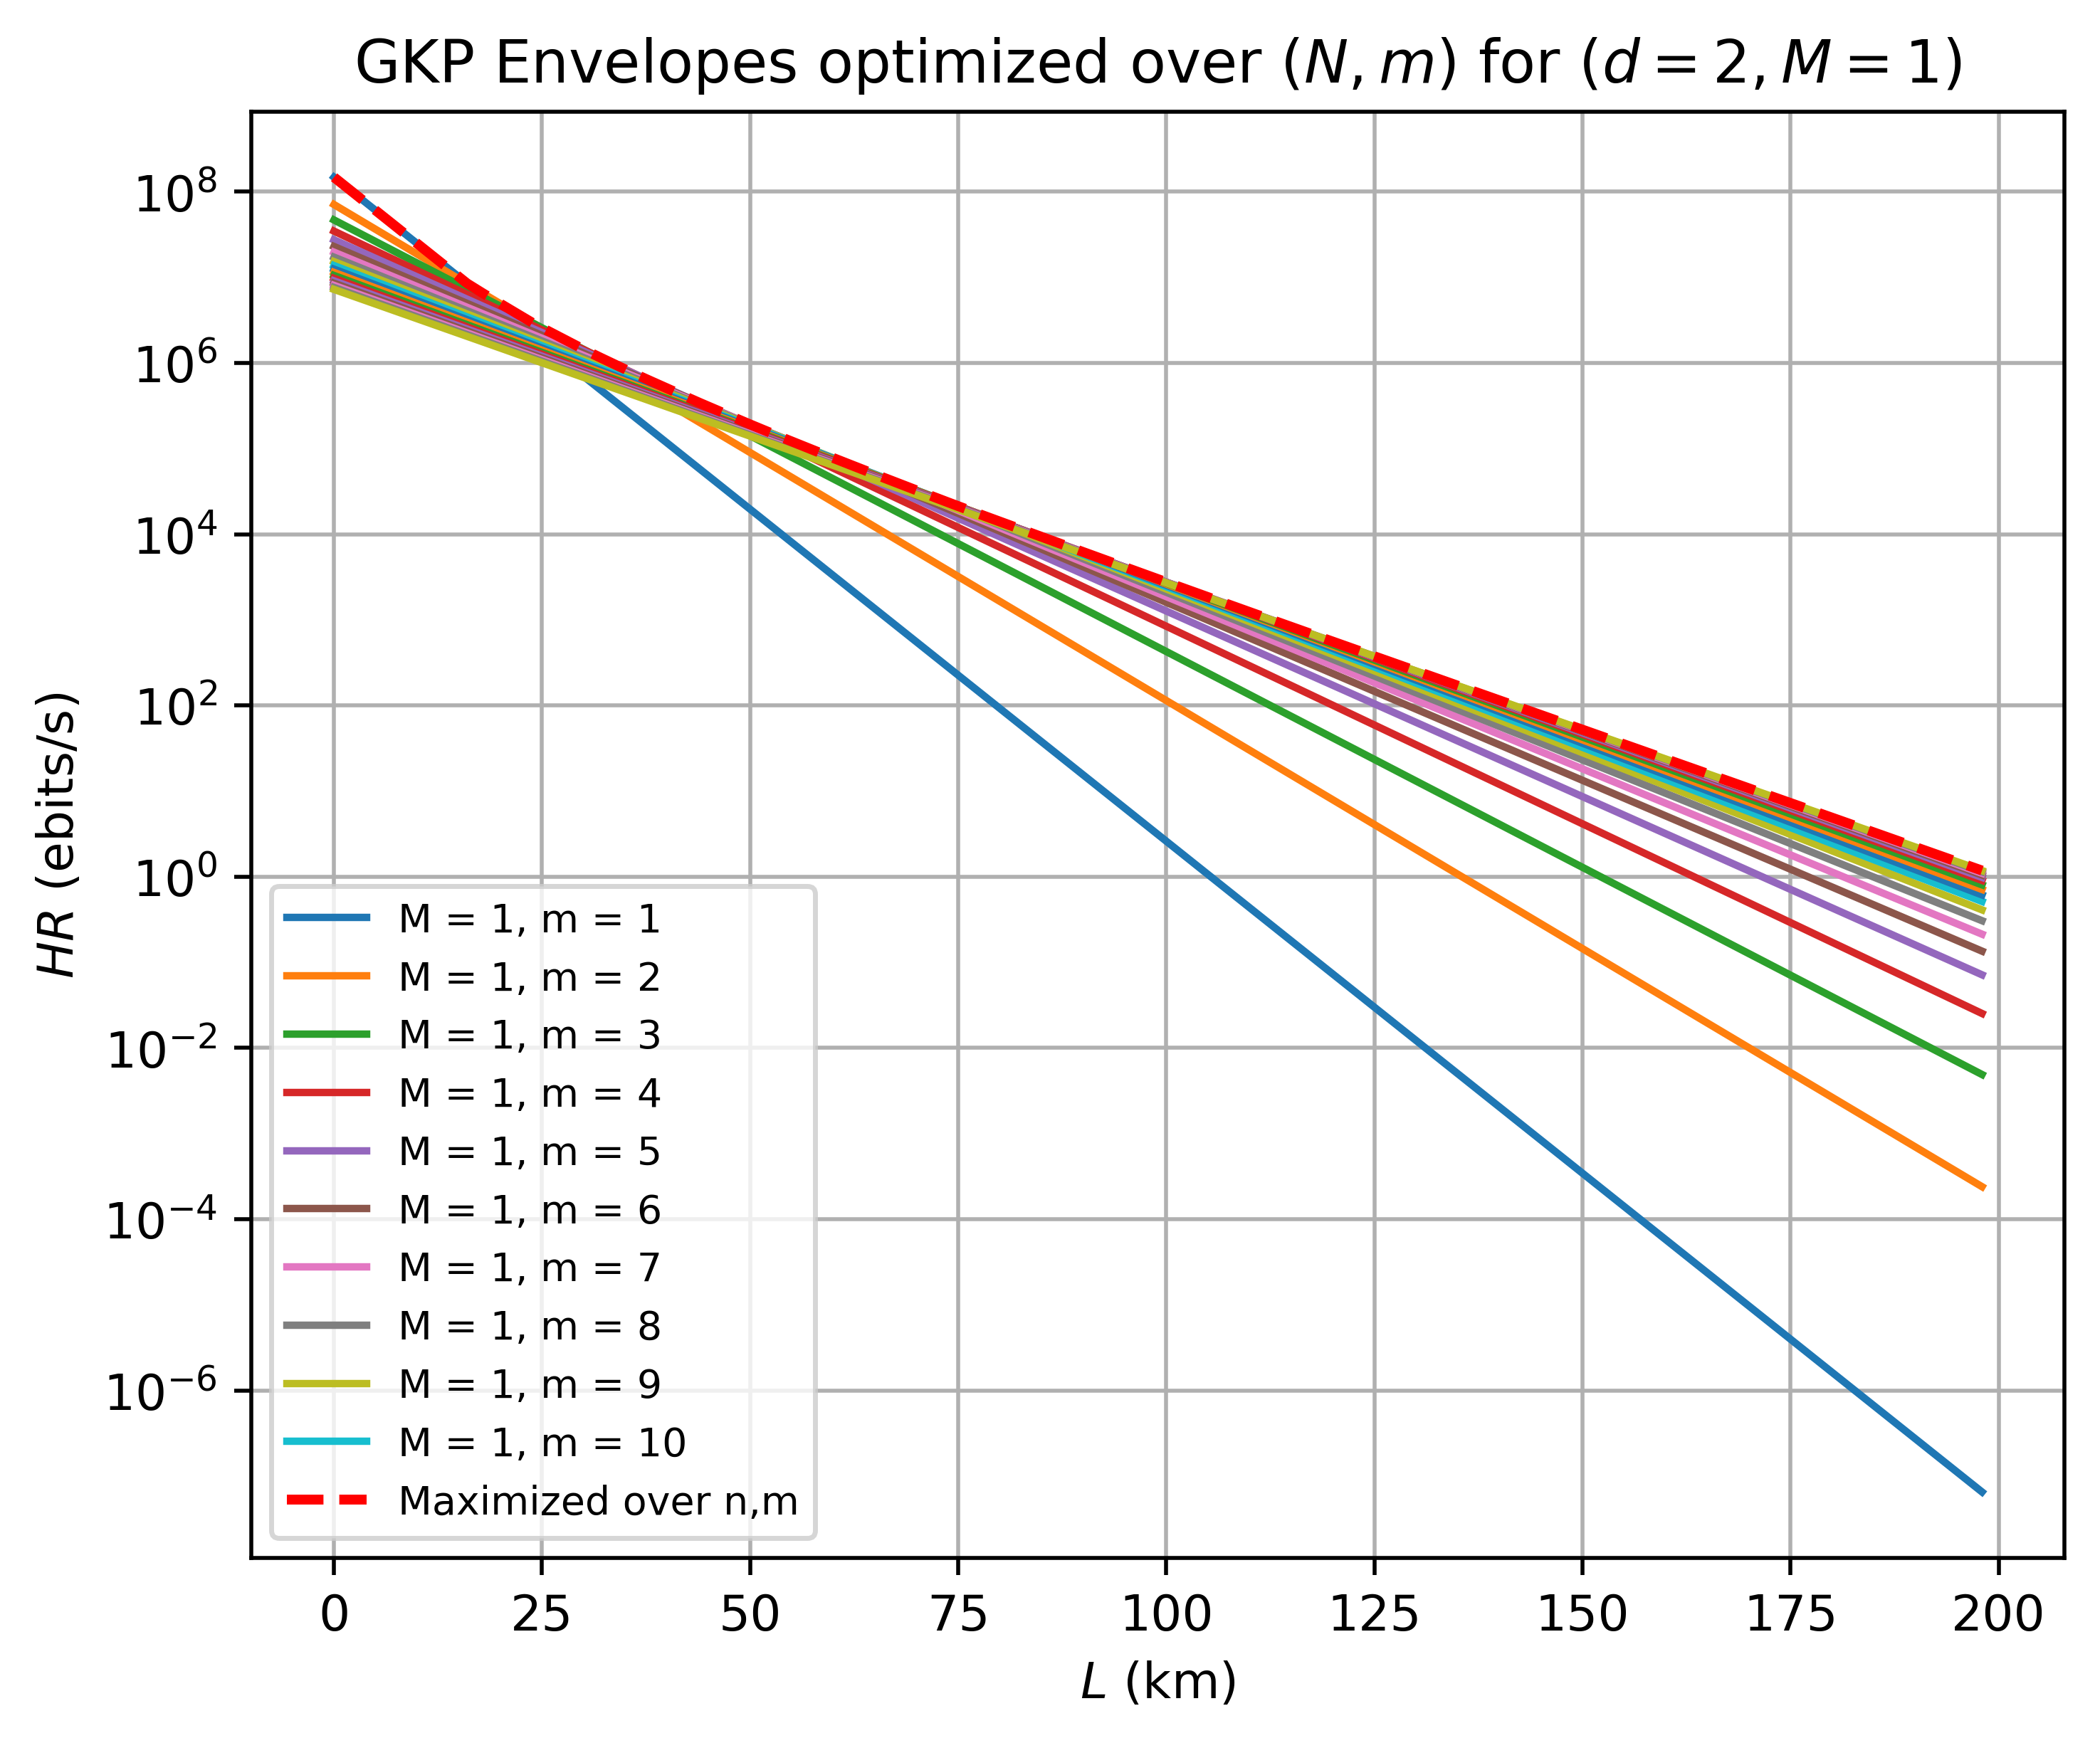

In [17]:
fig, ax = plt.subplots(figsize=(6,5), dpi=500)

ax.set_yscale("log")
ax.set_title("GKP Envelopes optimized over $(N,m)$ for $(d=2 , M = 1)$")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("$HR$ (ebits/s)")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, env in enumerate(envs):
    label = f"M = 1, m = {m_values[i]}" if i < 10 else None

    ax.plot(Ls,env,color=color_cycle(i % 10),linestyle="-",label=label)
ax.plot(Ls,fully_maximized_gkp_env,color="red",linestyle="--",linewidth=2,label="Maximized over n,m")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Locus for families A(m,n) and B(m,n)

Analytic forms of $R^{UB}$ and $R^{LB}$ cannot be derived for GKP qubit photon encoding.

So to derive the lines, we consider all the points A(m,n) and B(m,n), and fit a linear regression through each family, and similar to the temporal multiplexing envelope analysis, we perform a maximisation over the linear regression fits to obtain the numerical form of the lines $R^{UB}$ and $R^{LB}$.

We then seek to know the equations of these lines to determine if the GKP qubit photonic encoding has a subexponential scaling with distance.

In [39]:
def compute_A_locus_fit_with_points(m, sigma, Ls, M, q, tau, n_vals):
    A_Ls, A_Rs = [], []

    for n in n_vals:
        LA, RA = A_point_GKP_fixed_m(sigma, n, M, m, q, tau)
        A_Ls.append(LA)
        A_Rs.append(RA)

    A_Ls = np.array(A_Ls)
    A_Rs = np.array(A_Rs)

    A_valid = np.isfinite(A_Ls) & np.isfinite(A_Rs) & (A_Rs > 0)

    if np.sum(A_valid) < 2:
        return None, A_Ls, A_Rs

    A_slope, A_intercept, *_ = linregress(
        A_Ls[A_valid],
        np.log(A_Rs[A_valid])
    )

    A_fit = np.exp(A_intercept + A_slope * Ls)

    return A_fit, A_Ls, A_Rs

In [40]:
Ls = np.arange(0, 200, 2)

sigma = np.sqrt(0.01)
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 20)
n_vals = [1, 2, 4, 8, 16]

A_fit_list = []
A_points_list = []

for m in m_values:

    A_fit, A_Ls_m, A_Rs_m = compute_A_locus_fit_with_points(
        m, sigma, Ls, M, q, tau, n_vals
    )

    if A_fit is None:
        continue

    A_fit_list.append(A_fit)

    A_points_list.append({
        "m": m,
        "L": A_Ls_m,
        "R": A_Rs_m
    })

    print("Locus generated for m=",m)

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1392/3434440376.py:22: RuntimeWarning: overflow encountered in exp
  A_fit = np.exp(A_intercept + A_slope * Ls)


Locus generated for m= 1
Locus generated for m= 2
Locus generated for m= 3
Locus generated for m= 4
Locus generated for m= 5
Locus generated for m= 6
Locus generated for m= 7
Locus generated for m= 8
Locus generated for m= 9
Locus generated for m= 10
Locus generated for m= 11
Locus generated for m= 12
Locus generated for m= 13
Locus generated for m= 14
Locus generated for m= 15
Locus generated for m= 16
Locus generated for m= 17
Locus generated for m= 18
Locus generated for m= 19


# Generation of all LR fits for m=[1,19]

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1392/3434440376.py:22: RuntimeWarning: overflow encountered in exp
  A_fit = np.exp(A_intercept + A_slope * Ls)


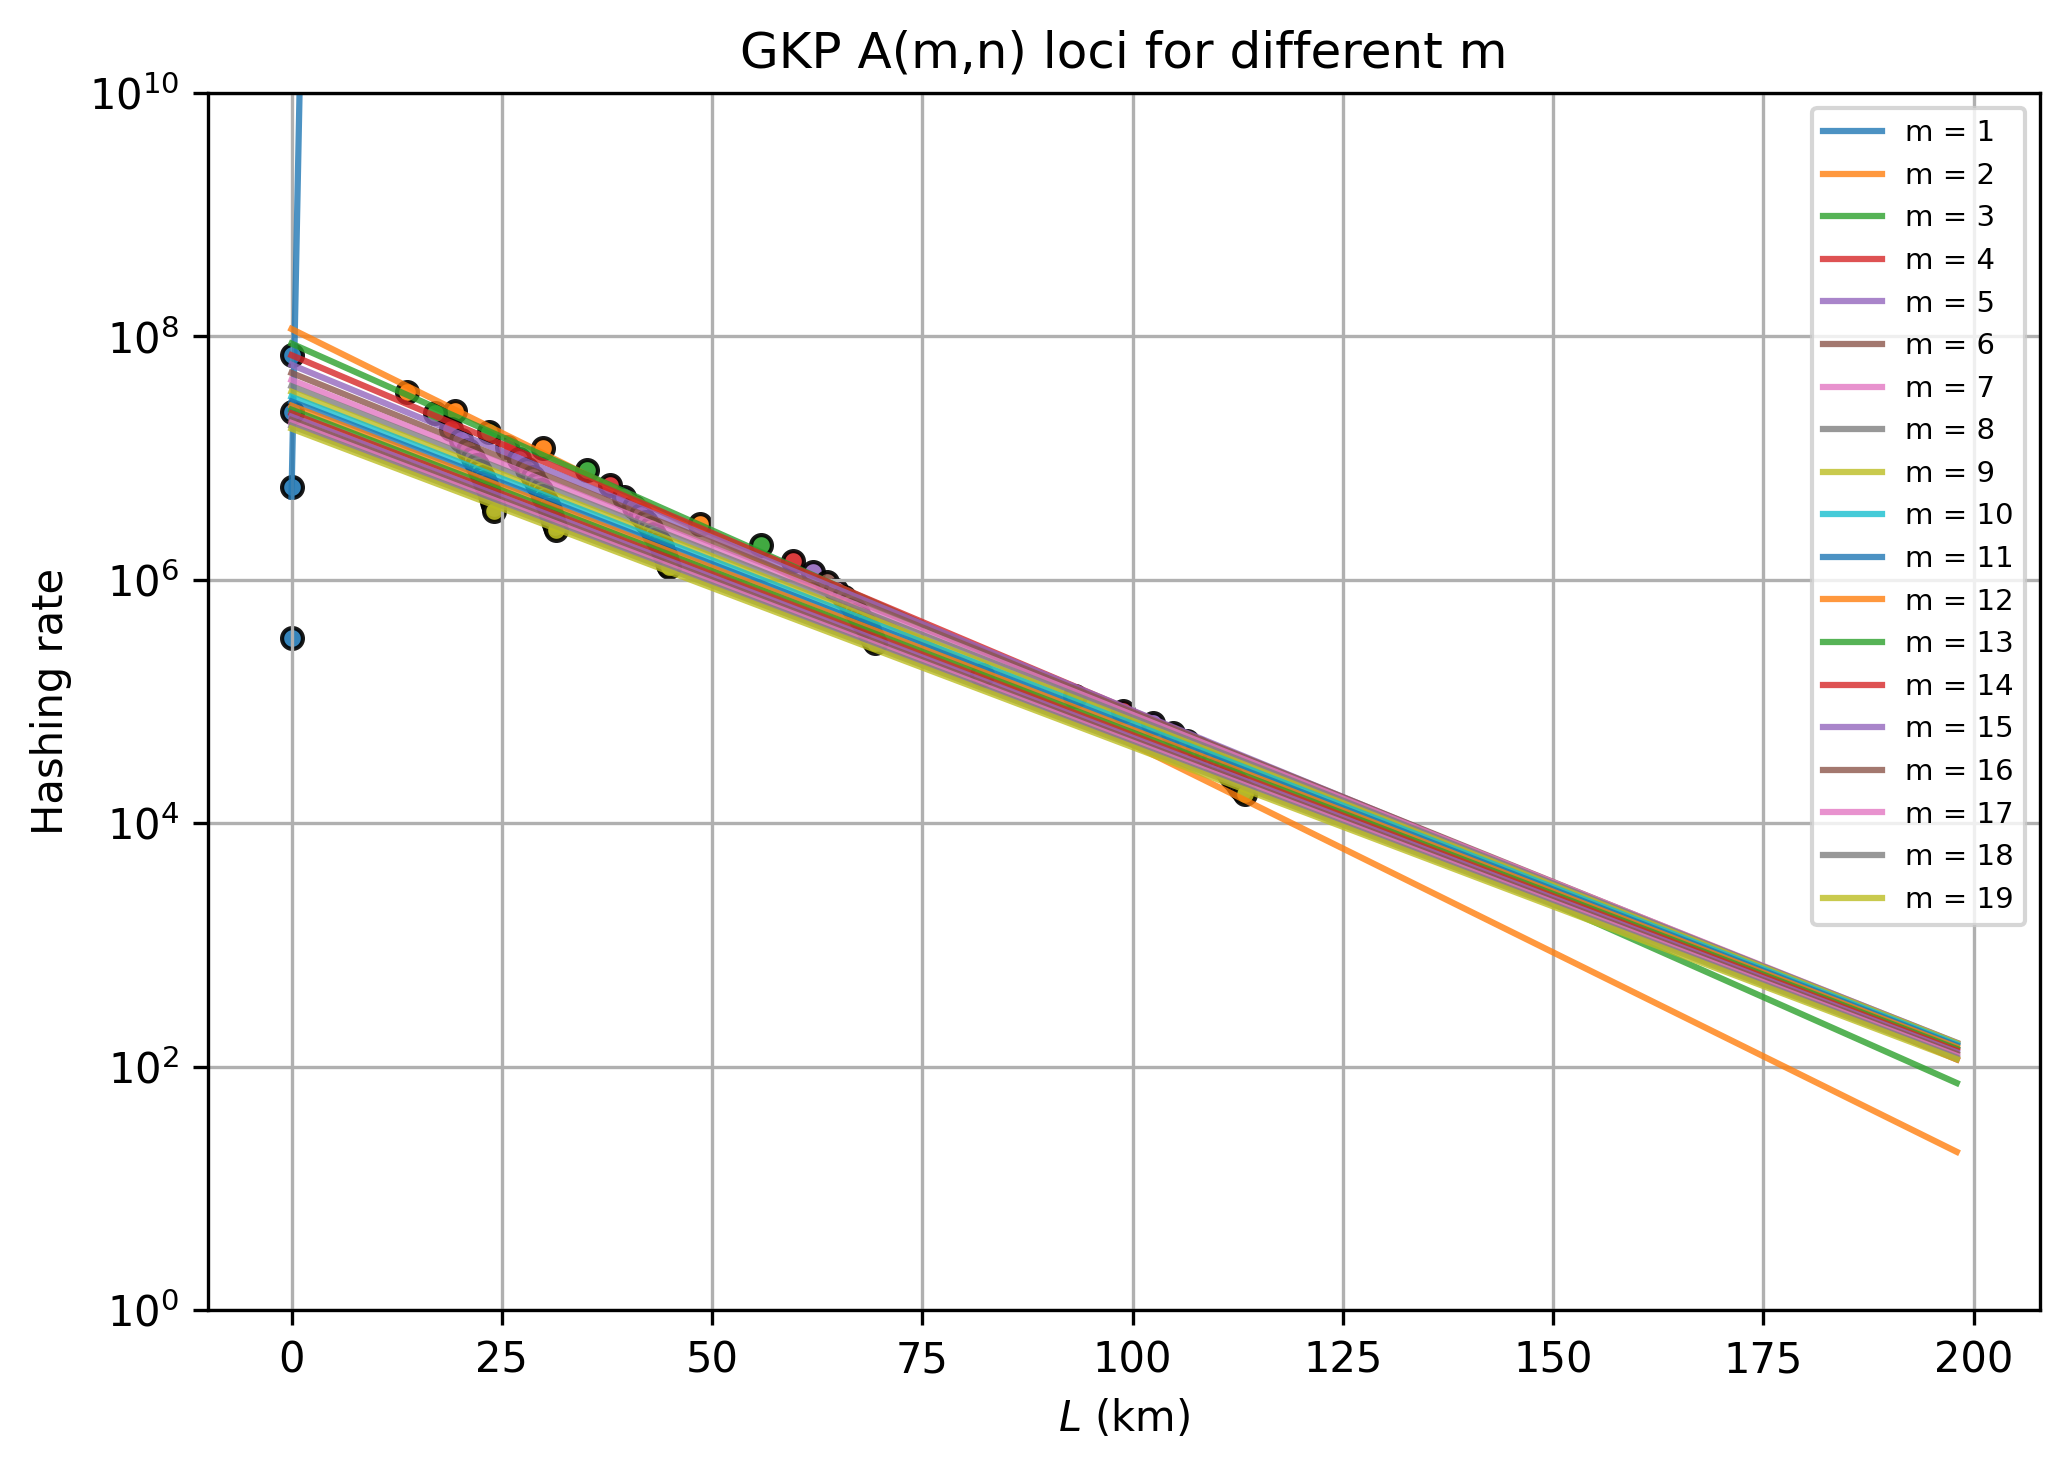

In [41]:
Ls = np.arange(0, 200, 2)

sigma = np.sqrt(0.01)
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 20)
n_vals = [1, 2, 4, 8, 16]

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("GKP A(m,n) loci for different m")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e10)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, m in enumerate(m_values):
    color = color_cycle(i % 10)

    A_fit, A_Ls_m, A_Rs_m = compute_A_locus_fit_with_points(
        m, sigma, Ls, M, q, tau, n_vals
    )

    if A_fit is None:
        continue

    label = f"m = {m}"

    ax.plot(
        Ls,
        A_fit,
        color=color,
        linestyle="-",
        linewidth=1.5,
        alpha=0.8,
        label=label
    )

    ax.scatter(
        A_Ls_m,
        A_Rs_m,
        color=color,
        edgecolor="black",
        s=25,
        alpha=0.9
    )

ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Zooming in on $m=1$

The above plot demonstrates that the LR fit for m=1 is problematic, the below script investigates this further

In [42]:
Ls = np.arange(0 , 200 , 2)

m_target = 1

sigma1 = np.sqrt(0.01)
rates1s1 = [optimal_hashing_rate(sigma1 , L , 1 , 1 , 0.7 , 1e-8 , m_target) for L in Ls]
rates2s1 = [optimal_hashing_rate(sigma1 , L , 2 , 1 , 0.7 , 1e-8 , m_target) for L in Ls]
rates4s1 = [optimal_hashing_rate(sigma1 , L , 4 , 1 , 0.7 , 1e-8 , m_target) for L in Ls]
rates8s1 = [optimal_hashing_rate(sigma1 , L , 8 , 1 , 0.7 , 1e-8 , m_target) for L in Ls]
rates16s1 = [optimal_hashing_rate(sigma1 , L , 16 , 1 , 0.7 , 1e-8 , m_target) for L in Ls]

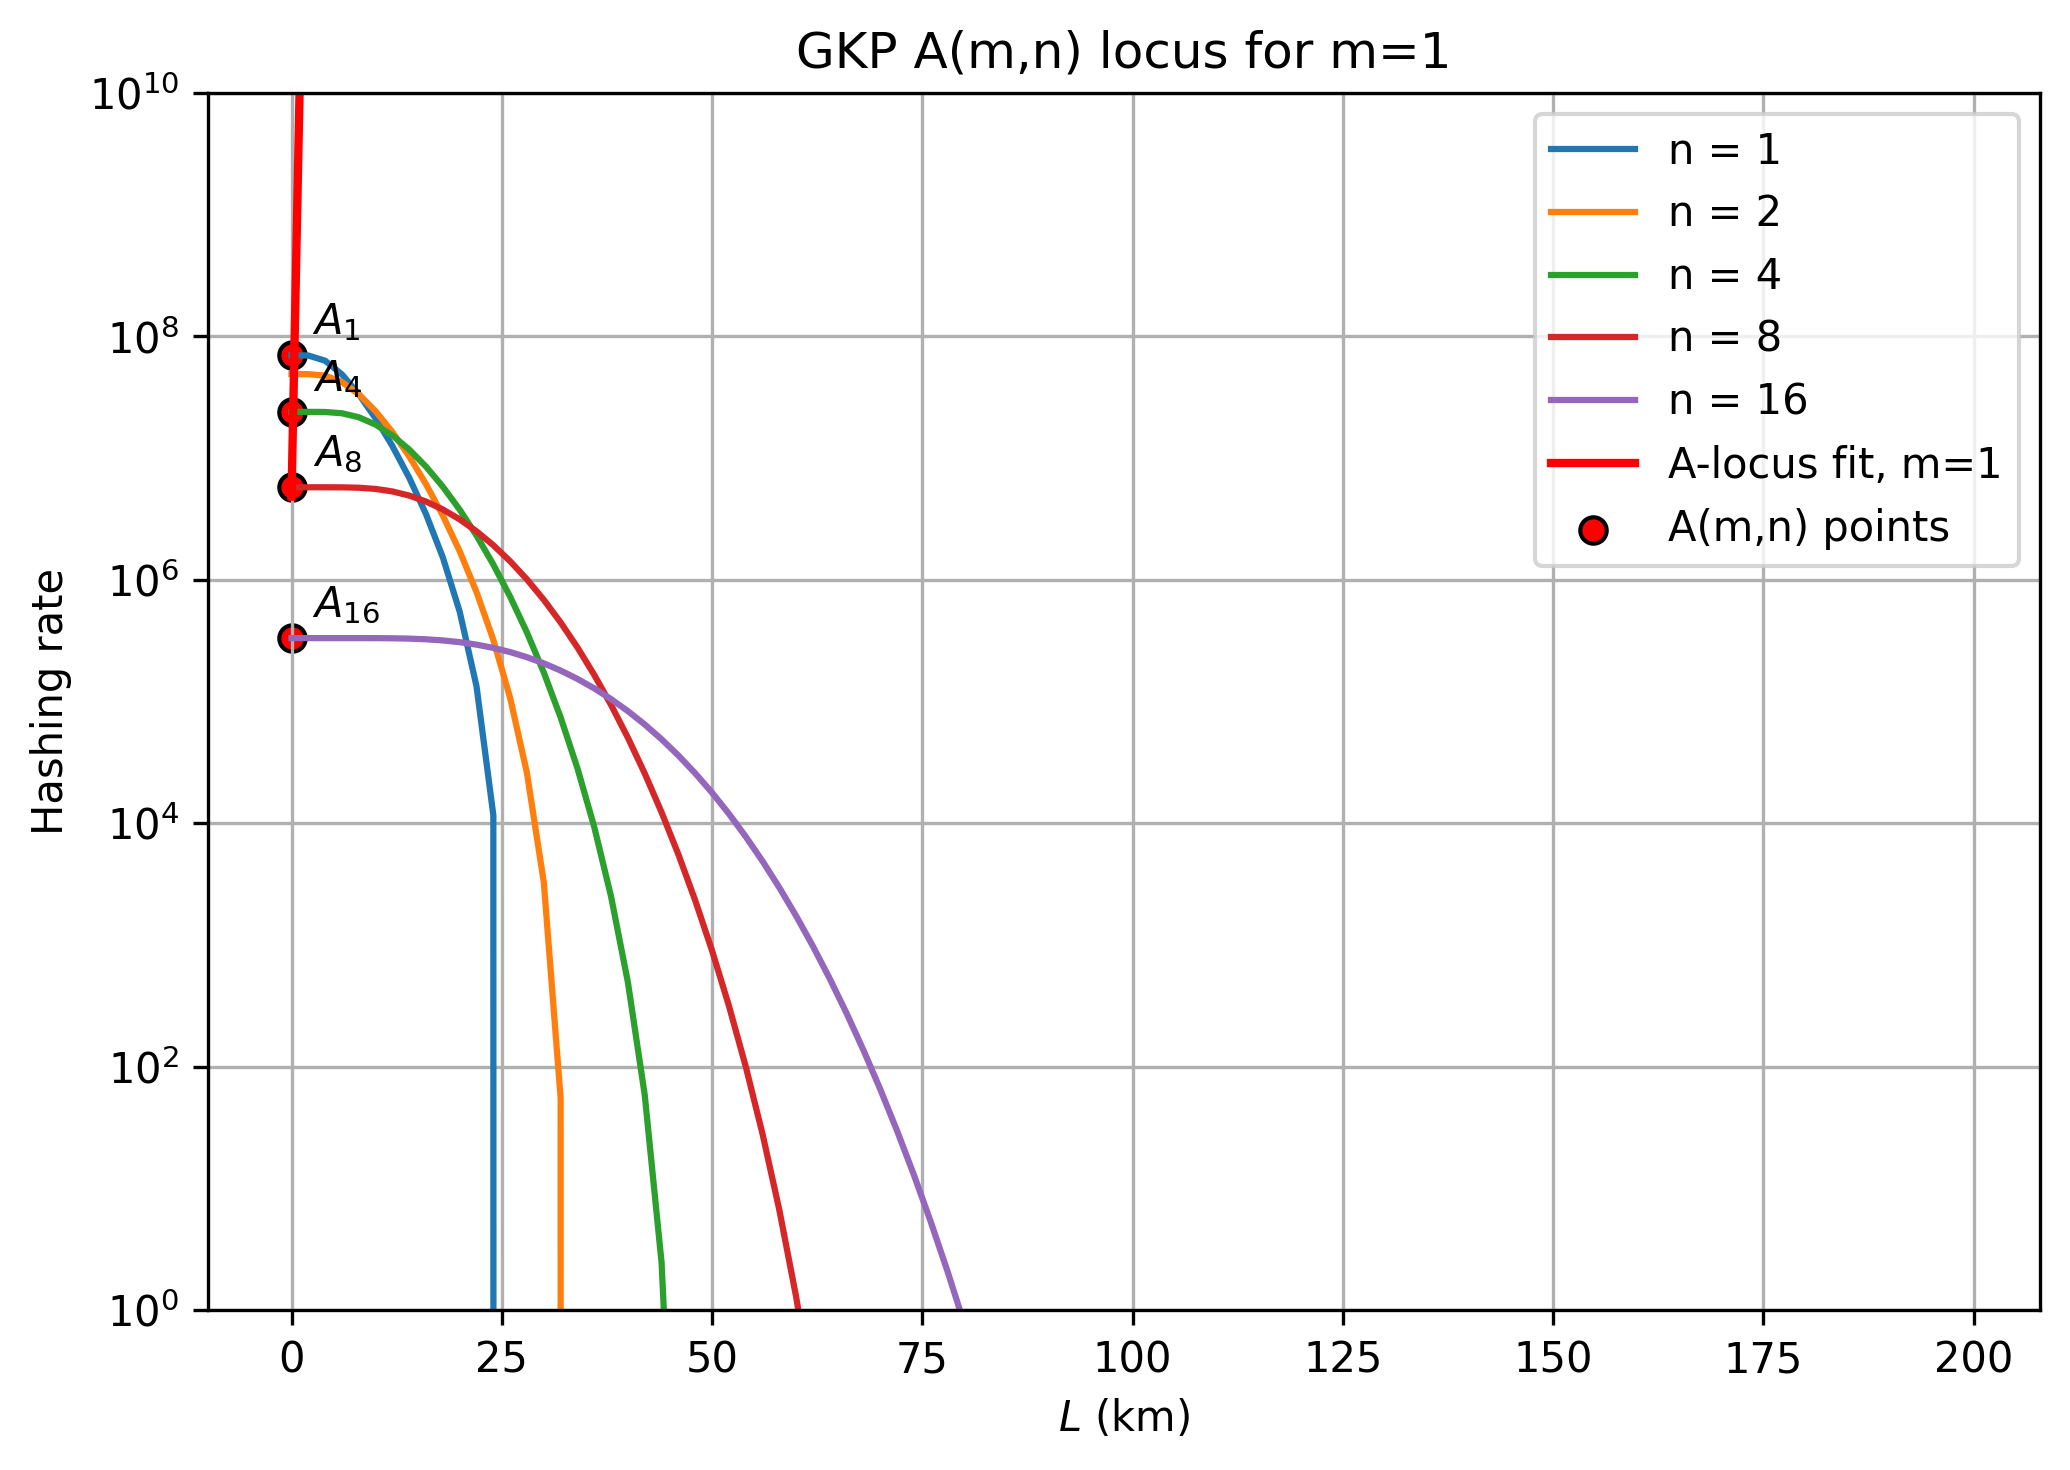

In [43]:
# find where m=5 is stored
idx = next(
    i for i, d in enumerate(A_points_list)
    if d["m"] == m_target
)

gkp_list = [rates1s1 , rates2s1 , rates4s1 , rates8s1 , rates16s1]
color_cycle = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(7,5), dpi=300)

ax.set_yscale("log")
ax.set_title(f"GKP A(m,n) locus for m={m_target}")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e0, top=1e10)
ax.grid(True)

for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(Ls, rate_curve, label=f"n = {n}", color=color)

ax.plot(
    Ls,
    A_fit_list[idx],
    color="red",
    linewidth=2,
    label=f"A-locus fit, m={m_target}"
)

ax.scatter(
    A_points_list[idx]["L"],
    A_points_list[idx]["R"],
    color="red",
    edgecolor="black",
    s=40,
    label="A(m,n) points"
)

for n, LA, RA in zip(
    n_vals,
    A_points_list[idx]["L"],
    A_points_list[idx]["R"]
):
    ax.annotate(
        rf"$A_{{{n}}}$",
        (LA, RA),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=10
    )

ax.legend()
plt.tight_layout()
plt.show()

Numerically, the points of intersection are found when the lines Rexp = Rmax, for the scenario $M=m=1$ we find that

Rexp $= \frac{q^{n}}{m\tau} (MmP_{succ})^{-(n+1)} = \frac{q^{n}}{\tau} P_{succ}^{n+1}$ 

Rmax $=\frac{q^{n}}{m\tau} = \frac{q^{n}}{\tau}$

Thus

$\frac{q^{n}}{\tau} P_{succ}^{n+1} = \frac{q^{n}}{\tau}$

$\implies P_{succ}^{n+1} = 1$

$\implies P_{succ} = 1$

Therefore, the family A(m,n) only exist at $L=0$ km and so we discard this specific family from the analysis

# Derivation of $R^{UB}$

# Removing $m=1$ from the family and performing maximisation over LR fits

In [44]:
# --------------------------------------------------
# Build matrix of A-locus LR fits, excluding m = 1
# --------------------------------------------------

A_fit_filtered = []
A_m_filtered = []

for A_fit, info in zip(A_fit_list, A_points_list):
    if info["m"] == 1:
        continue

    A_fit_filtered.append(A_fit)
    A_m_filtered.append(info["m"])

A_fit_matrix = np.array(A_fit_filtered)

fully_maximized_A_locus = np.max(A_fit_matrix, axis=0)

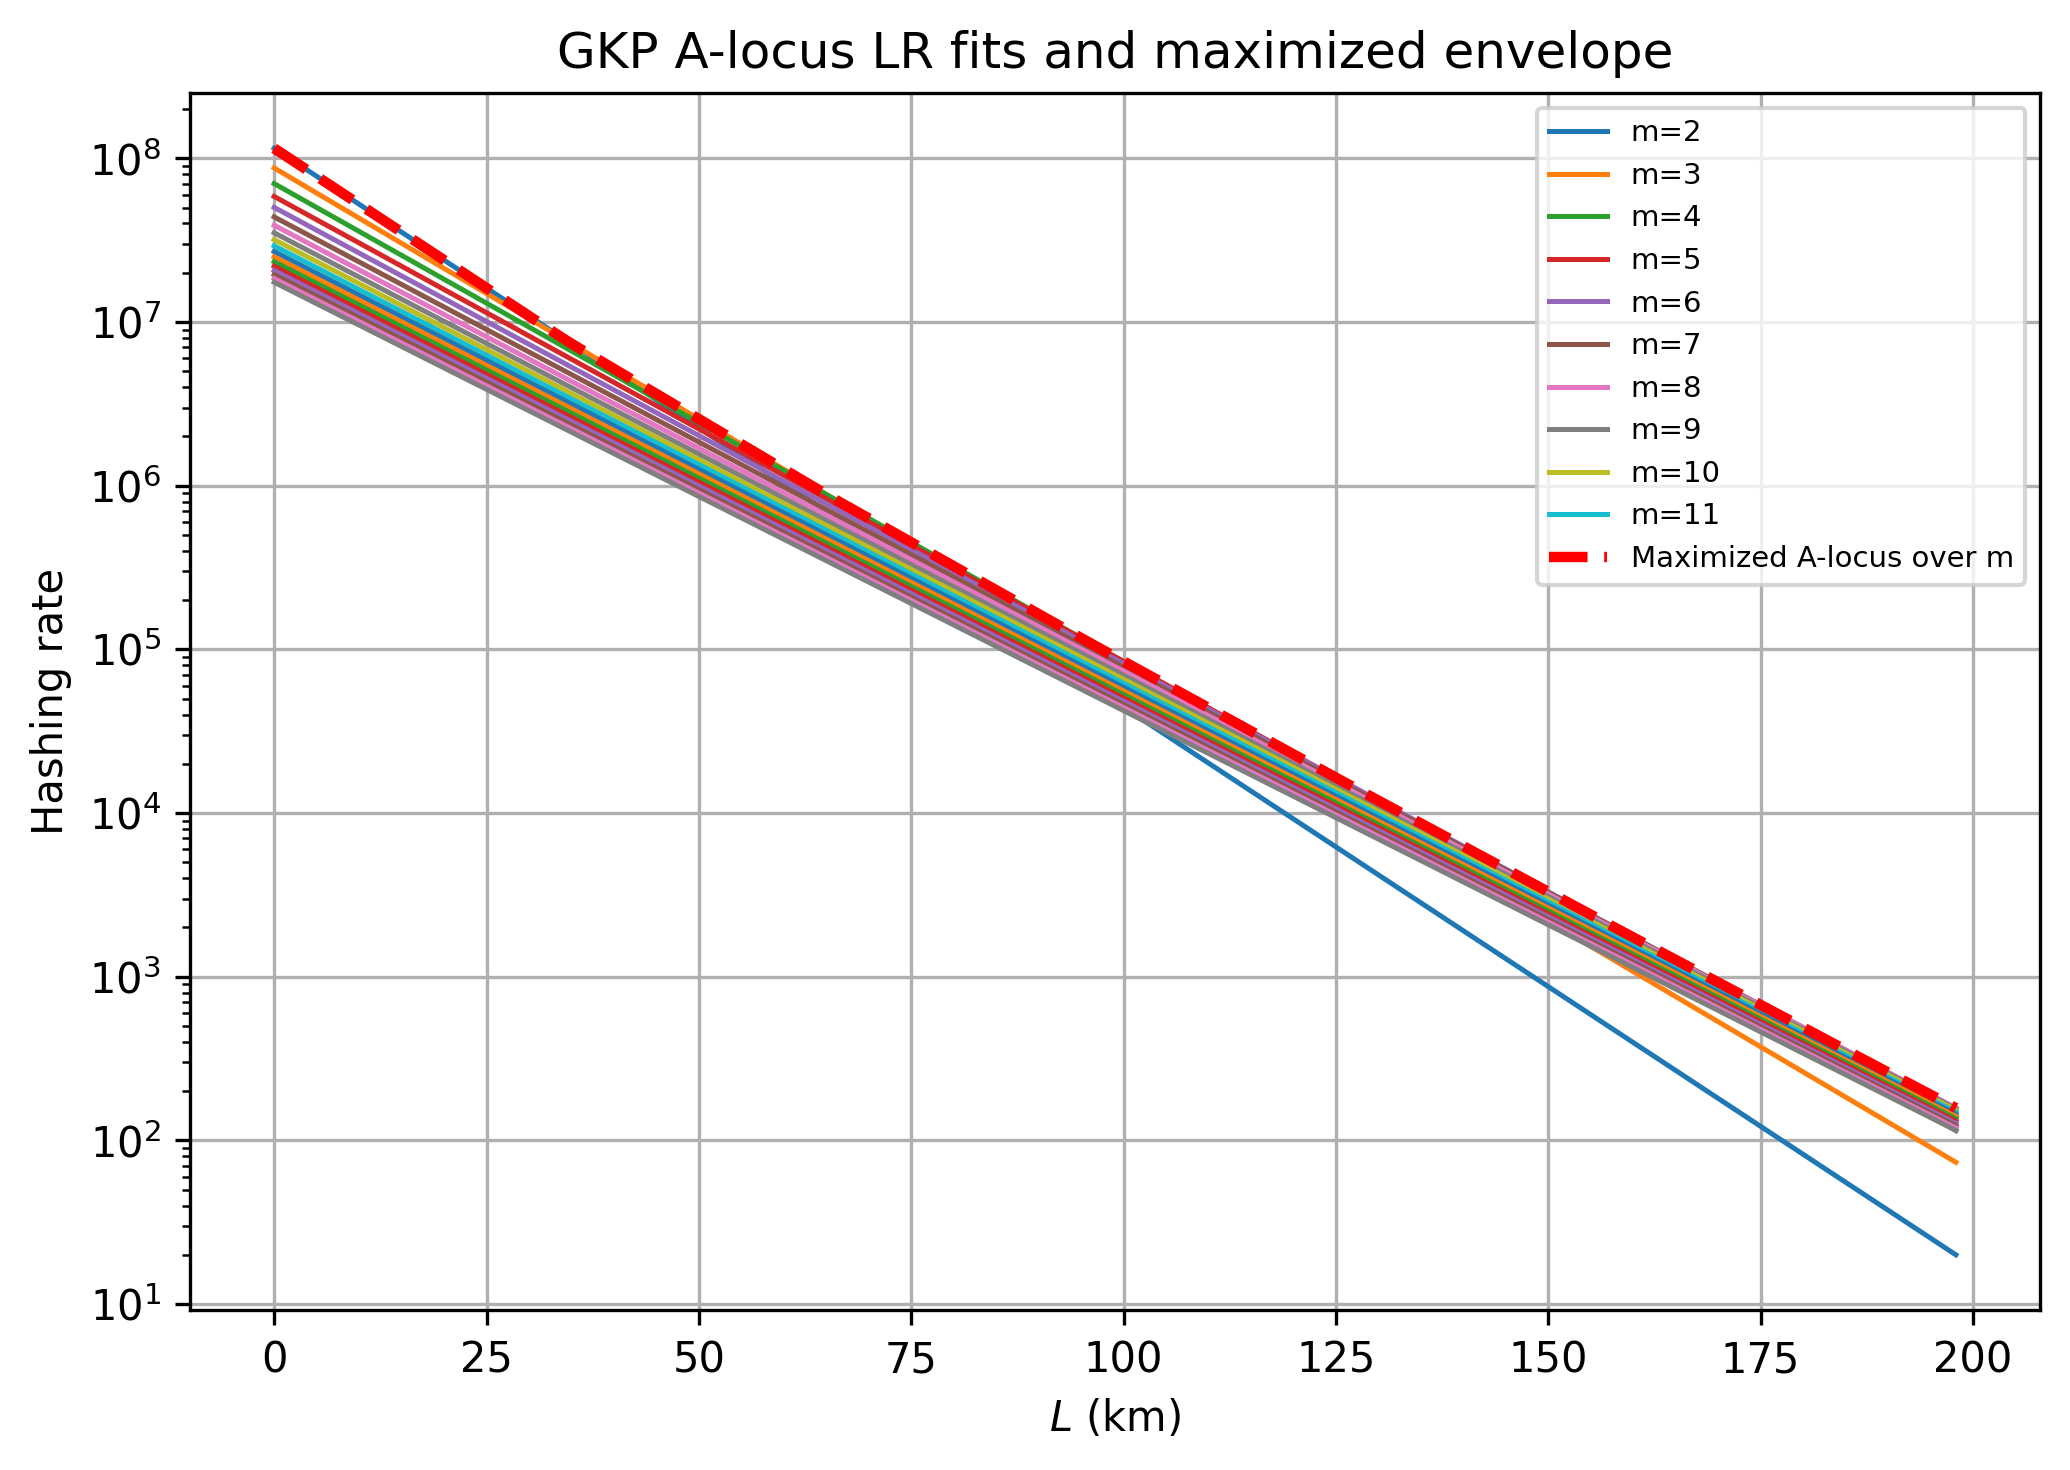

In [45]:
# --------------------------------------------------
# Plot all LR fits and their maximized envelope
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("GKP A-locus LR fits and maximized envelope")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, A_fit in enumerate(A_fit_filtered):
    ax.plot(
        Ls,
        A_fit,
        color=color_cycle(i % 10),
        linewidth=1.2,
        label=f"m={A_m_filtered[i]}" if i < 10 else None
    )

ax.plot(
    Ls,
    fully_maximized_A_locus,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label="Maximized A-locus over m"
)

ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Numerical form of $R^{UB}$

In [46]:
# --------------------------------------------------
# Fit log R(L) = a - b L^k
# --------------------------------------------------

R_target = fully_maximized_A_locus

valid = np.isfinite(R_target) & (R_target > 0) & np.isfinite(Ls)

# avoid L=0 because L^k can create numerical issues for small k
valid = valid & (Ls > 0)

L_fit = Ls[valid]
logR_fit = np.log(R_target[valid])


k_values = np.linspace(0.05, 1.50, 500)

best_R2 = -np.inf
best_k = None
best_slope = None
best_intercept = None

fit_results = []

for k in k_values:
    X = L_fit**k

    slope, intercept, r_value, p_value, std_err = linregress(X, logR_fit)

    R2 = r_value**2

    fit_results.append((k, R2, slope, intercept))

    if R2 > best_R2:
        best_R2 = R2
        best_k = k
        best_slope = slope
        best_intercept = intercept


a = best_intercept
b = -best_slope

print("Best scaling fit:")
print(f"k = {best_k:.6f}")
print(f"R^2 = {best_R2:.12f}")
print()
print("log R(L) = a - b L^k")
print(f"a = {a:.6e}")
print(f"b = {b:.6e}")
print(f"k = {best_k:.6e}")
print()
print(f"R(L) = exp({a:.6e}) * exp(-({b:.6e}) * L^{best_k:.6e})")

Best scaling fit:
k = 0.907214
R^2 = 0.999990517172

log R(L) = a - b L^k
a = 1.865831e+01
b = 1.121001e-01
k = 9.072144e-01

R(L) = exp(1.865831e+01) * exp(-(1.121001e-01) * L^9.072144e-01)


# Plot of maximised LR fit and numerically derived line $R^{UB}$

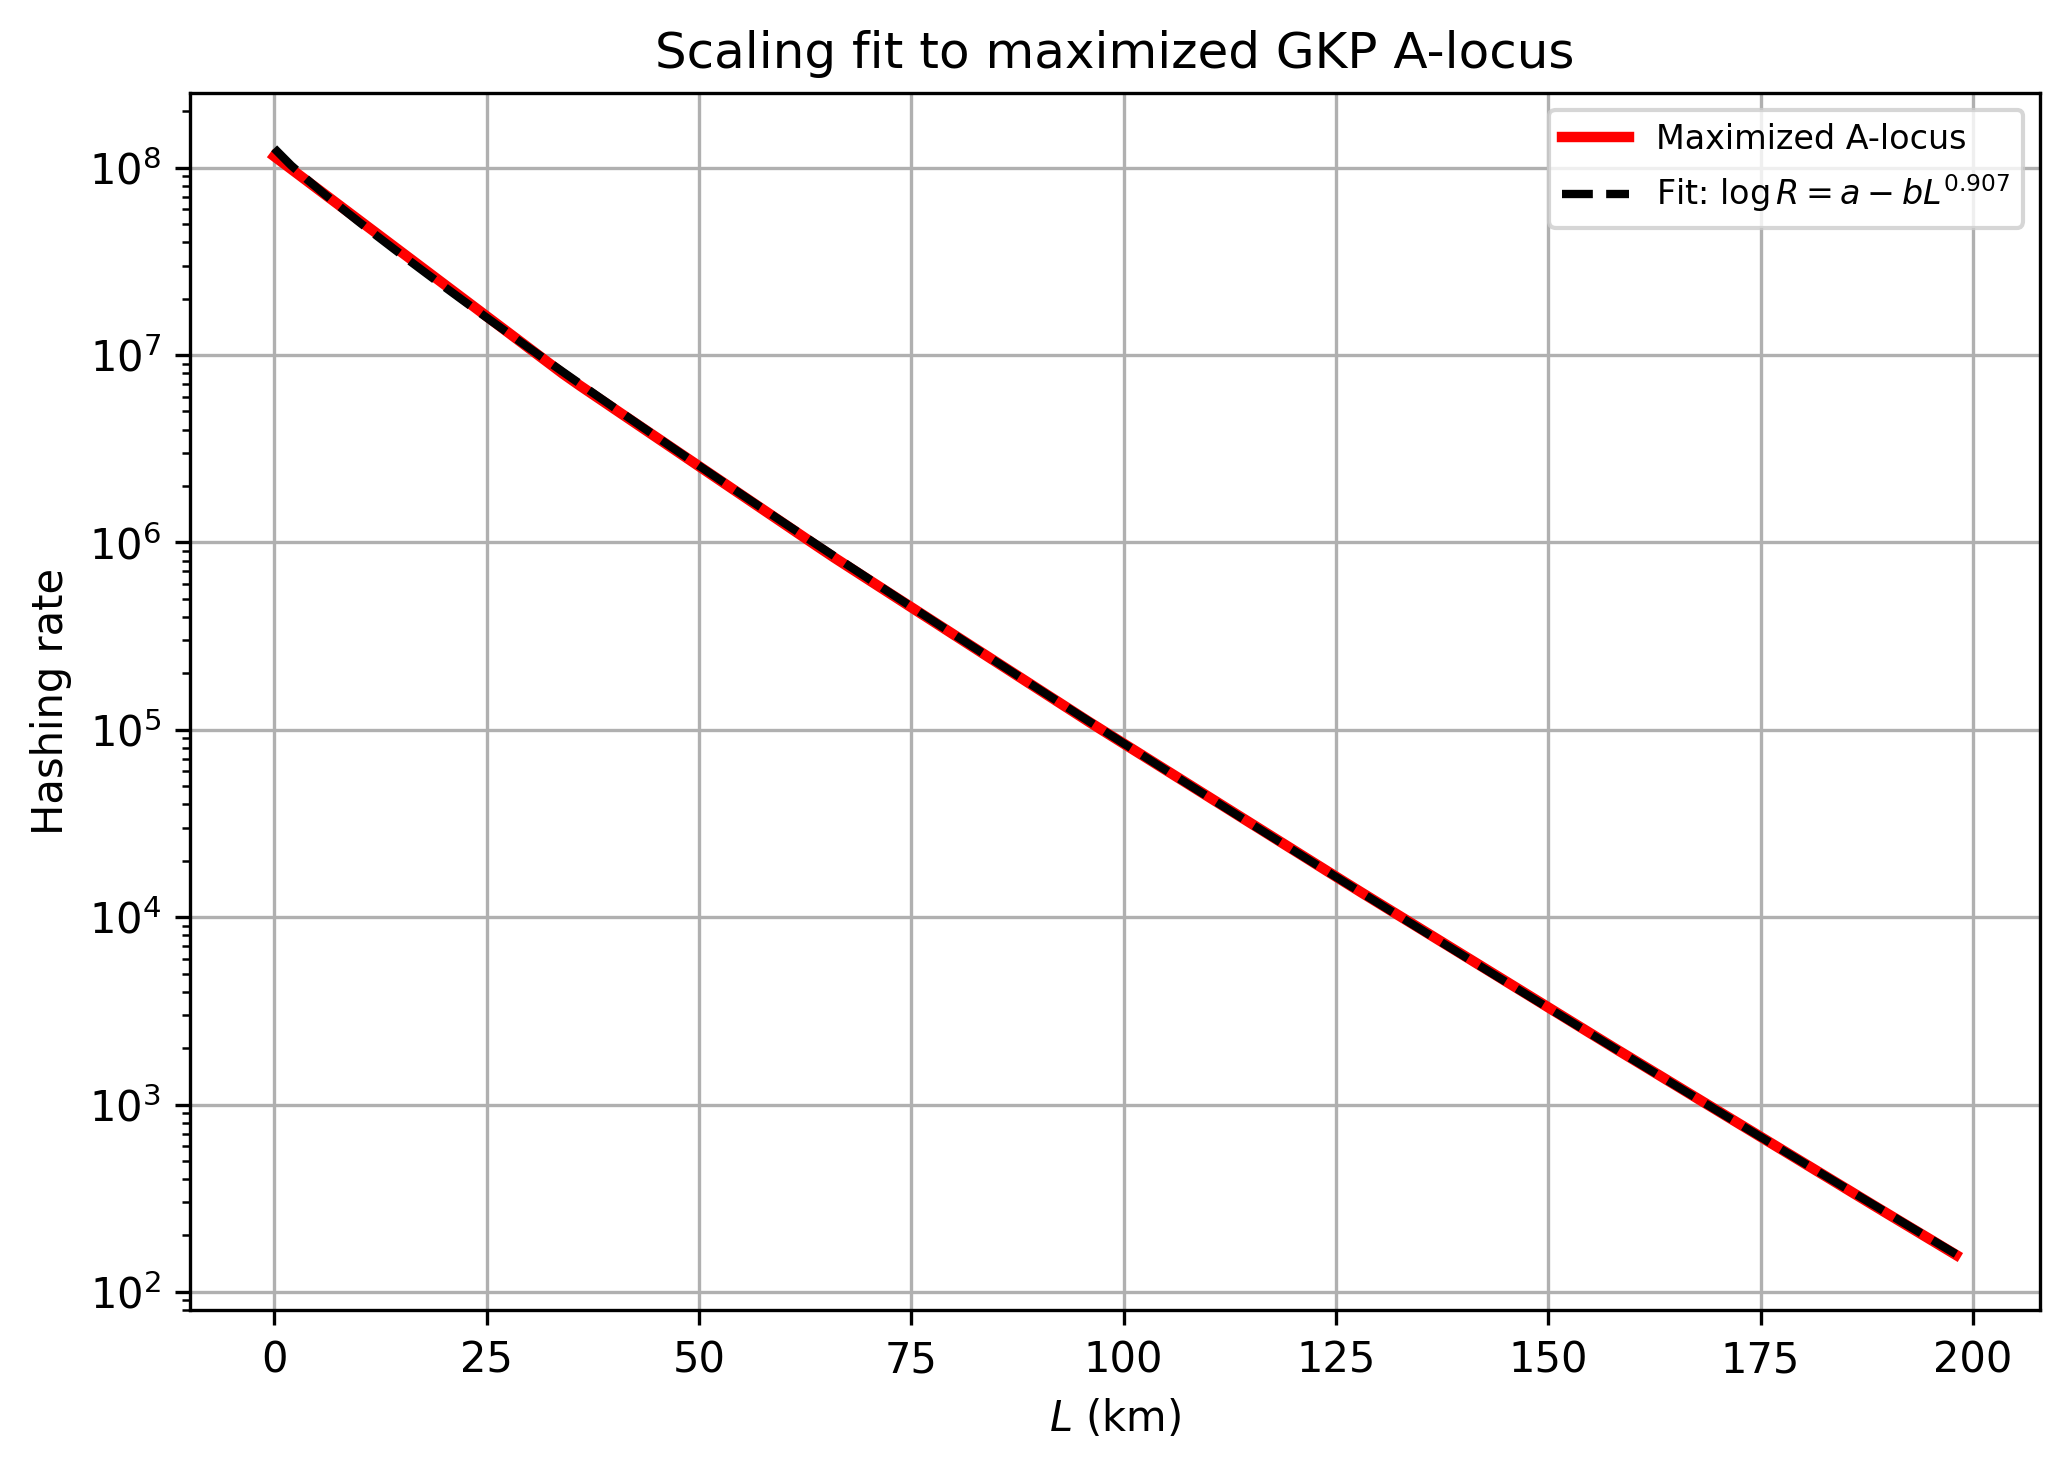

In [47]:
R_scaling_fit = np.exp(a - b * Ls**best_k)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("Scaling fit to maximized GKP A-locus")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

ax.plot(
    Ls,
    fully_maximized_A_locus,
    color="red",
    linewidth=2.5,
    label="Maximized A-locus"
)

ax.plot(
    Ls,
    R_scaling_fit,
    color="black",
    linestyle="--",
    linewidth=2,
    label=rf"Fit: $\log R = a - bL^{{{best_k:.3f}}}$"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Repeating the analysis for the family B(m,n)

In [48]:
# --------------------------------------------------
# B(m,n) locus fit with raw points
# --------------------------------------------------

def compute_B_locus_fit_with_points(m, sigma, Ls, M, q, tau, n_vals):
    B_Ls, B_Rs = [], []

    for n in n_vals:
        LB, RB = B_point_GKP_fixed_m(sigma, n, M, m, q, tau)

        B_Ls.append(LB)
        B_Rs.append(RB)

    B_Ls = np.array(B_Ls)
    B_Rs = np.array(B_Rs)

    B_valid = np.isfinite(B_Ls) & np.isfinite(B_Rs) & (B_Rs > 0)

    if np.sum(B_valid) < 2:
        return None, B_Ls, B_Rs

    B_slope, B_intercept, *_ = linregress(
        B_Ls[B_valid],
        np.log(B_Rs[B_valid])
    )

    B_fit = np.exp(B_intercept + B_slope * Ls)

    return B_fit, B_Ls, B_Rs

In [49]:
# --------------------------------------------------
# Generate B-locus fits over m
# --------------------------------------------------

Ls = np.arange(0, 200, 2)

sigma = np.sqrt(0.01)
M = 1
q = 0.7
tau = 1e-8

m_values = np.arange(1, 20)
n_vals = [1, 2, 4, 8, 16]

B_fit_list = []
B_points_list = []

for m in m_values:
    B_fit, B_Ls_m, B_Rs_m = compute_B_locus_fit_with_points(
        m, sigma, Ls, M, q, tau, n_vals
    )

    if B_fit is None:
        continue

    B_fit_list.append(B_fit)

    B_points_list.append({
        "m": m,
        "L": B_Ls_m,
        "R": B_Rs_m
    })

    print("B-locus generated for m =", m)

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1392/2278654689.py:27: RuntimeWarning: overflow encountered in exp
  B_fit = np.exp(B_intercept + B_slope * Ls)


B-locus generated for m = 1
B-locus generated for m = 2
B-locus generated for m = 3
B-locus generated for m = 4
B-locus generated for m = 5
B-locus generated for m = 6
B-locus generated for m = 7
B-locus generated for m = 8
B-locus generated for m = 9
B-locus generated for m = 10
B-locus generated for m = 11
B-locus generated for m = 12
B-locus generated for m = 13
B-locus generated for m = 14
B-locus generated for m = 15
B-locus generated for m = 16
B-locus generated for m = 17
B-locus generated for m = 18
B-locus generated for m = 19


# Excluding the family B(m=1,n)

In [50]:
# --------------------------------------------------
# Exclude m = 1 and maximize over B-locus LR fits
# --------------------------------------------------

B_fit_filtered = []
B_m_filtered = []

for B_fit, info in zip(B_fit_list, B_points_list):
    if info["m"] == 1:
        continue

    B_fit_filtered.append(B_fit)
    B_m_filtered.append(info["m"])

B_fit_matrix = np.array(B_fit_filtered)

fully_maximized_B_locus = np.max(B_fit_matrix, axis=0)

# Plot of B(m,n) locus

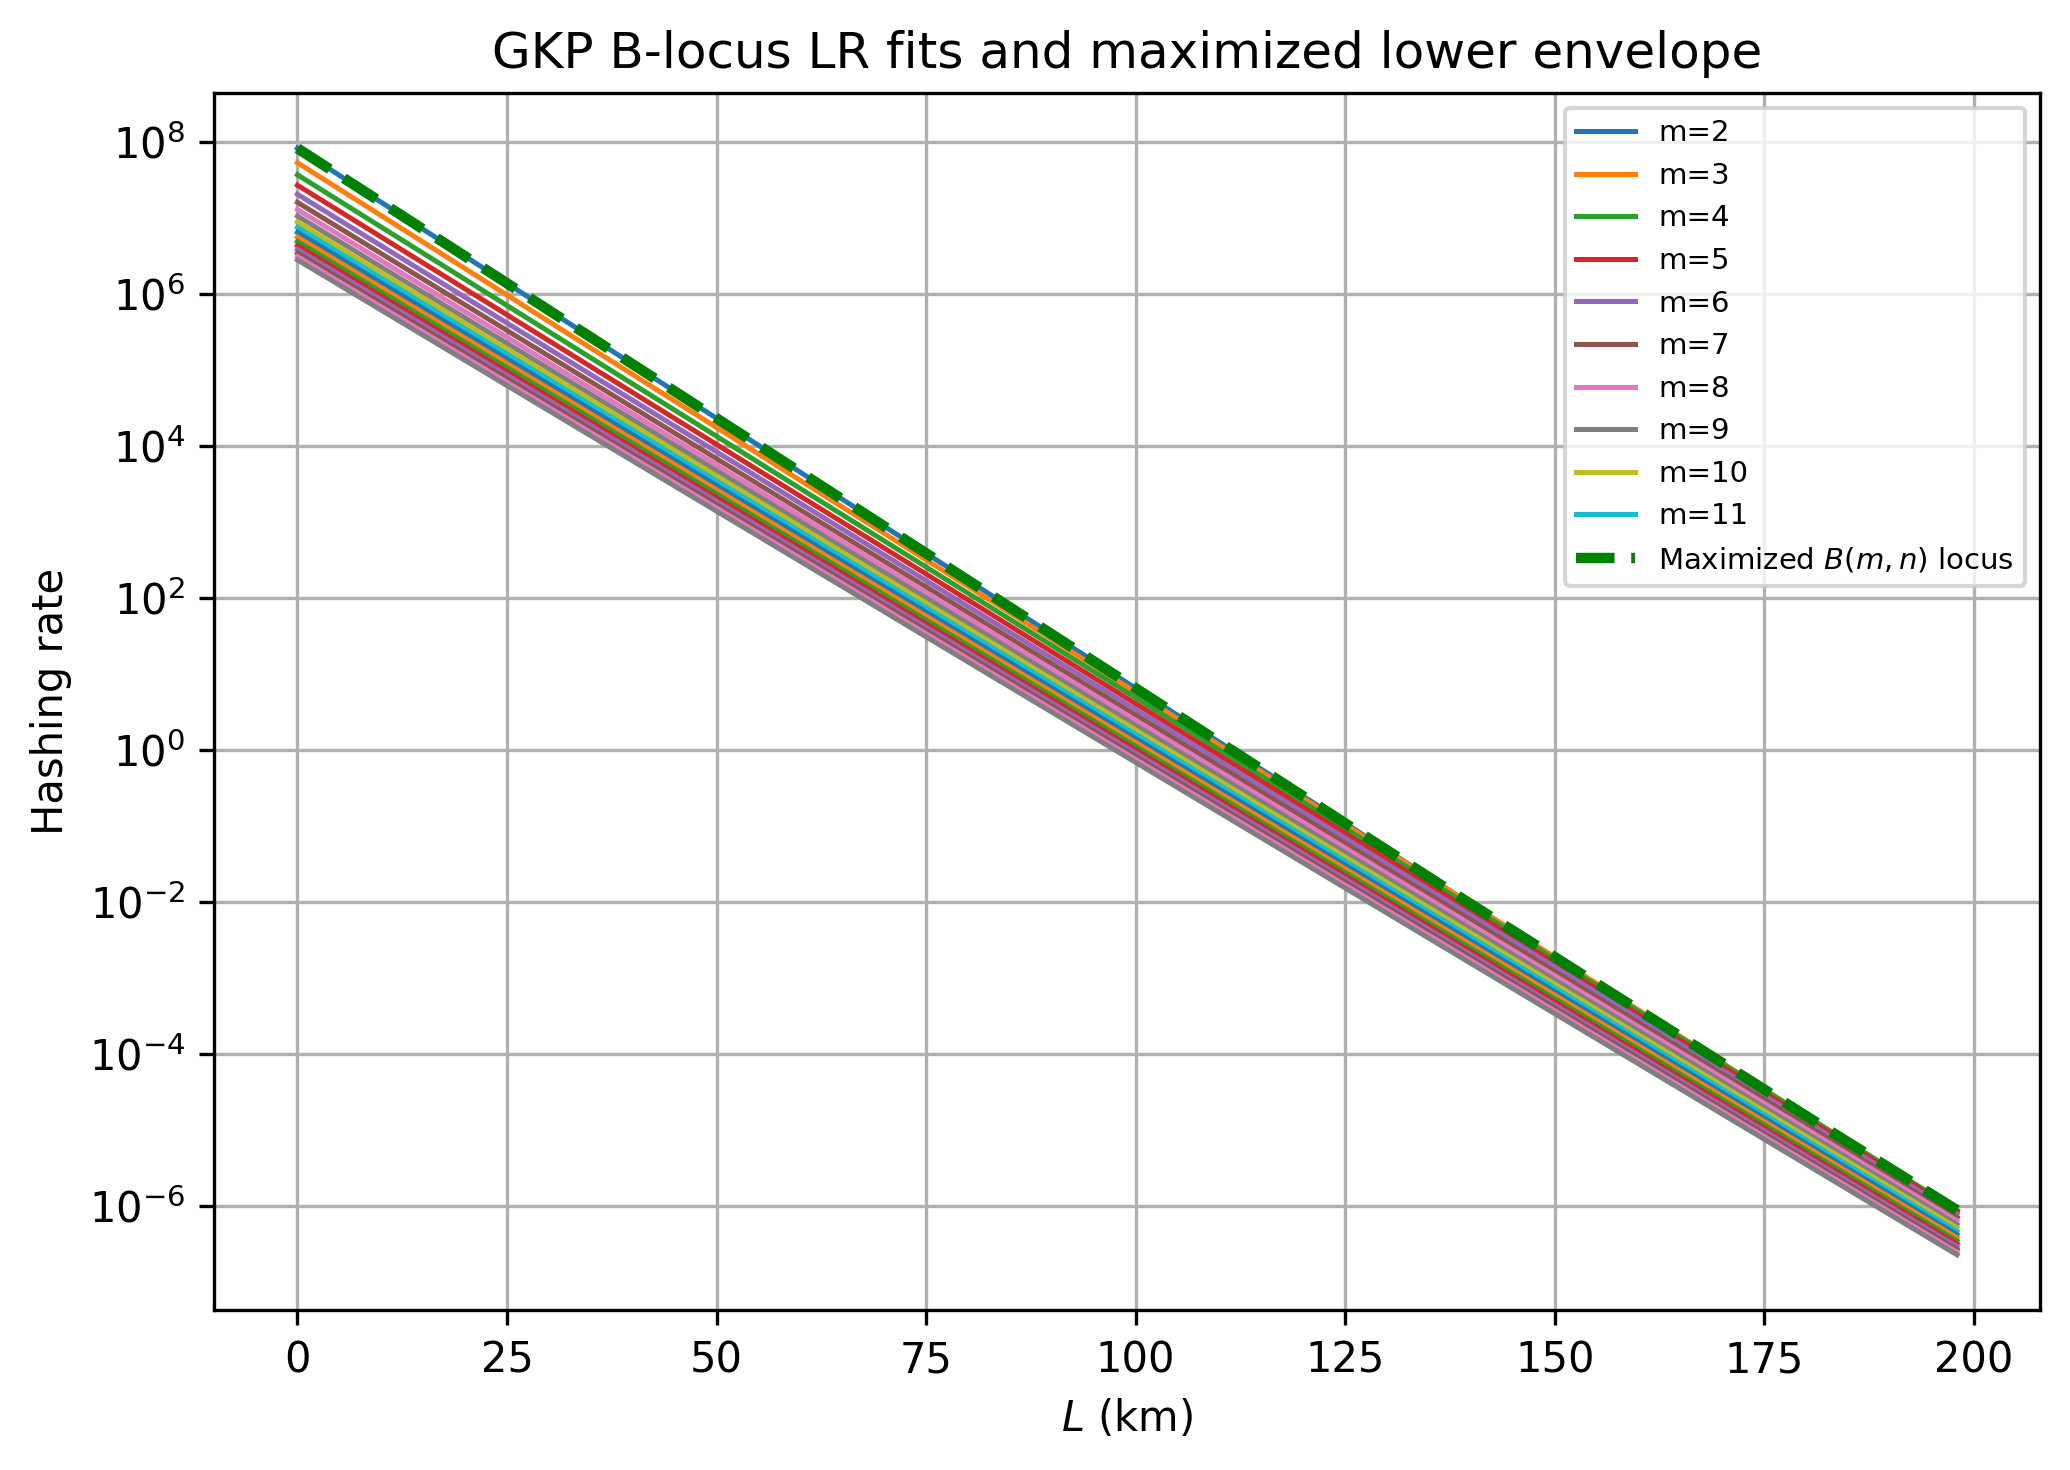

In [51]:
# --------------------------------------------------
# Plot all B-locus fits and maximized B-locus
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("GKP B-locus LR fits and maximized lower envelope")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

for i, B_fit in enumerate(B_fit_filtered):
    ax.plot(Ls,B_fit,color=color_cycle(i % 10),linewidth=1.2,label=f"m={B_m_filtered[i]}" if i < 10 else None)

ax.plot(Ls,fully_maximized_B_locus,color="green",linestyle="--",linewidth=2.5,label=r"Maximized $B(m,n)$ locus")

ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

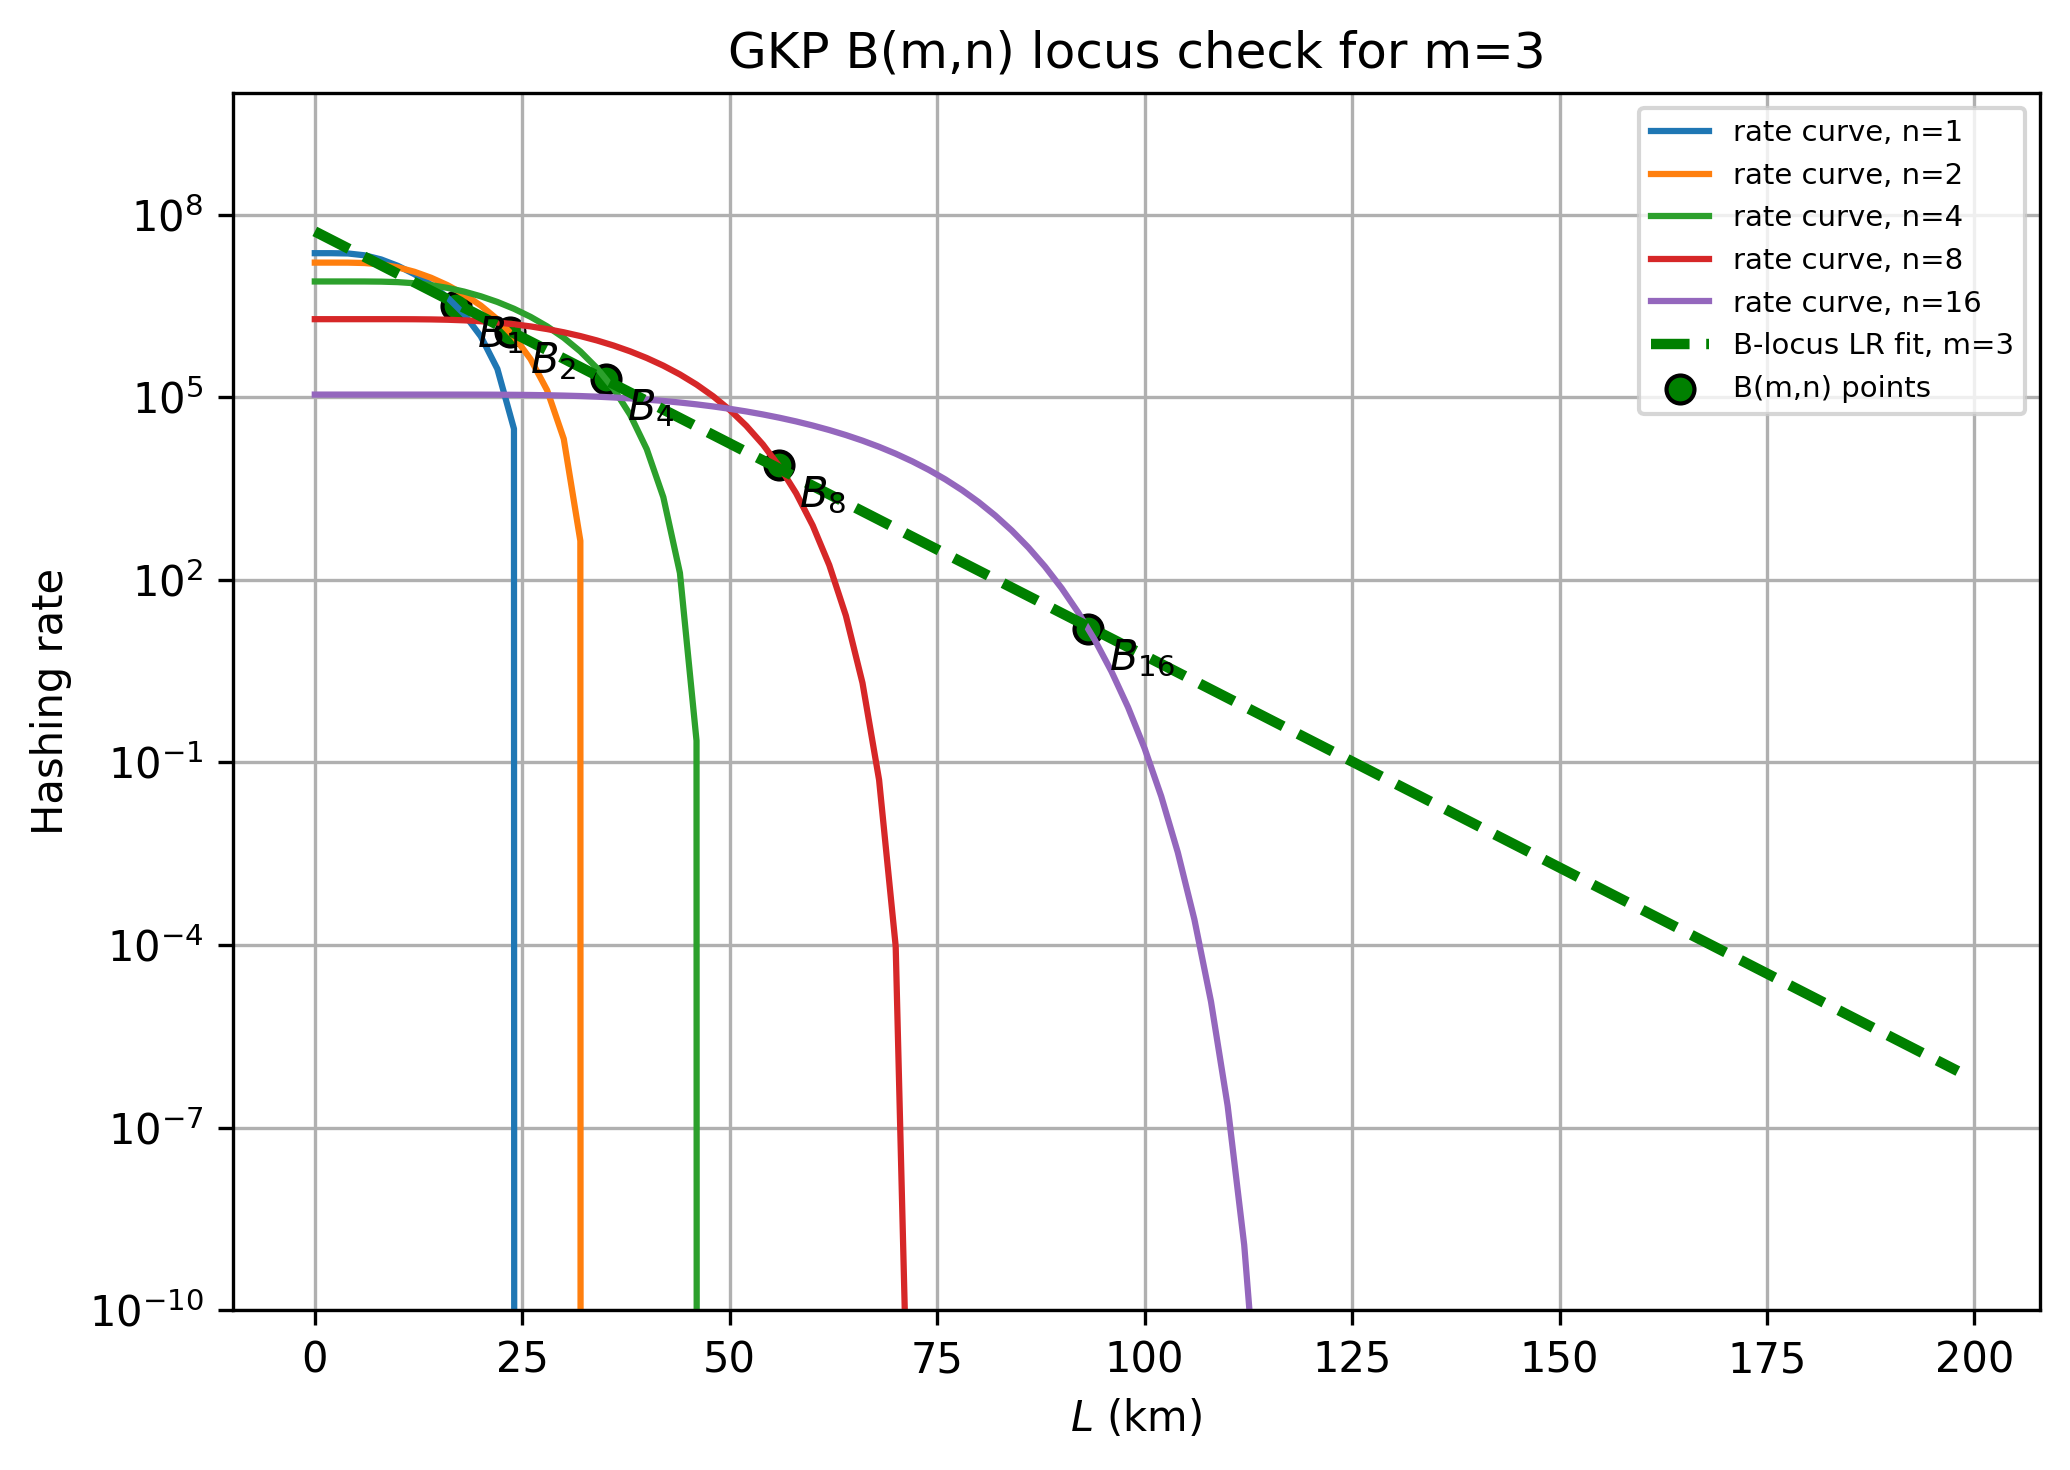

In [52]:
# Choose m to inspect
m_target = 3

# Find stored B-locus index
idx = next(
    i for i, d in enumerate(B_points_list)
    if d["m"] == m_target
)

# Recompute GKP rate curves for the same m
Ls = np.arange(0, 200, 2)

sigma1 = np.sqrt(0.01)
M = 1
q = 0.7
tau = 1e-8

n_vals = [1, 2, 4, 8, 16]

gkp_list = []

for n in n_vals:
    rates = [
        optimal_hashing_rate(sigma1, L, n, M, q, tau, m_target)
        for L in Ls
    ]
    gkp_list.append(rates)


# Plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title(f"GKP B(m,n) locus check for m={m_target}")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom=1e-10, top=1e10)
ax.grid(True)

color_cycle = plt.get_cmap("tab10")

# Rate curves
for i, rate_curve in enumerate(gkp_list):
    n = n_vals[i]
    color = color_cycle(i)

    ax.plot(
        Ls,
        rate_curve,
        color=color,
        linewidth=1.5,
        label=f"rate curve, n={n}"
    )

# B-locus LR fit
ax.plot(
    Ls,
    B_fit_list[idx],
    color="green",
    linewidth=2.5,
    linestyle="--",
    label=f"B-locus LR fit, m={m_target}"
)

# B(m,n) points
ax.scatter(
    B_points_list[idx]["L"],
    B_points_list[idx]["R"],
    color="green",
    edgecolor="black",
    s=45,
    label="B(m,n) points"
)

# Labels for B_n points
for n, LB, RB in zip(
    n_vals,
    B_points_list[idx]["L"],
    B_points_list[idx]["R"]
):
    ax.annotate(
        rf"$B_{{{n}}}$",
        (LB, RB),
        textcoords="offset points",
        xytext=(5, -10),
        fontsize=10
    )

ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Numercial form of $R^{LB}$

In [53]:
# --------------------------------------------------
# Fit log R(L) = a - b L^k
# --------------------------------------------------

R_target_B = fully_maximized_B_locus

valid = np.isfinite(R_target_B) & (R_target_B > 0) & np.isfinite(Ls)

# avoid L=0 because L^k can create numerical issues for small k
valid = valid & (Ls > 0)

L_fit = Ls[valid]
logR_fit = np.log(R_target_B[valid])


k_values = np.linspace(0.05, 1.50, 500)

best_R2 = -np.inf
best_k = None
best_slope = None
best_intercept = None

fit_results = []

for k in k_values:
    X = L_fit**k

    slope, intercept, r_value, p_value, std_err = linregress(X, logR_fit)

    R2 = r_value**2

    fit_results.append((k, R2, slope, intercept))

    if R2 > best_R2:
        best_R2 = R2
        best_k = k
        best_slope = slope
        best_intercept = intercept


a = best_intercept
b = -best_slope

print("Best scaling fit:")
print(f"k = {best_k:.6f}")
print(f"R^2 = {best_R2:.12f}")
print()
print("log R(L) = a - b L^k")
print(f"a = {a:.6e}")
print(f"b = {b:.6e}")
print(f"k = {best_k:.6e}")
print()
print(f"R(L) = exp({a:.6e}) * exp(-({b:.6e}) * L^{best_k:.6e})")

Best scaling fit:
k = 0.991483
R^2 = 0.999992749564

log R(L) = a - b L^k
a = 1.827537e+01
b = 1.706237e-01
k = 9.914830e-01

R(L) = exp(1.827537e+01) * exp(-(1.706237e-01) * L^9.914830e-01)


# Plot of maximised LR fit and numerically derived line $R^{LB}$

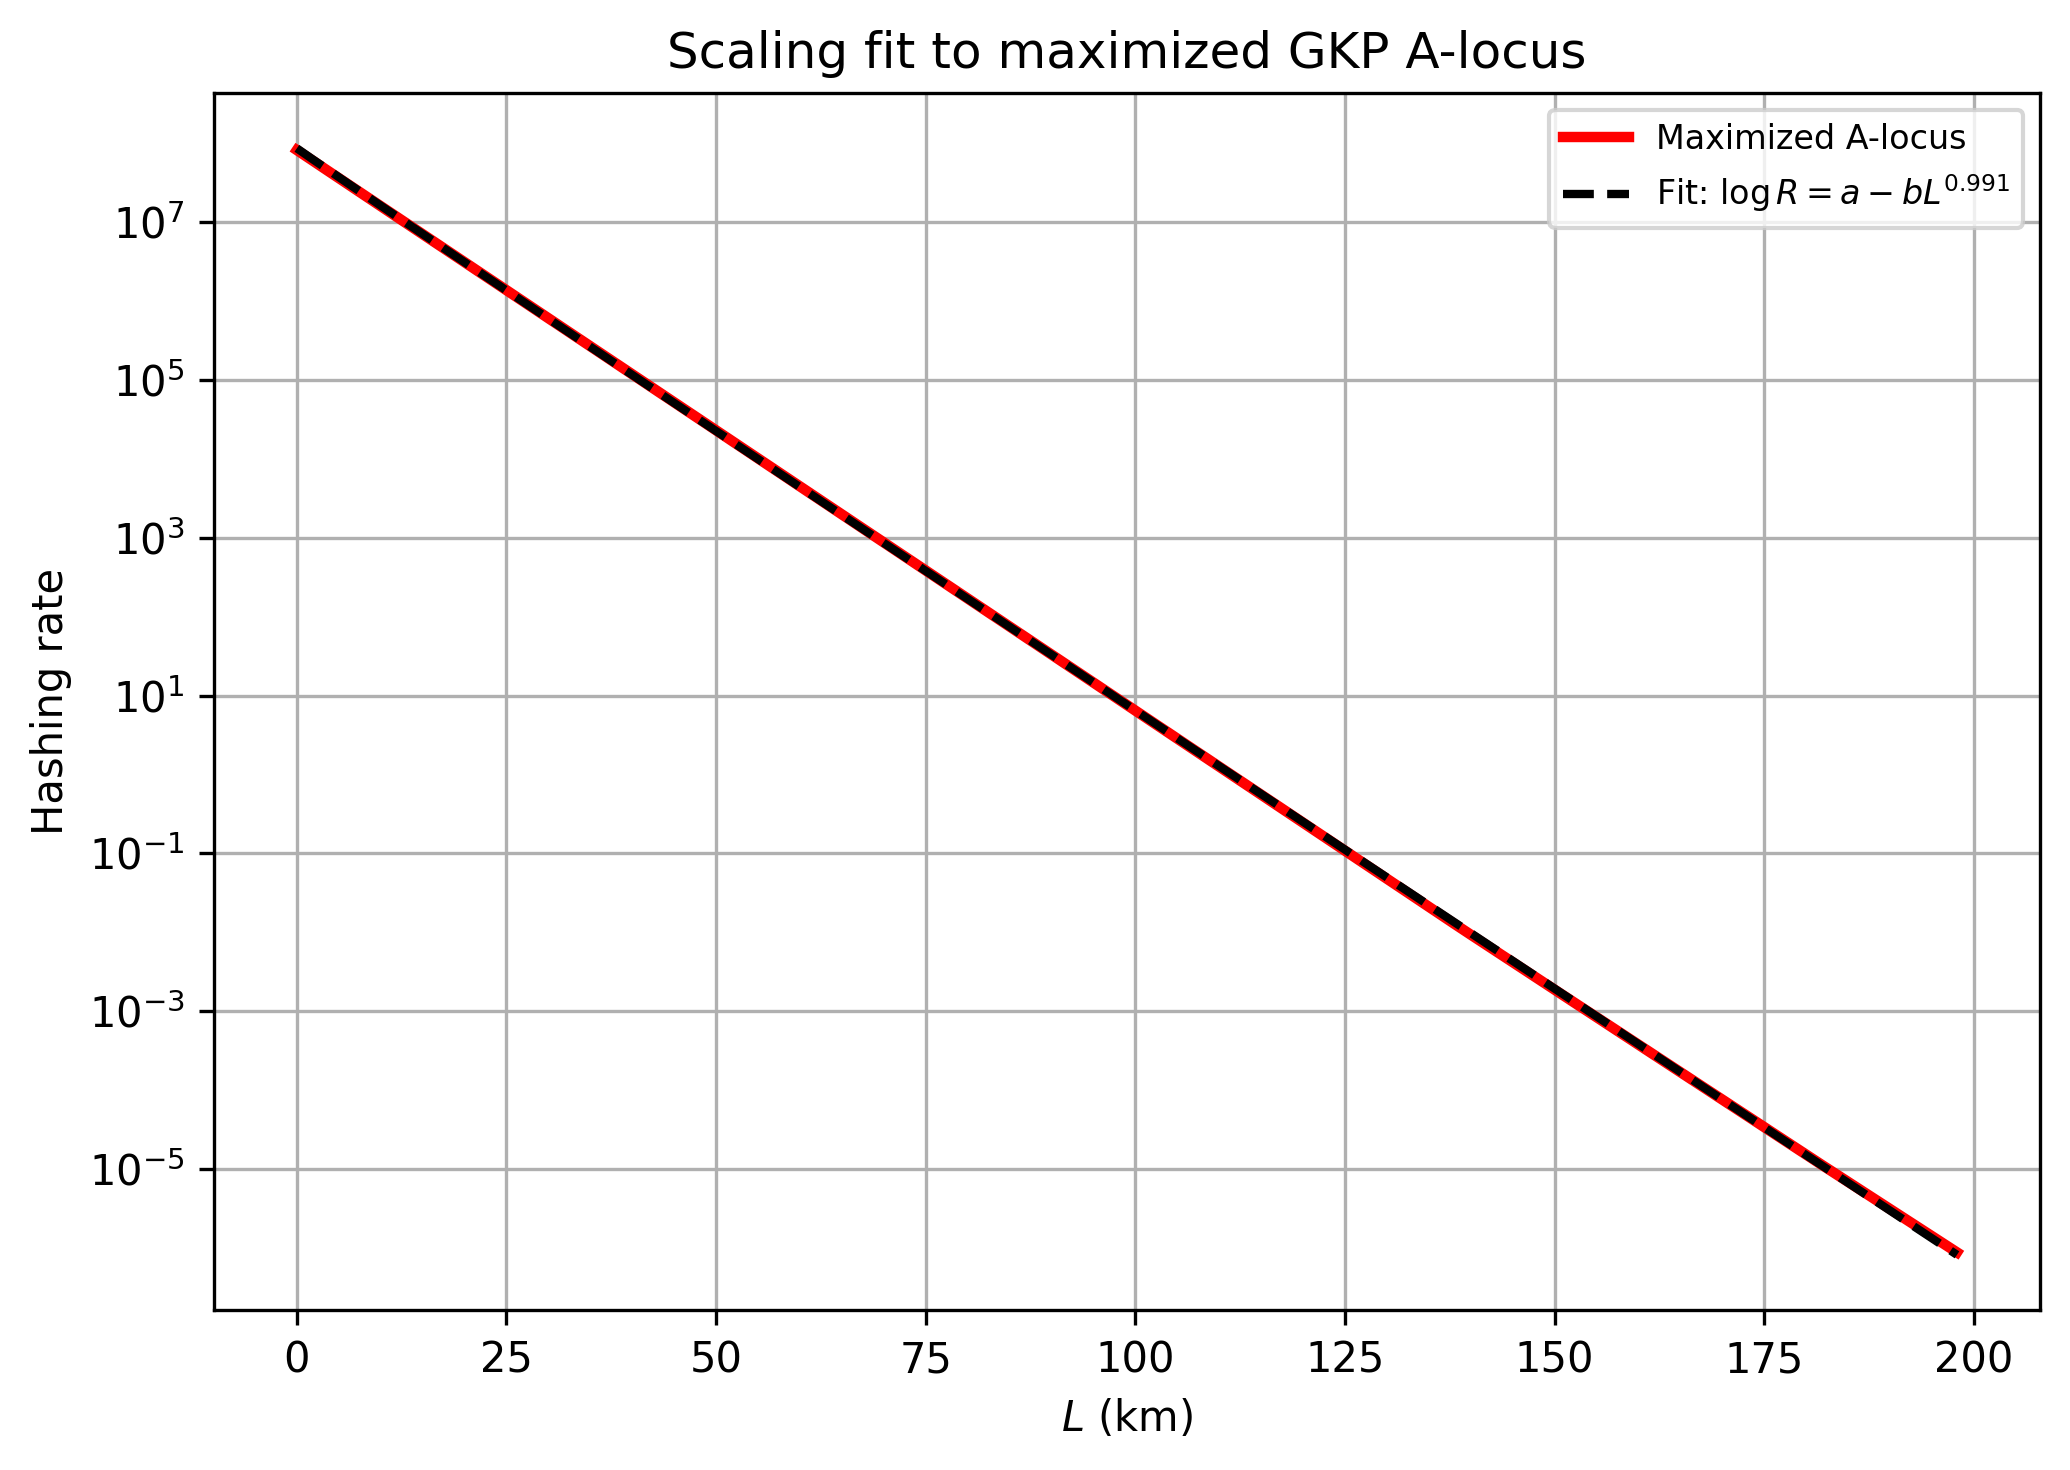

In [54]:
R_scaling_fit = np.exp(a - b * Ls**best_k)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title("Scaling fit to maximized GKP A-locus")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

ax.plot(Ls,fully_maximized_B_locus,color="red",linewidth=2.5,label="Maximized A-locus")

ax.plot(Ls,R_scaling_fit,color="black",linestyle="--",linewidth=2,label=rf"Fit: $\log R = a - bL^{{{best_k:.3f}}}$")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

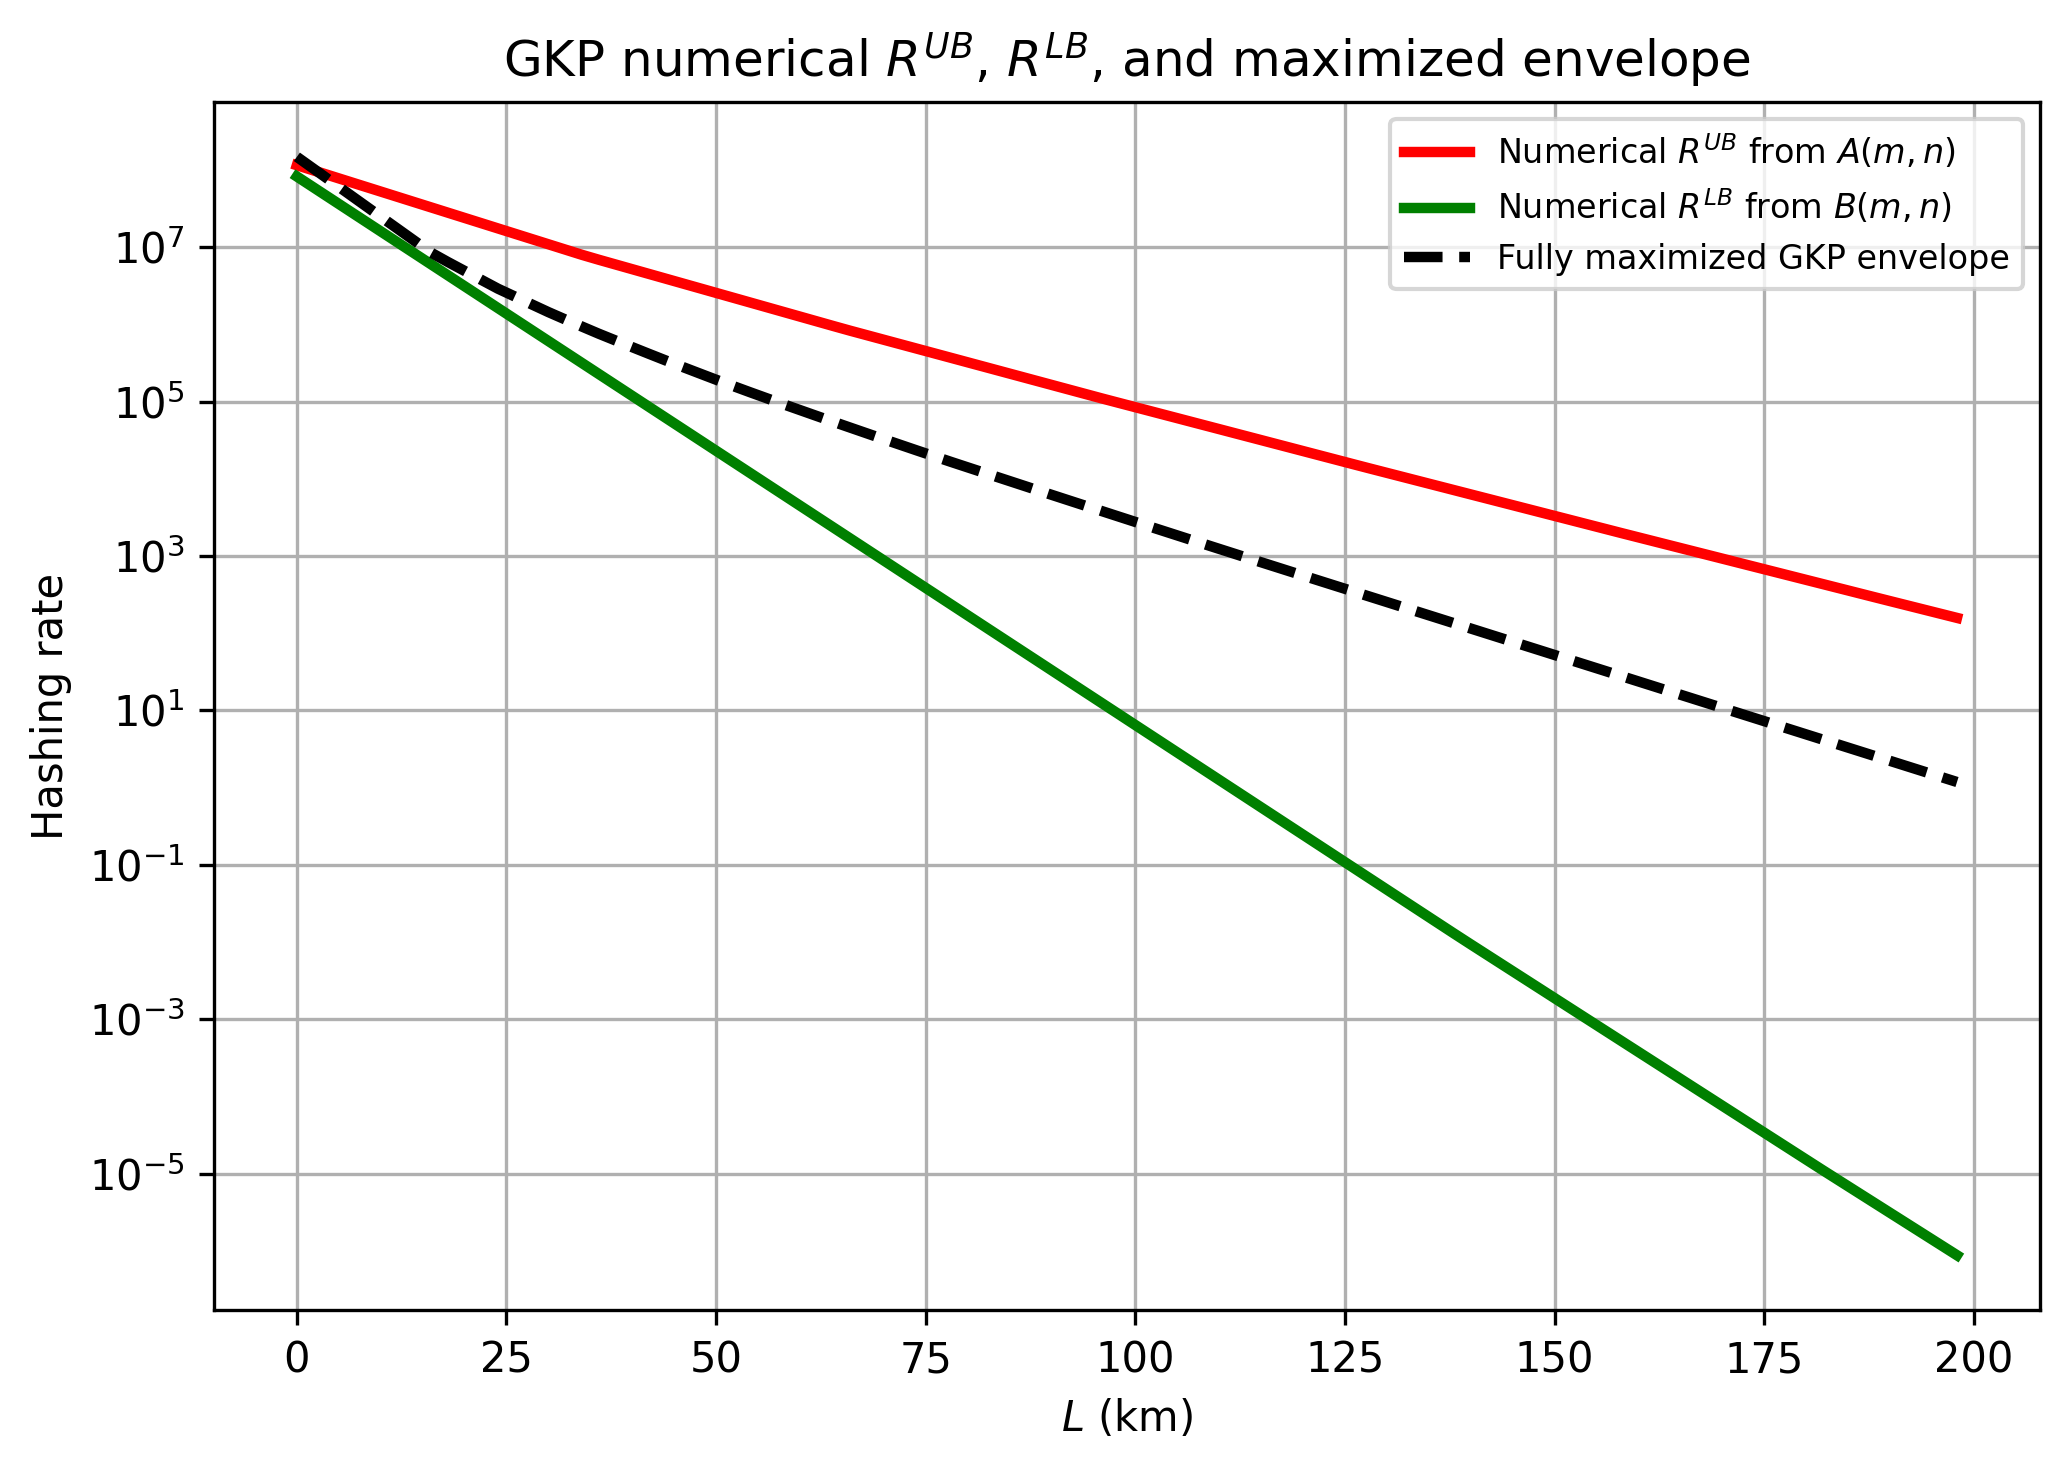

In [55]:
# --------------------------------------------------
# Final plot: numerical R^UB, R^LB, and GKP envelope
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title(r"GKP numerical $R^{UB}$, $R^{LB}$, and maximized envelope")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

ax.plot(Ls,fully_maximized_A_locus,color="red",linestyle="-",linewidth=2.5,label=r"Numerical $R^{UB}$ from $A(m,n)$")

ax.plot(Ls,fully_maximized_B_locus,color="green",linestyle="-",linewidth=2.5,label=r"Numerical $R^{LB}$ from $B(m,n)$")

ax.plot(Ls,fully_maximized_gkp_env,color="black",linestyle="--",linewidth=2.5,label="Fully maximized GKP envelope")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Helper function for numerically derived forms of $R^{UB}$ and $R^{LB}$ for families A(m,n) and B(m,n)

In [56]:
def fit_scaling_law(Ls, R_target, k_values=np.linspace(0.05, 1.50, 500)):
    valid = np.isfinite(R_target) & (R_target > 0) & np.isfinite(Ls) & (Ls > 0)

    L_fit = Ls[valid]
    logR_fit = np.log(R_target[valid])

    best_R2 = -np.inf
    best_k = None
    best_slope = None
    best_intercept = None

    for k in k_values:
        X = L_fit**k
        slope, intercept, r_value, *_ = linregress(X, logR_fit)
        R2 = r_value**2

        if R2 > best_R2:
            best_R2 = R2
            best_k = k
            best_slope = slope
            best_intercept = intercept

    a = best_intercept
    b = -best_slope

    R_fit = np.exp(a - b * Ls**best_k)

    return {
        "a": a,
        "b": b,
        "k": best_k,
        "R2": best_R2,
        "R_fit": R_fit
    }

In [57]:
A_scaling = fit_scaling_law(Ls, fully_maximized_A_locus)
B_scaling = fit_scaling_law(Ls, fully_maximized_B_locus)

print("Numerical R^UB from A(m,n):")
print(f"R^2 = {A_scaling['R2']:.12f}")
print(f"k   = {A_scaling['k']:.6f}")
print(f"a   = {A_scaling['a']:.6e}")
print(f"b   = {A_scaling['b']:.6e}")
print(
    f"R^UB(L) = exp({A_scaling['a']:.6e}) "
    f"* exp(-({A_scaling['b']:.6e}) L^{A_scaling['k']:.6e})"
)

print("\nNumerical R^LB from B(m,n):")
print(f"R^2 = {B_scaling['R2']:.12f}")
print(f"k   = {B_scaling['k']:.6f}")
print(f"a   = {B_scaling['a']:.6e}")
print(f"b   = {B_scaling['b']:.6e}")
print(
    f"R^LB(L) = exp({B_scaling['a']:.6e}) "
    f"* exp(-({B_scaling['b']:.6e}) L^{B_scaling['k']:.6e})"
)

Numerical R^UB from A(m,n):
R^2 = 0.999990517172
k   = 0.907214
a   = 1.865831e+01
b   = 1.121001e-01
R^UB(L) = exp(1.865831e+01) * exp(-(1.121001e-01) L^9.072144e-01)

Numerical R^LB from B(m,n):
R^2 = 0.999992749564
k   = 0.991483
a   = 1.827537e+01
b   = 1.706237e-01
R^LB(L) = exp(1.827537e+01) * exp(-(1.706237e-01) L^9.914830e-01)


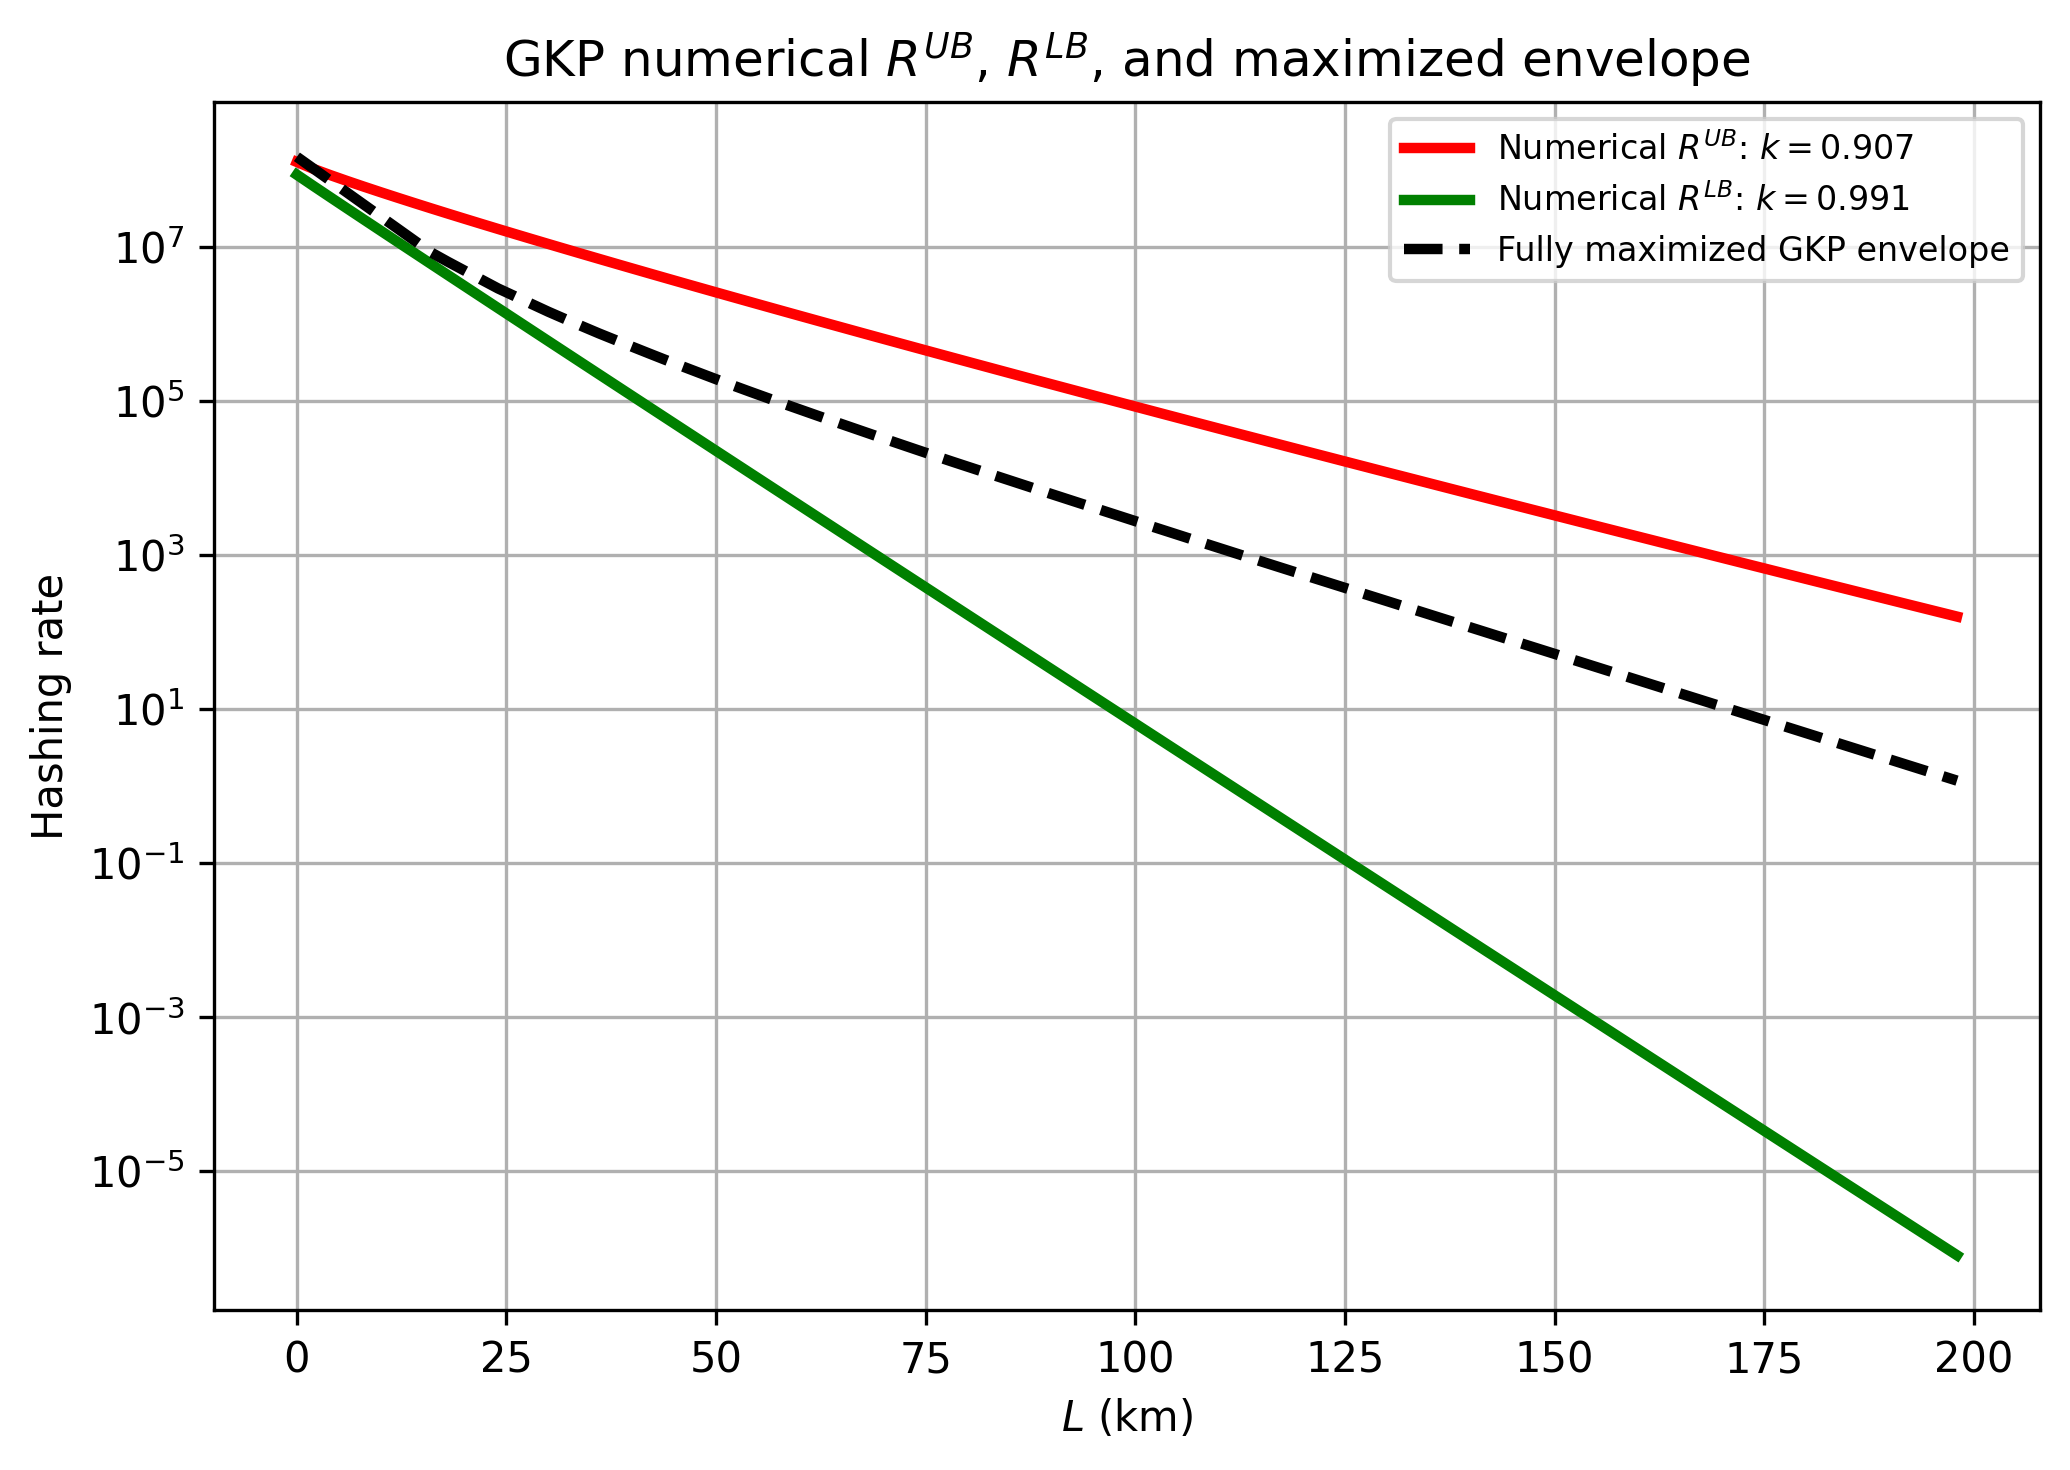

In [59]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.set_yscale("log")
ax.set_title(r"GKP numerical $R^{UB}$, $R^{LB}$, and maximized envelope")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.grid(True)

ax.plot(
    Ls,
    A_scaling["R_fit"],
    color="red",
    linewidth=2.5,
    label=rf"Numerical $R^{{UB}}$: $k={A_scaling['k']:.3f}$"
)

ax.plot(
    Ls,
    B_scaling["R_fit"],
    color="green",
    linewidth=2.5,
    label=rf"Numerical $R^{{LB}}$: $k={B_scaling['k']:.3f}$"
)

ax.plot(
    Ls,
    fully_maximized_gkp_env,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Fully maximized GKP envelope"
)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The numerically derived line for $R^{LB}$ is barely subexponential, and does not serve as a tight lower bound to the GKP HR envelope. The steepness of this line can be explained due to the fact that GKP HR curves plummet at much shorter distances, and so we should rethink what can serve as an appropriate lower bound to the HR envelope in order to definitely characterise its behaviour as subexponential

# PLOB

What are the units for the amount of information we can send per channel use, for a quantum channel and I’m sending quantum states and generating entanglement?


The capacity is ebits per channel use.

A channel is defined as an evolution on a quantum state $\rho$, and every time I send $\rho$ I get X ebits out from the channel, so it is ebits per channel use.

This division to get rate comes about by using the channel X number of times per second, and the pulse duration determines this amount, so if we’re calculating a hashing rate we have to either divide by the pulse duration or multiply by the repetition rate.

But, if we’re calculating a hashing bound per channel use, how is my protocol working? We then divide by time. The distinction is in the units, rate per channel use is obviously per channel use, and repetition rate is how many times we’re using the channel per second.

In [90]:
def PLOB_bound(L, alpha_dB_per_km=0.2 , M = 1 , tau = 1e-8):
    alpha = (alpha_dB_per_km / 10) * np.log(10)
    eta = np.exp(-alpha * L)
    return -np.log2(1 - eta) * (M / tau)

Ls = np.arange(0,200,2)
PLOB_bound_tab = []
for L in Ls:
    PLOB_bound_tab.append(PLOB_bound(L))

def PLOB_bound2(L, alpha_dB_per_km=0.2 , M = 1 , tau = 1e-8):
    eta = np.exp(-alpha_dB_per_km * L)
    return -np.log2(1 - eta) * (M / tau)

Ls = np.arange(0,200,2)
PLOB_bound_tab2 = []
for L in Ls:
    PLOB_bound_tab2.append(PLOB_bound2(L))

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_986/2574889327.py:4: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)
/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_986/2574889327.py:13: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta) * (M / tau)


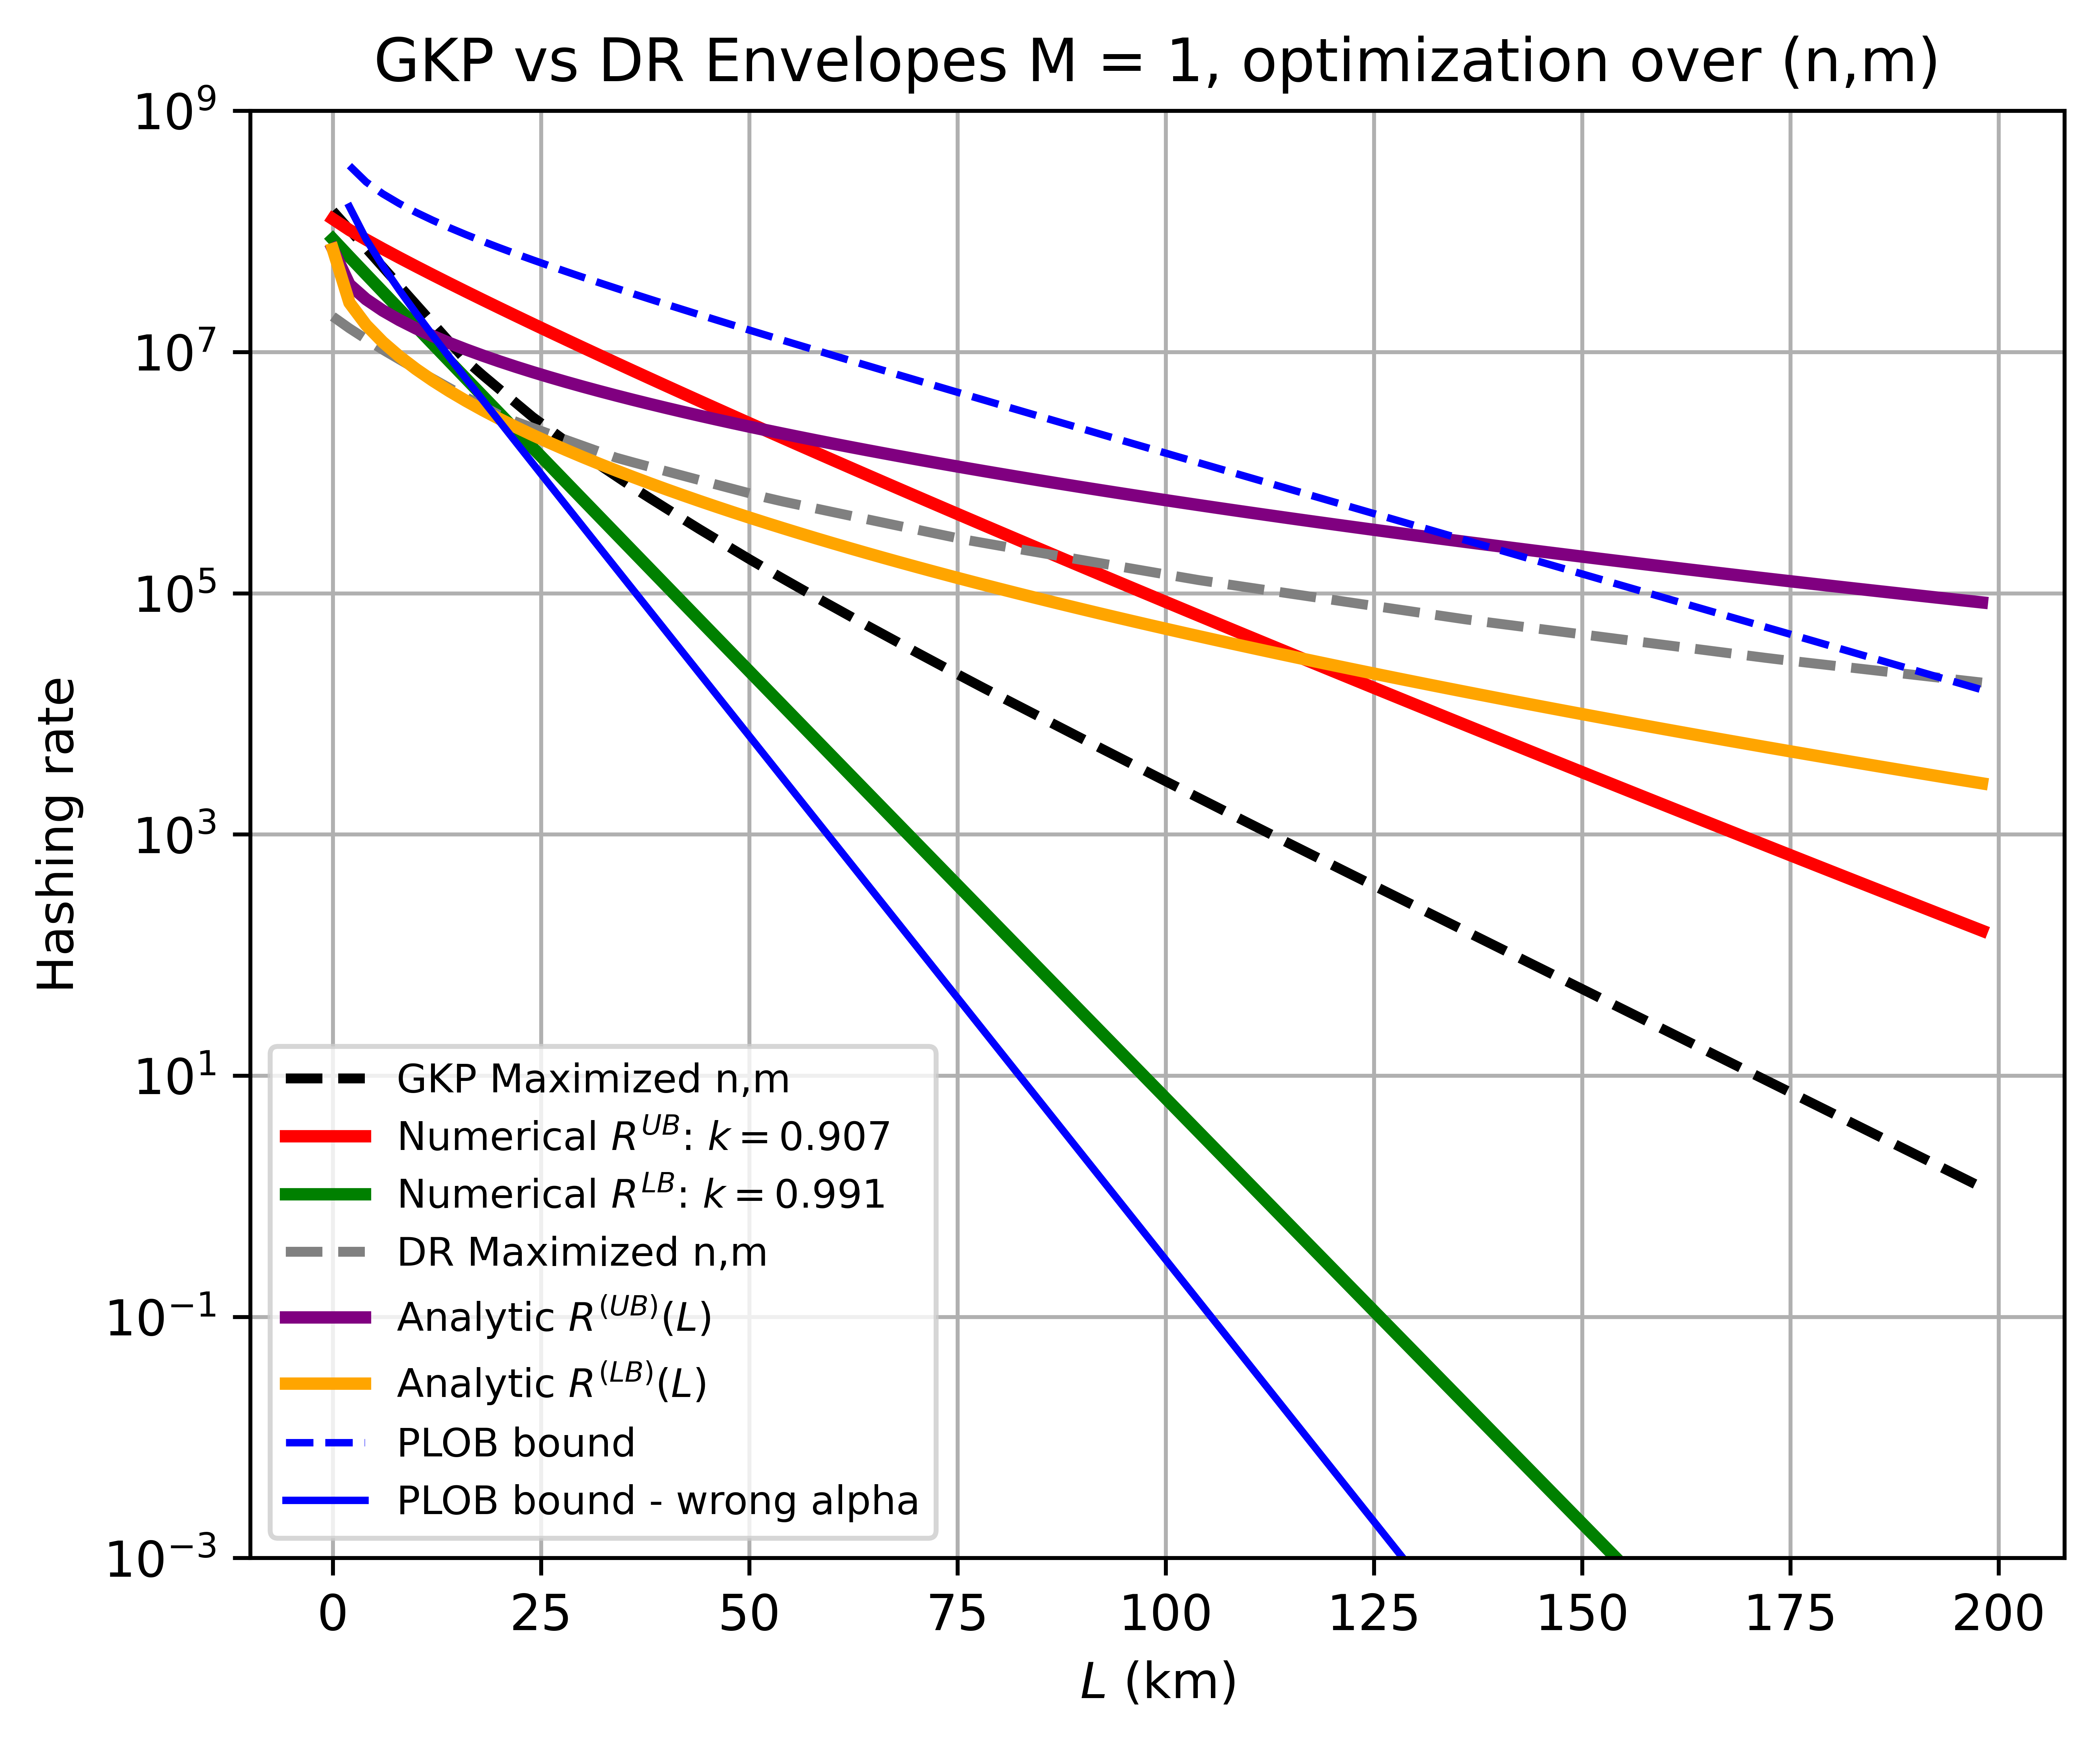

In [61]:
fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("GKP vs DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom = 1e-3,top=1e9)
ax.grid(True)
# ax.set_ylim(bottom = 5e-3 , top = 5e8)

color_cycle = plt.get_cmap("tab10")

# fully maximized GKP envelope over n,m
ax.plot(
    Ls,
    fully_maximized_gkp_env,
    color="black",
    linestyle="--",
    linewidth=2,
    label="GKP Maximized n,m"
)

ax.plot(
    Ls,
    A_scaling["R_fit"],
    color="red",
    linewidth=2.5,
    label=rf"Numerical $R^{{UB}}$: $k={A_scaling['k']:.3f}$"
)

ax.plot(
    Ls,
    B_scaling["R_fit"],
    color="green",
    linewidth=2.5,
    label=rf"Numerical $R^{{LB}}$: $k={B_scaling['k']:.3f}$"
)

# fully maximized DR envelope over n,m
ax.plot(
    Ls,
    fully_maximized_env_actual,
    color="grey",
    linestyle="--",
    linewidth=2,
    label="DR Maximized n,m"
)

ax.plot(
    Ls,
    R_UB,
    color="purple",
    linestyle="-",
    linewidth=2.5,
    label=r"Analytic $R^{(UB)}(L)$"
)

ax.plot(
    Ls,
    R_LB,
    color="orange",
    linestyle="-",
    linewidth=2.5,
    label=r"Analytic $R^{(LB)}(L)$"
)
ax.plot(Ls,PLOB_bound_tab , color='blue',label="PLOB bound" , linestyle = "--")
ax.plot(Ls,PLOB_bound_tab2 , color='blue',label="PLOB bound - wrong alpha")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

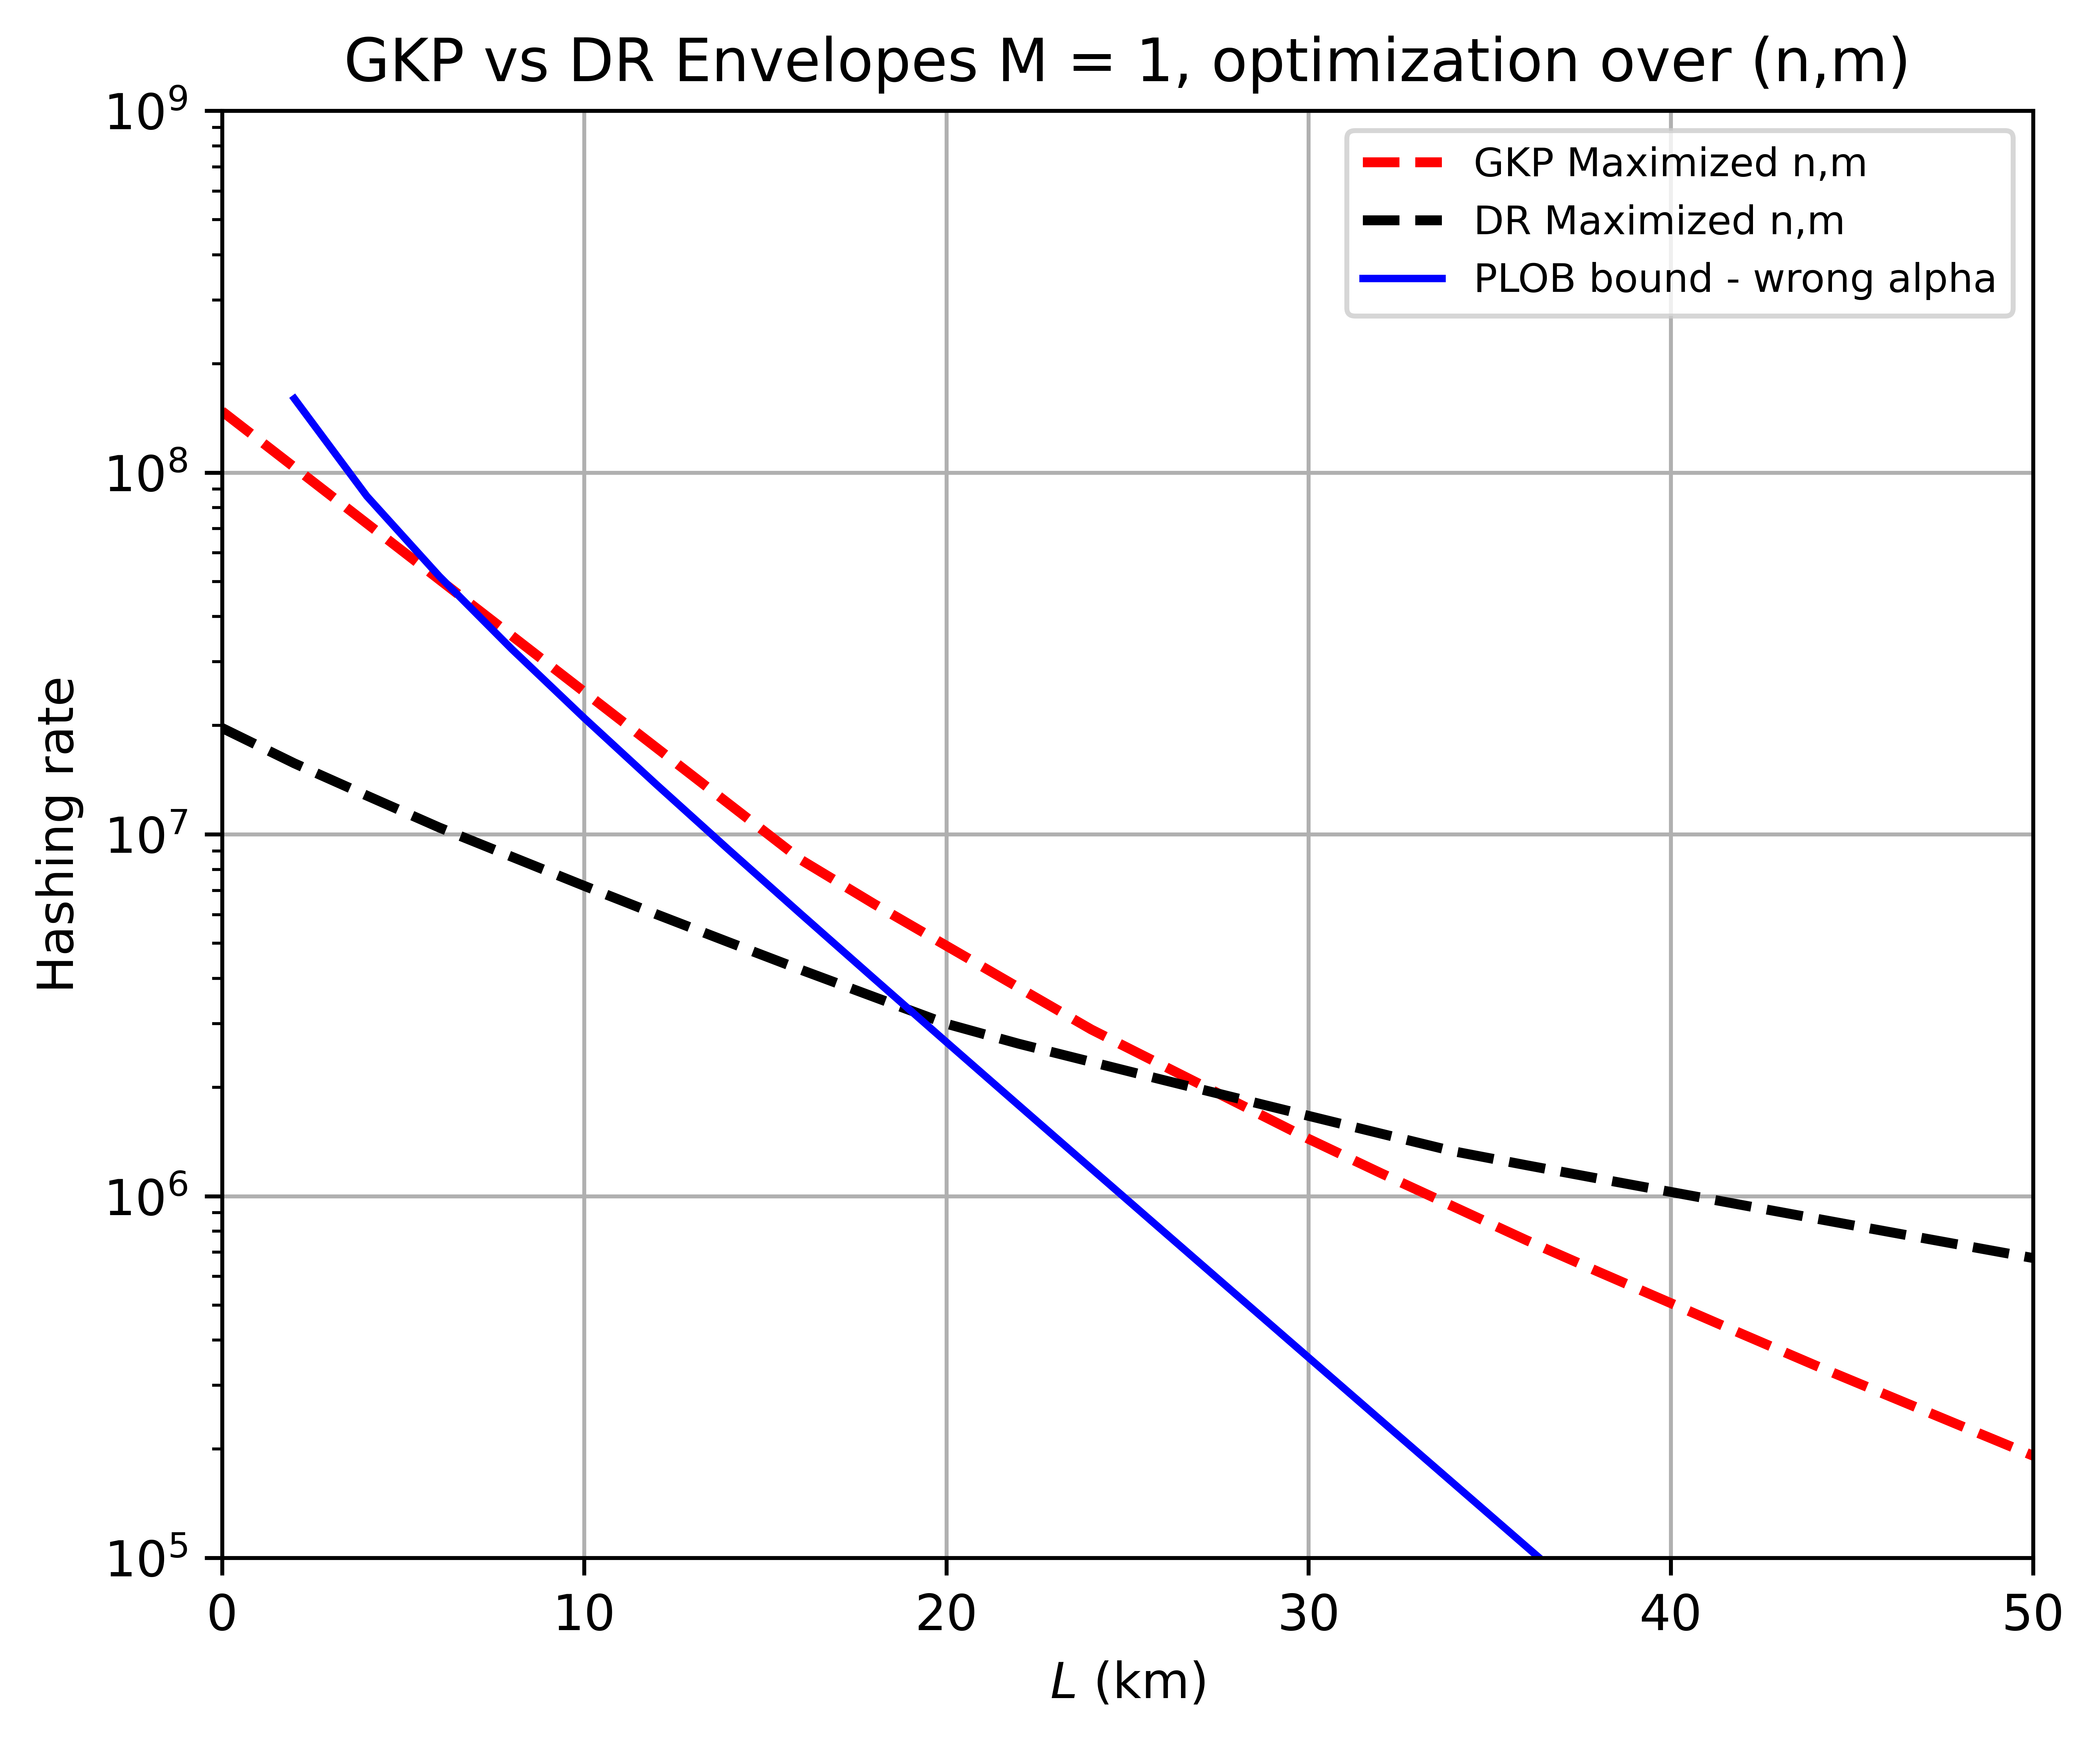

In [ ]:
fig, ax = plt.subplots(figsize=(6,5), dpi=1000)

ax.set_yscale("log")
ax.set_title("GKP vs DR Envelopes M = 1, optimization over (n,m)")
ax.set_xlabel("$L$ (km)")
ax.set_ylabel("Hashing rate")
ax.set_ylim(bottom = 1e5,top=1e9)
ax.set_xlim(0 , 50)
ax.grid(True)
# ax.set_ylim(bottom = 5e-3 , top = 5e8)

color_cycle = plt.get_cmap("tab10")

# fully maximized GKP envelope over n,m
ax.plot(
    Ls,
    fully_maximized_gkp_env,
    color="red",
    linestyle="--",
    linewidth=2,
    label="GKP Maximized n,m"
)


# fully maximized DR envelope over n,m
ax.plot(
    Ls,
    fully_maximized_env_actual,
    color="black",
    linestyle="--",
    linewidth=2,
    label="DR Maximized n,m"
)

ax.plot(Ls,PLOB_bound_tab2 , color='blue',label="PLOB bound")

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# GKP  qudit code

# Qudit basis definition

In [64]:
#defining basic qudit vectors
def qudit_basis(d , k):
    vec = np.zeros((d , 1) , dtype = complex)
    vec[k , 0] = 1.0
    return vec

# Qudit Bell State

$|\Psi_{k,l}\rangle_{1,2} = \frac{1}{\sqrt{d}}\sum_{k'=0}^{d-1}exp(2\pi i k' l /d) |k'\rangle_{1} \otimes |k' - k\rangle_{2}$

In [65]:
#defining the qudit Bell state from Equation (26)
#in the published manuscript this comes from Equatoin (S3) in the Supplemental Material
def qudit_Bell_state(d , k , l):
    #above expression is a summation so we initialise a 0-vector and iteratively add to it
    psi = np.zeros((d * d , 1) , dtype = complex)

    #iterating over index r = k'
    for r in range(d):

        phase = np.exp(2j * np.pi * r * l / d)
        ket1 = qudit_basis(d , r)
        ket2 = qudit_basis(d , (r - k) % d)

        psi += phase * kron(ket1 , ket2)

    return psi / np.sqrt(d)

#defining qudit Bell state projector
def qudit_Bell_state_projector(d , k , l):
    psi = qudit_Bell_state(d , k , l)
    return psi @ np.conjugate(psi.T)

# Loss Model from QR model

In [66]:
# transmissivity for QR setup
def new_eta(L, n):
    alpha_dB_per_km = 0.2
    # convert dB/km to 1/km
    alpha = (alpha_dB_per_km / 10) * np.log(10)
    # eta ∈ [0, 1]
    return np.exp(-alpha * L / (n + 1))

#Quality of GKP state
def sigma_loss(sigma , L , n):
    eta = new_eta(L , n)
    # subjecting qudits to pure loss channel
    return np.sqrt(eta * sigma**2 + (1 - eta))

# Shift Probability

$P^{(sq)}(\hat{X}^{k},\sigma^{2}) \equiv P^{(sq)}(\hat{Z}^{k},\sigma^{2})$

$P^{(sq)}(\hat{X}^{k},\sigma^{2}) = P^{(sq)}(\hat{Z}^{k},\sigma^{2}) = \sum_{j \in \mathbb{Z}} \frac{1}{2} \Big(\text{erf}\Big(\sqrt{\frac{2\pi}{d}} \frac{jd + k + 1/2}{\sigma}\Big) - \text{erf}\Big(\sqrt{\frac{2\pi}{d}} \frac{jd + k - 1/2}{\sigma}\Big)\Big)$

In [68]:
from scipy.special import erf

def shift_probability(d , k , sigma , j_cutoff = 30):

    #considering the scenario of an ideal-squeezed GKP qudit
    if sigma == 0:
        return 1.0 if k == 0 else 0.0

    #this probability is a summation over the integers
    #we will not consider an infinite summation,
    #instead we consider a portion of the space denoted j_cutoff
    #since this probability is a summation we begin with an initialisation
    shift_probability_total = 0.0

    #defining the qudit lattice spacing
    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    #summing over the space defined by j_cutoff
    for j in range(-j_cutoff , j_cutoff + 1):
        upper_bound = qudit_lattice_spacing * (j * d + k + 0.5) / sigma
        lower_bound = qudit_lattice_spacing * (j * d + k - 0.5) / sigma
        shift_probability_total += 0.5 * (erf(upper_bound) - erf(lower_bound))
    
    return float(np.real(shift_probability_total))

In the definition of our memory-memory state

$\tilde{\rho}_{\textbf{M}_{1}\textbf{M}_{2}} = \sum_{k_{1},k_{2} = 0}^{d-1} P_{shift}^{(k_{1},k_{2})}(\sigma^{2})|\Psi_{k',l'}\rangle\langle\Psi_{k',l'}|_{\textbf{M}_{1}\textbf{M}_{2}}$

with $P_{shift}^{(k_{1},k_{2})}(\sigma^{2}) = P^{(sq)}(\hat{X}^{k_{1}},\sigma^{2})\cdot P^{(sq)}(\hat{Z}^{k_{1}},\sigma^{2})$

 the shift probabilities are defined by a summation over $k_{1}k_{2}=0$ up to $d-1$, so we take the above script for the shift probability and we sum up over all $k$ from 0 up to $d-1$. Later when we define the memory-memory state we will input the different shift errors ($\hat{X}$,$\hat{Z}$)

In [69]:
def shift_probability_vector(d , sigma , j_cutoff = 30):
    #for each value of k over which we are performing our summation
    #we create an array d elements long with each entry being the probability calculated for said value k
    #we then normalise these probabilities by dividing by the sum of shift_probabilities
    #we normalise because in our defintiion of shift_probability we truncate the space we're observing using j_cutoff
    #the summation is performed in the next cell
    shift_probabilities = np.array([shift_probability(d , k , sigma , j_cutoff) for k in range(d)])
    
    # defining the total probability vector of length d
    total = np.sum(shift_probabilities)
    if total <= 0:
        raise ValueError("Shift probability normalisation failed")

    return shift_probabilities / total

# Building $\tilde{\rho}_{\textbf{M}_{1}\textbf{M}_{2}}$

Now we construct our memory-memory state $|\Psi_{k' , l'}\rangle\langle\Psi_{k' , l'}|_{\textbf{M}_{1}\textbf{M}_{2}}$

We note that the qudit Bell state we have constructed $|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}}$ is defined using the unshifted state $|\Psi_{0,0}\rangle_{M_{i}G_{i}}$ (no $\hat{X}$ or $\hat{Z}$ errors) subjected to the Weyl operators $W_{1}^{(0 , d-x_{L})}W_{2}^{(d - y_{L} , 0)}$:

$|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}} = W_{1}^{(0 , d-x_{L})}W_{2}^{(d - y_{L} , 0)} |\Psi_{0,0}\rangle_{M_{i}G_{i}}$

We note that this $|\Psi_{k' , l'}\rangle_{\textbf{M}_{1}\textbf{M}_{2}}$ state is dependent on the BSM logical outcomes $(x_{L} , y_{L})$, where the labels of the qudit Bell state $\textbf{AFTER}$ the DHD are described as

$k' = d - x_{L}$ (mod d) and $l' = d - y_{L}$ (mod d)

In [70]:
def qudit_memory_memory_state(d , sigma , j_cutoff = 30 , xL = 0 , yL = 0):

    #we first define shift probabilities for X and Z errors
    
    P_shift_X = shift_probability_vector(d , sigma , j_cutoff)
    P_shift_Z = shift_probability_vector(d , sigma , j_cutoff)

    #we also define state labels dependent on the logical outcomes of the BSM xL and yL
    #these labels (xL , yL) tell us which Bell state we get from the measurement
    #since we know them  we can always correct them
    #therefore we set xL = yL = 0 without loss of generality
    
    k0 = (d - xL) % d
    l0 = (d - yL) % d

    #initialising our memory-memory state
    rho = np.zeros((d * d , d * d) , dtype = complex)

    #X shift occurs k1 times
    #Z shift occurs k2 times
    for k1 in range(d):
        for k2 in range(d):
            #defining the full shift probability for X and Z errors
            shift_probability = P_shift_X[k1] * P_shift_Z[k2]
            #defining the k and l labels for the memory-memory state
            #these are the labels defined in qudit_Bell_state_projector
            #they need to be shifted due to the X and Z errors that occur
            k_label = (k0 + k1) % d
            l_label = (l0 + k2) % d
            #summing over labels to obtain memory-memory state
            rho += shift_probability * qudit_Bell_state_projector(d , k_label , l_label)

    return rho

# Defining the Bell diagonal form of the GKP qudit state

In [71]:
def qudit_bell_diagonal_probs(d, sigma, xL=0, yL=0, j_cutoff=30):
    ProbX = shift_probability_vector(d, sigma, j_cutoff)
    ProbZ = shift_probability_vector(d, sigma, j_cutoff)

    k0 = (d - xL) % d
    l0 = (d - yL) % d

    probs = {}

    for k1 in range(d):
        for k2 in range(d):
            k_label = (k0 + k1) % d
            l_label = (l0 + k2) % d
            probs[(k_label, l_label)] = ProbX[k1] * ProbZ[k2]

    return probs

# Loss Model from GKP qudit paper

In [72]:
# ----------------------------
# Loss + squeezing model
# ----------------------------

def sigma_squared_from_squeezing_db(squeezing_db):

    # eta_squeeze = -10 log10(sigma^2)
    # so sigma^2 = 10^(-eta_squeeze/10).

    if np.isinf(squeezing_db):
        return 0.0
    return 10** (-squeezing_db / 10)


def half_channel_transmissivity(loss_db):

    # x-axis is loss of half channel in dB.
    # eta_half_channel_loss = sqrt(eta) = 10^(-loss_db / 10).

    return 10**(-loss_db / 10)


def effective_sigma(loss_db , squeezing_db):

    # Paper states converison model:
    # sigma_i^2 -> sigma_i^2 + (1 - sqrt(eta))

    # Here sqrt(eta) is the half-channel transmissivity.

    eta = half_channel_transmissivity(loss_db)
    sigma_i_squared = sigma_squared_from_squeezing_db(squeezing_db)
    sigma_eff_squared = sigma_i_squared + (1 - eta)
    return np.sqrt(sigma_eff_squared)

# Hashing Bound calculation

In [73]:
# ----------------------------
# Hashing bound from Eq. (18) of published manuscript
# ----------------------------

def hashing_bound_qudit(d , sigma , j_cutoff = 30):
    ProbX = shift_probability_vector(d , sigma , j_cutoff)
    ProbZ = shift_probability_vector(d , sigma , j_cutoff)

    Prob = np.outer(ProbX , ProbZ)
    Prob = Prob[Prob > 0]

    return np.log2(d) + np.sum(Prob * np.log2(Prob))


def hashing_bound_vs_loss(N , loss_db_array , squeezing_db):
    d = 2 ** N
    rates = []

    for loss_db in loss_db_array:
        sigma_eff = effective_sigma(loss_db , squeezing_db)
        rate = hashing_bound_qudit(d , sigma_eff)
        rates.append(max(rate , 0.0))

    return np.array(rates)


def repeaterless_bound_half_channel(loss_db_array):
    """
    Paper compares to -log2(1 - sqrt(eta)).
    Here sqrt(eta) = half-channel transmissivity.
    """
    eta = half_channel_transmissivity(loss_db_array)
    return -np.log2(1 - eta)

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_1392/2107881734.py:33: RuntimeWarning: divide by zero encountered in log2
  return -np.log2(1 - eta)


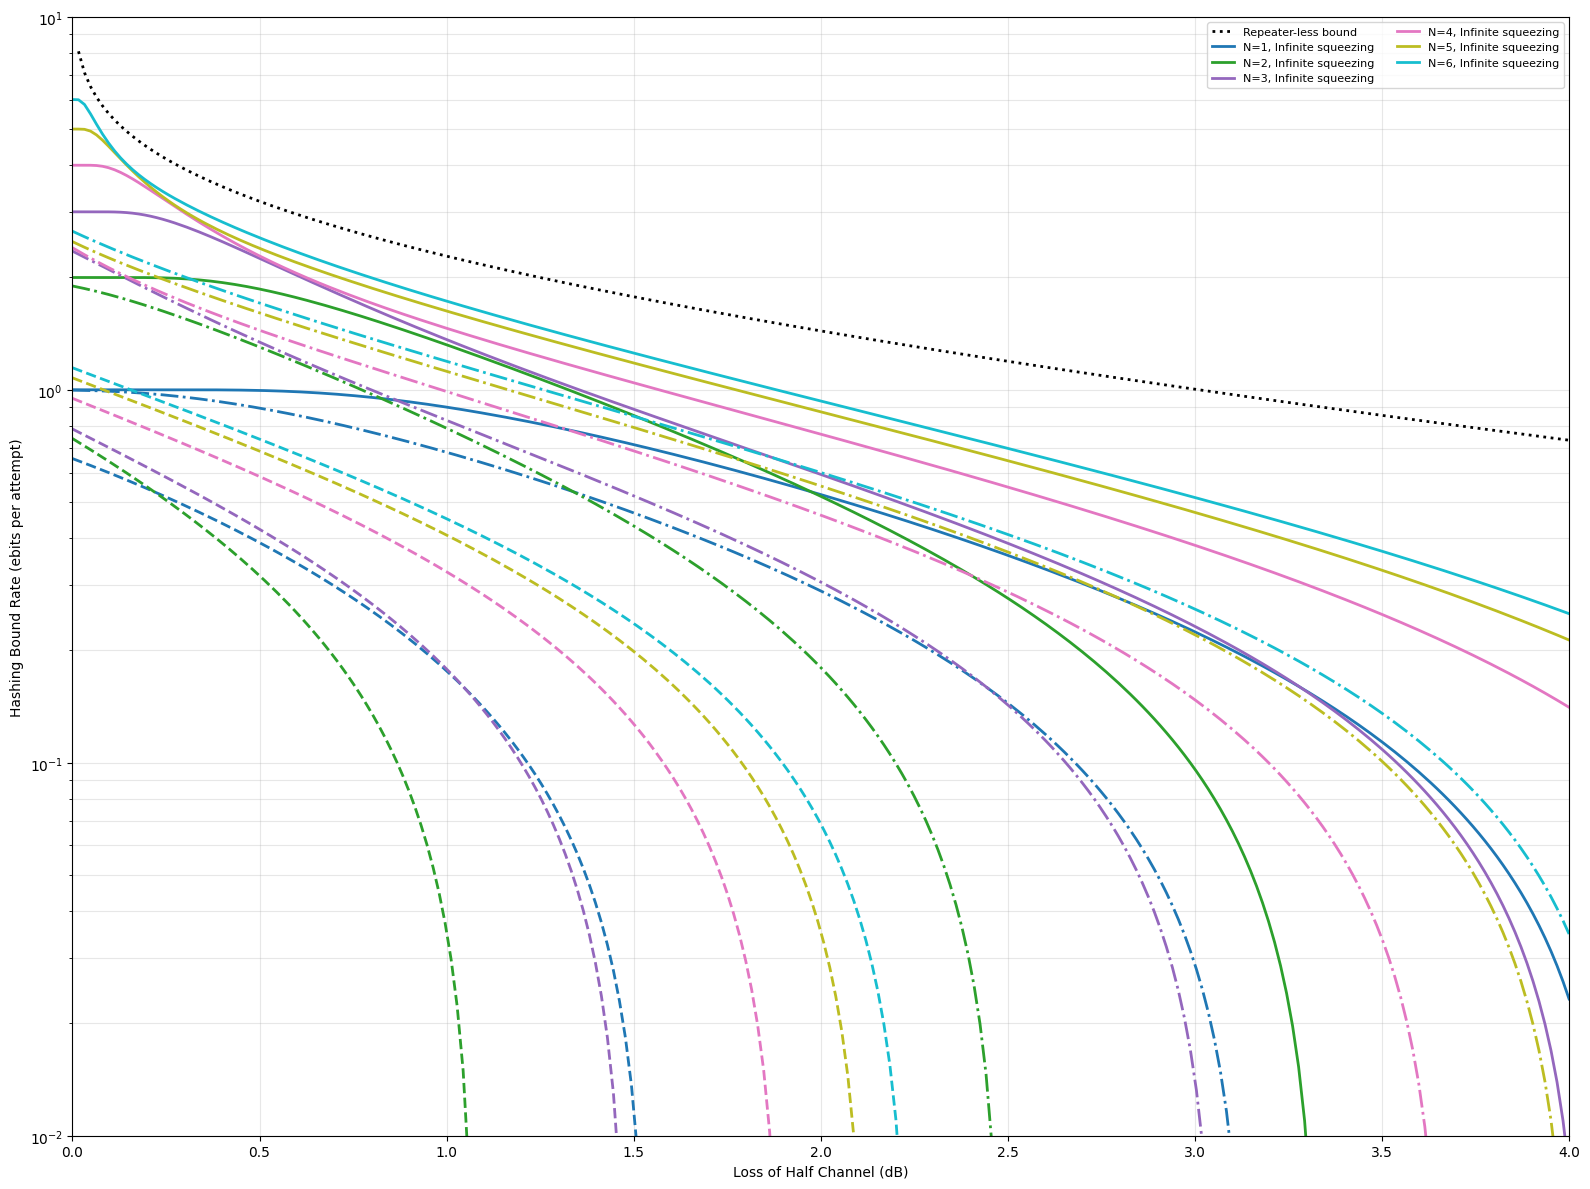

In [74]:
# ----------------------------
# Reproduce Fig. 4a: square GKP
# ----------------------------

def plot_fig4a_square_gkp():
    loss_db = np.linspace(0.0, 4.0, 250)

    Ns = [1, 2, 3, 4, 5, 6]
    squeezing_cases = [
        (np.inf, "-", "Infinite squeezing"),
        (10, "-.", "10 dB"),
        (5, "--", "5 dB")
    ]

    plt.figure(figsize=(16 , 12))

    # Repeaterless bound
    plt.semilogy(
        loss_db,
        repeaterless_bound_half_channel(loss_db),
        "k:",
        linewidth=2,
        label="Repeater-less bound"
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(Ns)))

    for idx, N in enumerate(Ns):
        for squeezing_db, linestyle, squeeze_label in squeezing_cases:
            rates = hashing_bound_vs_loss(
                N,
                loss_db,
                squeezing_db
            )

            label = f"N={N}, {squeeze_label}" if squeezing_db == np.inf else None

            plt.semilogy(
                loss_db,
                rates,
                linestyle=linestyle,
                color=colors[idx],
                linewidth=2,
                label=label
            )

    plt.xlabel("Loss of Half Channel (dB)")
    plt.ylabel("Hashing Bound Rate (ebits per attempt)")
    plt.xlim(0, 4)
    plt.ylim(1e-2, 1e1)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


plot_fig4a_square_gkp()

There are four different loss models we can consider that affect the GKP-encoded photonic qudits as they travel to the DHD measurement system:

1. Pure loss $(0\leq\eta\leq1)$:

$\sigma^{2}_{q} \rightarrow \eta\sigma_{q}^{2} + (1 - \eta)$

2. Phase-sensitive amplification $(G\geq1)$:

$\sigma_{q}^{2} \rightarrow G\sigma_{q}^{2} + (G - 1)$

3. Preamplified pure loss $(0\leq\eta\leq1 ; G = \frac{1}{\eta})$:

$\sigma_{q}^{2} \rightarrow \sigma_{q}^{2} + (1 - \eta)$

4. Postamplified pure loss $(0\leq\eta\leq1 ; G = \frac{1}{\eta})$:

$\sigma_{q}^{2} \rightarrow \sigma_{q}^{2} + \frac{(1 - \eta)}{\eta}$

In [ ]:
# ----------------------------
# Effective GKP variance model
# ----------------------------

def sigma_squared_from_squeezing_db(squeezing_db):

    if np.isinf(squeezing_db):
        return 0.0

    return 10 ** (-squeezing_db / 10)



def half_channel_transmissivity(loss_db):
    # sqrt(eta)
    return 10 ** (-loss_db / 10)



def effective_sigma(loss_db , squeezing_db , loss_model = "preamplified"):

    eta = half_channel_transmissivity(loss_db)

    sigma_i_squared = sigma_squared_from_squeezing_db(squeezing_db)

    if loss_model == "pure_loss":
        sigma_eff_squared = (eta * sigma_i_squared + (1 - eta))

    elif loss_model == "preamplified":
        sigma_eff_squared = (sigma_i_squared + (1 - eta))

    elif loss_model == "postamplified":
        sigma_eff_squared = (sigma_i_squared + (1 - eta) / eta)

    else:
        raise ValueError("Unknown loss model")

    return np.sqrt(sigma_eff_squared)

# Building non-deterministic DHD for GKP qudit swap

# Defining the Gaussian

In [ ]:
def homodyne_distribution(x , mu , sigma , L , n):
    sigma = sigma_loss(sigma , L , n)
    return (
        np.exp(-(x - mu)**2 / (2 * sigma**2))
        /
        (sigma * np.sqrt(2*np.pi))
    )

# Probability of correctly interpreting the measurement outcome

In [ ]:
def Pc_qudit(d , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for j in range(-j_cutoff , j_cutoff + 1):

        lower = qudit_lattice_spacing * (j * d - 0.5) + nu
        upper = qudit_lattice_spacing * (j * d + 0.5) - nu

        integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

        total += quad(integrand , lower , upper)[0]

    return total

# Probability of incorrectly interpreting the measurement outcome

In [ ]:
def Pf_qudit(d , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for k in range(1 , d):

        for j in range(-j_cutoff , j_cutoff + 1):

            lower = (qudit_lattice_spacing * (j * d + k - 0.5) + nu)
            upper = (qudit_lattice_spacing * (j * d + k + 0.5) - nu)

            integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

            total += quad(integrand , lower , upper)[0]

    return total

# Defining the shift probabilities as the interpretation of $\textbf{any}$ measurement outcome such that $P_{\text{shift}} = P_{c} + P_{f} = \sum_{k=0}^{d} P^{k}$

In [ ]:
def shift_probability(d , k , sigma , nu , L , n , j_cutoff = 30):

    qudit_lattice_spacing = np.sqrt(2 * np.pi / d)

    total = 0.0

    for j in range(-j_cutoff , j_cutoff + 1):

        lower = (qudit_lattice_spacing * (j * d + k - 0.5) + nu)
        upper = (qudit_lattice_spacing * (j * d + k + 0.5) - nu)

        integrand = lambda x: homodyne_distribution(x , 0 , sigma , L , n)

        total += quad(integrand , lower , upper)[0]

    return total

In [ ]:
def shift_probability_vector(d , sigma , nu , L , n , j_cutoff = 30):

    probs = np.array([
        shift_probability(d , k , sigma , nu , L , n , j_cutoff)
        for k in range(d)
    ])

    total = np.sum(probs)

    if total <= 0:
        raise ValueError(
            "Shift probability normalization failed"
        )

    return probs / total

# Using new definition of $P_{\text{shift}}$ to define Bell-diagonal representation of memory-memory qudit state

In [ ]:
def qudit_bell_diagonal_prob_table(d , sigma , nu , L , n , xL = 0 , yL = 0 , j_cutoff = 30):

    ProbX = shift_probability_vector(d , sigma , nu , L , n , j_cutoff)
    ProbZ = shift_probability_vector(d , sigma , nu , L , n , j_cutoff)

    P_error = np.outer(ProbX , ProbZ)
    k0 = (d - xL) % d
    l0 = (d - yL) % d

    P_bell = np.roll(P_error , shift = (k0 , l0) , axis = (0 , 1))

    return P_bell

In [ ]:
def qudit_memory_memory_state(d , sigma , nu , L , n , xL = 0 , yL = 0 , j_cutoff = 30):

    P_bell = qudit_bell_diagonal_prob_table(d , sigma , nu , L , n , xL , yL , j_cutoff)
    rho = np.zeros((d * d , d * d) , dtype = complex)

    for k in range(d):
        for l in range(d):
            rho += (P_bell[k,l] * qudit_Bell_state_projector(d , k , l))
    return rho

In [ ]:
def qudit_hashing_bound(P_bell):

    d = P_bell.shape[0]
    P = P_bell[P_bell > 0]

    return max(0.0 , np.log2(d) + np.sum(P * np.log2(P)))

# Bell diagonal Map for GKP qudits

We now consider some probability $P[k , l]$ that  a Bell pair has Weyl error label $P[k , l] = \hat{X}^{k}\hat{Z}^{l}$, similarly, we consider another Bell pair mixture $Q[k , l]$. When we perform a QR swap and combine the Bell pairs we need to combine the Weyl labels which is exactly how our Bell-twirlled map rNtimes previously worked.

However, in the qubit case, our operators combine adition modulo 2:
$\hat{X}\hat{X} = \hat{\mathbb{I}}$
$\hat{Z}\hat{Z} = \hat{\mathbb{I}}$
effectively, 1 + 1 = 0 (mod 2)

For qudits,
$\hat{X}^{a}\hat{X}^{b} = \hat{X}^{(a + b)}$   (mod d)
$\hat{Z}^{a}\hat{Z}^{b} = \hat{Z}^{(a + b)}$   (mod d)

Therefore, if one link has label $(k_{1} , l_{1})$ and the other $(k_{2} , l_{2})$, then after a BSM swap the resulting label is $(k_{1} + k_{2} , l_{1} + l_{2})$ (mod d). So to effectively model the combination of two Bell-diagonal vectors we need an operation of the following form:

$R(k , l) = \sum_{a , b} P(a , b)Q(k - a , l - b)$

$\textbf{The convolution theorem states "\textit{convolution in real space = multiplication in Fourier space}}$

So rather than looping over

    for k in range(d):

        for l in range (d):

            total = 0.0

            for a in range(d):
                
                for b in range(d):

                    total += (P[a , b] * Q[(k - a) % d , (l - b) % d])

        R[k , l] = total

    return R

We insted use Fourier transforms, where np.fft.fft2(P) computers the 2D discrete Fourier transform of the probability table, allowing us to move from $P(k , l)$ to $\tilde{P}(\omega_{k} , \omega{l})$.

So when we compute

np.fft.fft2(P) * np.fft.fft2(Q) = $\tilde{P Q}$ because $\mathcal{F}(P * Q) = \mathcal{F}(P)\mathcal{F}(Q)$ so $\mathcal{P} * \mathcal{Q} = \mathcal{F}^{-1}[\mathcal{F}(P)\mathcal{F}(Q)]$

and we can compute the inverse Fourier transform np.fft.ifft2(...) to return us back to probability space, thus obtaining $R = PQ$

In [ ]:
def qudit_bell_swap_convolution(P, Q):

    R = np.fft.ifft2(np.fft.fft2(P) * np.fft.fft2(Q))

    R = np.real_if_close(R)
    R = np.real(R)

    R = np.clip(R , 0.0 , None)

    R = R / np.sum(R)

    return R

In [ ]:
def qudit_chain_distribution(P_succ , n):

    P_chain = np.fft.ifft2(np.fft.fft2(P_succ)** (n + 1))
    P_chain = np.real_if_close(P_chain)
    P_chain = np.real(P_chain)

    P_chain = np.clip(P_chain , 0.0 , None)

    P_chain = P_chain / np.sum(P_chain)

    return P_chain

# GKP qudit Hashing Rate calculation

In [ ]:
def qudit_hashing_rate(Nreg , squeezing_db , nu , L , n, M , q , tau , m , j_cutoff = 30 , loss_model="preamplified"):

    d = 2 ** Nreg

    # elementary-link half-channel loss
    half_loss_db = (0.2 * L / (2*(n + 1)))

    sigma_eff = effective_sigma(half_loss_db , squeezing_db , loss_model = loss_model)

    Pc = Pc_qudit(d , sigma_eff , nu , L , n , j_cutoff)
    Pf = Pf_qudit(d , sigma_eff , nu , L , n , j_cutoff)

    pSWAP = (Pc + Pf)**2
    pELEM = (1 - (1 - pSWAP)**(M * m))
    pNETWORK = (pELEM**(n + 1) * q**n)
    rate = (pNETWORK / (tau * m))

    P_elem = qudit_bell_diagonal_prob_table(d ,sigma_eff , nu , L , n , j_cutoff = j_cutoff)

    P_chain = qudit_chain_distribution(P_elem , n)

    state_bound = qudit_hashing_bound(P_chain)

    return rate * state_bound

In [ ]:
def optimal_qudit_hashing_rate(Nreg , squeezing_db , L , n , M , q , tau , m , j_cutoff = 30 , loss_model = "preamplified" , return_nu = False):

    d = 2 ** Nreg

    spacing = np.sqrt(2*np.pi / d)

    def neg_rate(nu):

        try:
            value = qudit_hashing_rate(Nreg , squeezing_db , nu , L , n , M , q , tau , m , j_cutoff , loss_model)

            return -value if value > 0 else np.inf

        except Exception:
            return np.inf

    result = minimize_scalar(
        neg_rate,
        bounds=(0, spacing / 2),
        method='bounded'
    )

    rate = -result.fun

    if not np.isfinite(rate) or rate <= 0:
        rate = 0.0

    if return_nu:
        return rate , result.x

    return rate